In [2]:
# ============================================================
# BASELINES: S1 & S2 WITHOUT TEXT FEATURES
#
# S1: Linear Cox (NEWS2 ordinal bins only) — mirrors L1 from ED notebook
# S2: Cox + Splines (continuous structured features)
#
# Uses the same time-to-event dataset (survival_df_logit) and
# the same splitting/bootstrapping conventions, but excludes `text_logit`.
# ============================================================

import numpy as np
import pandas as pd
from lifelines import CoxTimeVaryingFitter
from lifelines.utils import concordance_index
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("=" * 70)
print("  BASELINES: S1 & S2 WITHOUT TEXT FEATURES")
print("=" * 70)

# ────────────────────────────────────────────────────────────────
# 1. Feature sets
# ────────────────────────────────────────────────────────────────

# S1: NEWS2 ordinal bins (0–3) — exactly matching L1 from ED notebook
S1_FEATURES = [
    'news2_rr',            # 0–3 ordinal
    'news2_spo2',          # 0–3 ordinal
    'news2_sbp',           # 0–3 ordinal
    'news2_hr',            # 0–3 ordinal
    'news2_temp',          # 0–3 ordinal
    'news2_consciousness', # 0 or 3 (Alert=0, CVPU=3)
    'age_at_admission',
    'gender',              # M=1
]

# S2: Continuous structured features
S2_SPLINE_FEATURES = [
    'age_at_admission',
    'temperature',
    'heartrate',
    'resprate',
    'o2sat',
    'sbp',
]
S2_LINEAR_FEATURES = [
    'gender',
    'dbp',
    'avpu_abnormal',
    'has_radiology',
]

LABELS_STRUCT = {
    'news2_rr': 'NEWS2 RR',
    'news2_spo2': 'NEWS2 SpO₂',
    'news2_sbp': 'NEWS2 SBP',
    'news2_hr': 'NEWS2 HR',
    'news2_temp': 'NEWS2 Temp',
    'news2_consciousness': 'NEWS2 Consciousness',
    'age_at_admission': 'Age',
    'gender': 'Gender (Male)',
    'temperature': 'Temperature',
    'heartrate': 'Heart Rate',
    'resprate': 'Resp. Rate',
    'o2sat': 'SpO₂',
    'sbp': 'Systolic BP',
    'dbp': 'Diastolic BP',
    'avpu_abnormal': 'AVPU Abnormal',
    'has_radiology': 'Has Radiology',
}

print("\n  S1 Features (NEWS2 bins, mirrors L1 from ED notebook):")
for f in S1_FEATURES:
    print(f"    • {LABELS_STRUCT.get(f, f)}")

print("\n  S2 Features (continuous vitals):")
for f in S2_SPLINE_FEATURES + S2_LINEAR_FEATURES:
    print(f"    • {LABELS_STRUCT.get(f, f)}")

# ────────────────────────────────────────────────────────────────
# 2. Train/Test split (use same as main models if available)
# ────────────────────────────────────────────────────────────────
try:
    train_df_struct = train_df_raw.copy()
    test_df_struct = test_df_raw.copy()
    print(f"\n  ✓ Using existing train/test split from main models")
except NameError:
    # Fallback: create new split
    unique_hadm = survival_df_logit["hadm_id"].unique()
    hadm_train, hadm_test = train_test_split(
        unique_hadm, test_size=0.2, random_state=RANDOM_SEED
    )
    train_df_struct = survival_df_logit[survival_df_logit["hadm_id"].isin(hadm_train)].copy()
    test_df_struct  = survival_df_logit[survival_df_logit["hadm_id"].isin(hadm_test)].copy()
    print(f"\n  ✓ Created new train/test split")

print(f"    Train intervals: {len(train_df_struct)}, Test intervals: {len(test_df_struct)}")

# ────────────────────────────────────────────────────────────────
# 3. Helper: bootstrap C-index for time-varying data
# ────────────────────────────────────────────────────────────────
def bootstrap_cindex_tv(df, risk_scores, n_boot=500, ci=0.95, seed=42):
    """Bootstrap C-index at admission level for time-varying data."""
    rng = np.random.default_rng(seed)
    hadm_ids = df["hadm_id"].unique()
    n_hadm = len(hadm_ids)

    # Collapse to admission-level (last interval per admission)
    df_eval = (
        df.assign(risk=risk_scores)
          .sort_values(["hadm_id", "stop"])
          .groupby("hadm_id")
          .tail(1)
    )
    T = df_eval["stop"].values
    E = df_eval["event"].values
    R = df_eval["risk"].values

    c_point = concordance_index(T, R, E)

    boot_vals = []
    for _ in range(n_boot):
        sample_ids = rng.choice(hadm_ids, size=n_hadm, replace=True)
        sub = df_eval[df_eval["hadm_id"].isin(sample_ids)]
        T_b = sub["stop"].values
        E_b = sub["event"].values
        R_b = sub["risk"].values
        if len(np.unique(T_b)) < 2:
            continue
        boot_vals.append(concordance_index(T_b, R_b, E_b))

    boot_vals = np.array(boot_vals)
    lo = np.percentile(boot_vals, (1 - ci) / 2 * 100)
    hi = np.percentile(boot_vals, (1 + ci) / 2 * 100)
    return c_point, lo, hi

# ────────────────────────────────────────────────────────────────
# S1: LINEAR COX (NEWS2 ORDINAL BINS ONLY)
# ────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  S1 — LINEAR COX (NEWS2 ORDINAL BINS ONLY)")
print("=" * 70)

def prepare_features_s1(df):
    """Prepare feature matrix for S1 (NEWS2 bins, matching L1)."""
    X = df[S1_FEATURES].copy()
    
    # Encode gender: M=1, F=0
    X['gender'] = (X['gender'] == 'M').astype(int)
    
    # NEWS2 bins are already integer 0–3; fill any NaN with 0 (normal/Alert)
    for col in ['news2_rr', 'news2_spo2', 'news2_sbp', 'news2_hr', 'news2_temp', 'news2_consciousness']:
        if col in X.columns:
            X[col] = X[col].fillna(0).astype(int)
    
    return X

# Prepare and scale
X_train_s1_prep = prepare_features_s1(train_df_struct)
X_test_s1_prep  = prepare_features_s1(test_df_struct)

scaler_s1 = StandardScaler()
X_train_s1_scaled = scaler_s1.fit_transform(X_train_s1_prep)
X_test_s1_scaled  = scaler_s1.transform(X_test_s1_prep)

# Create time-varying DataFrames
train_s1 = pd.DataFrame(X_train_s1_scaled, columns=S1_FEATURES)
train_s1['start'] = train_df_struct['start'].values
train_s1['stop']  = train_df_struct['stop'].values
train_s1['event'] = train_df_struct['event'].values
train_s1['hadm_id'] = train_df_struct['hadm_id'].values

test_s1 = pd.DataFrame(X_test_s1_scaled, columns=S1_FEATURES)
test_s1['start'] = test_df_struct['start'].values
test_s1['stop']  = test_df_struct['stop'].values
test_s1['event'] = test_df_struct['event'].values
test_s1['hadm_id'] = test_df_struct['hadm_id'].values

print(f"\n  Features: {len(S1_FEATURES)} NEWS2 bins")
print(f"  Train intervals: {len(train_s1)}, Test intervals: {len(test_s1)}")

# Fit Cox model
ctv_s1 = CoxTimeVaryingFitter()
ctv_s1.fit(
    train_s1,
    id_col='hadm_id',
    start_col='start',
    stop_col='stop',
    event_col='event',
    show_progress=False,
)

print(f"\n  Model summary:")
display(ctv_s1.summary[['coef', 'exp(coef)', 'se(coef)', 'p', 'exp(coef) lower 95%', 'exp(coef) upper 95%']])

# Get risk scores and bootstrap C-index
risk_train_s1 = ctv_s1.predict_partial_hazard(train_s1).values
risk_test_s1  = ctv_s1.predict_partial_hazard(test_s1).values

c_train_s1, _, _ = bootstrap_cindex_tv(train_df_struct, risk_train_s1, n_boot=300)
c_test_s1, lo_test_s1, hi_test_s1 = bootstrap_cindex_tv(test_df_struct, risk_test_s1, n_boot=1000)

print(f"\n  S1 C-index (train): {c_train_s1:.3f}")
print(f"  S1 C-index (test) : {c_test_s1:.3f}  (95% CI: {lo_test_s1:.3f}–{hi_test_s1:.3f})")

results_s1_baseline = {
    "model": "S1: Linear Cox (NEWS2 bins)",
    "train_cindex": c_train_s1,
    "test_cindex": c_test_s1,
    "test_ci_lo": lo_test_s1,
    "test_ci_hi": hi_test_s1,
}

# ────────────────────────────────────────────────────────────────
# S2: COX + SPLINES (CONTINUOUS STRUCTURED FEATURES)
# ────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  S2 — COX + SPLINES (CONTINUOUS STRUCTURED FEATURES)")
print("=" * 70)

def prepare_features_s2(df):
    """Prepare feature matrix for S2 (continuous vitals + demographics)."""
    X = df[S2_SPLINE_FEATURES + S2_LINEAR_FEATURES].copy()
    
    # Encode gender: M=1, F=0
    X['gender'] = (X['gender'] == 'M').astype(int)
    
    # Fill NaN vitals with median (from training set)
    for col in S2_SPLINE_FEATURES:
        if col in X.columns and X[col].isnull().any():
            X[col] = X[col].fillna(X[col].median())
    
    return X

# Prepare and scale
X_train_s2_prep = prepare_features_s2(train_df_struct)
X_test_s2_prep  = prepare_features_s2(test_df_struct)

scaler_s2 = StandardScaler()
X_train_s2_scaled = scaler_s2.fit_transform(X_train_s2_prep)
X_test_s2_scaled  = scaler_s2.transform(X_test_s2_prep)

# Create time-varying DataFrames
train_s2 = pd.DataFrame(X_train_s2_scaled, columns=S2_SPLINE_FEATURES + S2_LINEAR_FEATURES)
train_s2['start'] = train_df_struct['start'].values
train_s2['stop']  = train_df_struct['stop'].values
train_s2['event'] = train_df_struct['event'].values
train_s2['hadm_id'] = train_df_struct['hadm_id'].values

test_s2 = pd.DataFrame(X_test_s2_scaled, columns=S2_SPLINE_FEATURES + S2_LINEAR_FEATURES)
test_s2['start'] = test_df_struct['start'].values
test_s2['stop']  = test_df_struct['stop'].values
test_s2['event'] = test_df_struct['event'].values
test_s2['hadm_id'] = test_df_struct['hadm_id'].values

print(f"\n  Features: {len(S2_SPLINE_FEATURES + S2_LINEAR_FEATURES)} continuous + binary")
print(f"  Train intervals: {len(train_s2)}, Test intervals: {len(test_s2)}")

# Fit Cox model
ctv_s2 = CoxTimeVaryingFitter()
ctv_s2.fit(
    train_s2,
    id_col='hadm_id',
    start_col='start',
    stop_col='stop',
    event_col='event',
    show_progress=False,
)

print(f"\n  Model summary:")
display(ctv_s2.summary[['coef', 'exp(coef)', 'se(coef)', 'p', 'exp(coef) lower 95%', 'exp(coef) upper 95%']])

# Get risk scores and bootstrap C-index
risk_train_s2 = ctv_s2.predict_partial_hazard(train_s2).values
risk_test_s2  = ctv_s2.predict_partial_hazard(test_s2).values

c_train_s2, _, _ = bootstrap_cindex_tv(train_df_struct, risk_train_s2, n_boot=300)
c_test_s2, lo_test_s2, hi_test_s2 = bootstrap_cindex_tv(test_df_struct, risk_test_s2, n_boot=1000)

print(f"\n  S2 C-index (train): {c_train_s2:.3f}")
print(f"  S2 C-index (test) : {c_test_s2:.3f}  (95% CI: {lo_test_s2:.3f}–{hi_test_s2:.3f})")

results_s2_baseline = {
    "model": "S2: Linear Cox (Continuous features)",
    "train_cindex": c_train_s2,
    "test_cindex": c_test_s2,
    "test_ci_lo": lo_test_s2,
    "test_ci_hi": hi_test_s2,
}

# ────────────────────────────────────────────────────────────────
# Summary comparison
# ────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  BASELINE MODEL COMPARISON")
print("=" * 70)

results_all_baselines = [
    results_s1_baseline,
    results_s2_baseline,
]

df_results = pd.DataFrame(results_all_baselines).set_index("model")
print("\n" + df_results.to_string())
print("\n✓ Baseline models fitted successfully!")

  BASELINES: S1 & S2 WITHOUT TEXT FEATURES

  S1 Features (NEWS2 bins, mirrors L1 from ED notebook):
    • NEWS2 RR
    • NEWS2 SpO₂
    • NEWS2 SBP
    • NEWS2 HR
    • NEWS2 Temp
    • NEWS2 Consciousness
    • Age
    • Gender (Male)

  S2 Features (continuous vitals):
    • Age
    • Temperature
    • Heart Rate
    • Resp. Rate
    • SpO₂
    • Systolic BP
    • Gender (Male)
    • Diastolic BP
    • AVPU Abnormal
    • Has Radiology


NameError: name 'survival_df_logit' is not defined

In [1]:
import sys
from pathlib import Path

# Add project root to path (notebooks are in notebooks/ subdirectory)
project_root = Path("../.").resolve().parent
sys.path.insert(0, str(project_root))

from src.query.client import BigQueryClient
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
from google.cloud import bigquery

# Initialize BigQuery client
client = BigQueryClient()
print(f"Connected to project: {client.project_id}")

/Users/pc/Documents/VU/GCF/Project/notes2numbers/notes2numbers/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.17) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


/Users/pc/Documents/VU/GCF/Project/notes2numbers/notes2numbers/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.17) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Connected to project: health-care-465520


In [2]:
HOSP    = "physionet-data.mimiciv_3_1_hosp"
ICU     = "physionet-data.mimiciv_3_1_icu"
NOTE    = "physionet-data.mimiciv_3_1_note"
DERIVED = "physionet-data.mimiciv_3_1_derived"
ED      = "physionet-data.mimiciv_ed"
CXR     = "physionet-data.mimic_cxr_jpg"

# ── Recreate pneumonia cohort using ED ICD diagnoses ──
# pneumonia_dx is sourced from ED.diagnosis (billed ED diagnoses),
# joined to edstays to recover hadm_id. Only patients who passed through
# the ED and were billed with a CAP ICD-10 code are included.
# seq_num = 1 restricts to primary diagnosis only, ensuring pneumonia
# was the main reason for the ED visit (most defensible for a CAP study).
cohort_query = f"""
WITH pneumonia_dx AS (
    -- Find ED stays where a CAP ICD-10 code was billed as the PRIMARY diagnosis
    -- ED.diagnosis links via stay_id; join edstays to get hadm_id
    -- seq_num = 1 → primary diagnosis (highest relevance per the ED coder)
    SELECT DISTINCT
        es.hadm_id,
        CASE
            WHEN d.icd_code = 'J13'  THEN 'S. pneumoniae'
            WHEN d.icd_code = 'J14'  THEN 'H. influenzae'
            WHEN d.icd_code >= 'J120' AND d.icd_code <= 'J128' THEN 'Specific viruses'
            WHEN d.icd_code >= 'J150' AND d.icd_code <= 'J159' THEN 'Other bacterial agents'
            WHEN d.icd_code >= 'J180' AND d.icd_code <= 'J189' THEN 'Unspecified organism'
        END AS pneumonia_category
    FROM `{ED}.diagnosis` d
    INNER JOIN `{ED}.edstays` es ON d.stay_id = es.stay_id
    WHERE d.icd_version = 10
      AND d.seq_num <= 3                                  -- primary ED diagnosis only
      AND es.hadm_id IS NOT NULL                         -- must have linked hospital admission
      AND (
          d.icd_code = 'J13'                             -- S. pneumoniae
       OR d.icd_code = 'J14'                             -- H. influenzae
       OR (d.icd_code >= 'J120' AND d.icd_code <= 'J128') -- Specific viruses
       OR (d.icd_code >= 'J150' AND d.icd_code <= 'J159') -- Other bacterial agents
       OR (d.icd_code >= 'J180' AND d.icd_code <= 'J189') -- Unspecified organism
      )
),

cohort AS (
    SELECT
        p.subject_id,
        p.gender,
        p.anchor_age,
        p.anchor_year,
        -- Age at hospital admission (admittime used for demographics - typically same day as ED arrival)
        p.anchor_age + (EXTRACT(YEAR FROM a.admittime) - p.anchor_year) AS age_at_admission,
        a.hadm_id,
        a.admittime,  -- Hospital admission time (kept for reference; ~2-6h after ED arrival)
        a.dischtime,
        a.deathtime,
        a.hospital_expire_flag,
        a.admission_type
    FROM `{HOSP}.patients` p
    INNER JOIN `{HOSP}.admissions` a ON p.subject_id = a.subject_id
    INNER JOIN pneumonia_dx dx       ON a.hadm_id = dx.hadm_id
    WHERE p.anchor_age + (EXTRACT(YEAR FROM a.admittime) - p.anchor_year) >= 18
),

ed_intime AS (
    SELECT hadm_id, MIN(intime) AS ed_intime
    FROM `{ED}.edstays`
    GROUP BY hadm_id
),

icu_transfers AS (
    SELECT hadm_id, MIN(intime) AS first_icu_intime
    FROM `{ICU}.icustays`
    GROUP BY hadm_id
)

SELECT
    c.*,
    dx.pneumonia_category,
    ed.ed_intime,  -- ED arrival time (primary time anchor for deterioration analysis)
    icu.first_icu_intime,
    CASE
        WHEN icu.first_icu_intime IS NOT NULL
         AND DATETIME_DIFF(icu.first_icu_intime, ed.ed_intime, HOUR) <= 48
        THEN 1 ELSE 0
    END AS icu_transfer_48h,  -- ICU transfer within 48h of ED arrival (not hospital admission)
    c.hospital_expire_flag AS mortality
FROM cohort c
LEFT JOIN pneumonia_dx dx    ON c.hadm_id = dx.hadm_id
LEFT JOIN ed_intime ed       ON c.hadm_id = ed.hadm_id
LEFT JOIN icu_transfers icu  ON c.hadm_id = icu.hadm_id
ORDER BY c.subject_id, c.admittime
"""

cohort_df = client.run_query(cohort_query)
subject_ids = cohort_df['subject_id'].tolist()
hadm_ids    = cohort_df['hadm_id'].tolist()

job_config_subj = bigquery.QueryJobConfig(
    query_parameters=[bigquery.ArrayQueryParameter("subject_ids", "INT64", subject_ids)]
)
job_config_hadm = bigquery.QueryJobConfig(
    query_parameters=[bigquery.ArrayQueryParameter("hadm_ids", "INT64", hadm_ids)]
)

print(f"Cohort: {len(cohort_df):,} admissions, {cohort_df['subject_id'].nunique():,} unique patients")
cohort_df.head()

/Users/pc/Documents/VU/GCF/Project/notes2numbers/notes2numbers/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/Users/pc/Documents/VU/GCF/Project/notes2numbers/notes2numbers/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Cohort: 3,968 admissions, 3,336 unique patients


,subject_id,gender,anchor_age,anchor_year,age_at_admission,hadm_id,admittime,dischtime,deathtime,hospital_expire_flag,admission_type,pneumonia_category,ed_intime,first_icu_intime,icu_transfer_48h,mortality
0,10000980,F,73,2186,80,20897796,2193-08-15 01:01:00,2193-08-17 15:07:00,NaT,0,OBSERVATION ADMIT,Unspecified organism,2193-08-14 21:25:00,NaT,0,0
1,10001884,F,68,2122,77,26184834,2131-01-07 20:39:00,2131-01-20 05:15:00,2131-01-20 05:15:00,1,OBSERVATION ADMIT,Unspecified organism,2131-01-07 13:36:00,2131-01-11 04:20:05,0,1
2,10004322,M,60,2131,63,22602599,2134-09-27 15:25:00,2134-10-02 19:24:00,NaT,0,OBSERVATION ADMIT,Unspecified organism,2134-09-27 11:05:00,NaT,0,0
3,10016742,F,58,2178,58,29281842,2178-07-03 21:13:00,2178-07-08 20:20:00,NaT,0,EW EMER.,Unspecified organism,2178-07-03 17:39:00,2178-07-03 22:45:00,1,0
4,10016742,F,58,2178,58,27568122,2178-07-22 07:19:00,2178-07-25 16:30:00,NaT,0,OBSERVATION ADMIT,Unspecified organism,2178-07-22 05:41:00,2178-07-22 08:19:00,1,0


In [3]:
# ══════════════════════════════════════════════════════════════════
# DETERIORATION CRITERIA EXPLORATION  (all criteria: within 72 h of ED arrival)
# ── 1. Respiratory failure requiring ventilation  → ICU procedureevents
# ── 2. Circulatory failure requiring vasopressors → ICU inputevents
# ── 3. In-hospital mortality within 72 h          → HOSP admissions
#
# IMPORTANT: Time anchor is ED intime (when patient arrived in ED),
# NOT hospital admittime (which occurs 2-6h later when assigned a bed).
# This ensures consistency with radiology notes and clinical workflow.
#
# Ventilation itemids (d_items, procedureevents):
#   225792 – Invasive Ventilation (intubation / IMV)
#   225794 – Non-invasive Ventilation (NIV/BiPAP/CPAP)
#   224385 – Intubation (the act of intubating, instantaneous)
#
# Vasopressor / inotrope itemids (d_items, inputevents):
#   221906 – Norepinephrine
#   221289 – Epinephrine
#   222315 – Vasopressin
#   221662 – Dopamine
#   221749 – Phenylephrine
#   221653 – Dobutamine
# ══════════════════════════════════════════════════════════════════

WINDOW_H = 72   # hour cutoff from ED arrival (not hospital admission)

# ── itemid reference maps ──
VENT_ITEMIDS = {
    225792: "Invasive Ventilation (IMV)",
    225794: "Non-invasive Ventilation (NIV)",
    224385: "Intubation",
}
VASO_ITEMIDS = {
    221906: "Norepinephrine",
    221289: "Epinephrine",
    222315: "Vasopressin",
    221662: "Dopamine",
    221749: "Phenylephrine",
    221653: "Dobutamine",
}

# ── 1. Respiratory failure: ventilation events within 72 h of ED arrival ──
vent_query = f"""
WITH ed_intime AS (
    SELECT hadm_id, MIN(intime) AS ed_intime
    FROM `{ED}.edstays`
    WHERE hadm_id IN UNNEST(@hadm_ids)
    GROUP BY hadm_id
)
SELECT
    pe.hadm_id,
    pe.stay_id,
    pe.itemid,
    di.label                                         AS procedure_label,
    pe.starttime,
    pe.endtime,
    pe.value                                         AS duration_value,
    pe.valueuom                                      AS duration_unit,
    pe.statusdescription,
    DATETIME_DIFF(pe.starttime, ed.ed_intime, HOUR)  AS hours_from_ed_arrival
FROM `{ICU}.procedureevents` pe
INNER JOIN `{HOSP}.admissions` a ON pe.hadm_id = a.hadm_id
INNER JOIN `{ICU}.d_items` di    ON pe.itemid  = di.itemid
INNER JOIN ed_intime ed          ON pe.hadm_id = ed.hadm_id
WHERE pe.hadm_id IN UNNEST(@hadm_ids)
  AND pe.itemid IN (225792, 225794, 224385)
  AND DATETIME_DIFF(pe.starttime, ed.ed_intime, HOUR) BETWEEN 0 AND {WINDOW_H}
ORDER BY pe.hadm_id, pe.starttime
"""

# ── 2. Circulatory failure: vasopressor infusions within 72 h of ED arrival ──
vaso_query = f"""
WITH ed_intime AS (
    SELECT hadm_id, MIN(intime) AS ed_intime
    FROM `{ED}.edstays`
    WHERE hadm_id IN UNNEST(@hadm_ids)
    GROUP BY hadm_id
)
SELECT
    ie.hadm_id,
    ie.stay_id,
    ie.itemid,
    di.label                                         AS drug_label,
    ie.starttime,
    ie.endtime,
    ie.rate,
    ie.rateuom,
    ie.amount,
    ie.amountuom,
    ie.statusdescription,
    DATETIME_DIFF(ie.starttime, ed.ed_intime, HOUR)  AS hours_from_ed_arrival
FROM `{ICU}.inputevents` ie
INNER JOIN `{HOSP}.admissions` a ON ie.hadm_id = a.hadm_id
INNER JOIN `{ICU}.d_items` di    ON ie.itemid  = di.itemid
INNER JOIN ed_intime ed          ON ie.hadm_id = ed.hadm_id
WHERE ie.hadm_id IN UNNEST(@hadm_ids)
  AND ie.itemid IN (221906, 221289, 222315, 221662, 221749, 221653)
  AND DATETIME_DIFF(ie.starttime, ed.ed_intime, HOUR) BETWEEN 0 AND {WINDOW_H}
ORDER BY ie.hadm_id, ie.starttime
"""

# ── 3. In-hospital mortality: death within 72 h of ED arrival ──
mort_query = f"""
WITH ed_intime AS (
    SELECT hadm_id, MIN(intime) AS ed_intime
    FROM `{ED}.edstays`
    WHERE hadm_id IN UNNEST(@hadm_ids)
    GROUP BY hadm_id
)
SELECT
    a.hadm_id,
    a.subject_id,
    a.admittime,
    a.deathtime,
    a.hospital_expire_flag,
    ed.ed_intime,
    DATETIME_DIFF(a.deathtime, ed.ed_intime, HOUR) AS hours_to_death_from_ed
FROM `{HOSP}.admissions` a
INNER JOIN ed_intime ed ON a.hadm_id = ed.hadm_id
WHERE a.hadm_id IN UNNEST(@hadm_ids)
  AND a.hospital_expire_flag = 1
  AND a.deathtime IS NOT NULL
  AND DATETIME_DIFF(a.deathtime, ed.ed_intime, HOUR) BETWEEN 0 AND {WINDOW_H}
"""

# ── Run all three queries ──
print("⏳ Querying ventilation events (≤72 h)...", end="", flush=True)
t0 = time.time()
vent_df = client.client.query(vent_query, job_config=job_config_hadm).to_dataframe()
print(f" ✅ {len(vent_df):,} rows in {time.time()-t0:.1f}s")

print("⏳ Querying vasopressor events (≤72 h)...", end="", flush=True)
t0 = time.time()
vaso_df = client.client.query(vaso_query, job_config=job_config_hadm).to_dataframe()
print(f" ✅ {len(vaso_df):,} rows in {time.time()-t0:.1f}s")

print("⏳ Querying in-hospital mortality (≤72 h)...", end="", flush=True)
t0 = time.time()
mort_df = client.client.query(mort_query, job_config=job_config_hadm).to_dataframe()
print(f" ✅ {len(mort_df):,} rows in {time.time()-t0:.1f}s")

n_cohort = cohort_df['hadm_id'].nunique()

# ── Respiratory failure summary ──
print(f"\n{'─'*60}")
print(f"  RESPIRATORY FAILURE (ventilation, ≤{WINDOW_H}h from ED arrival)")
print(f"{'─'*60}")
n_vent_hadm = vent_df['hadm_id'].nunique()
print(f"  Admissions with any ventilation : {n_vent_hadm:,} / {n_cohort:,} ({n_vent_hadm/n_cohort*100:.1f}%)")
print(f"\n  By procedure type:")
for itemid, label in VENT_ITEMIDS.items():
    sub = vent_df[vent_df['itemid'] == itemid]
    n   = sub['hadm_id'].nunique()
    print(f"    {label:40s}: {n:5,} admissions ({n/n_cohort*100:.1f}%)")

inv_hadm  = vent_df[vent_df['itemid'] == 225792]['hadm_id'].nunique()
inv_hours = vent_df[vent_df['itemid'] == 225792]['hours_from_ed_arrival']
print(f"\n  Invasive ventilation (IMV) only : {inv_hadm:,} ({inv_hadm/n_cohort*100:.1f}%)")
if len(inv_hours) > 0:
    print(f"  Median hours from ED to IMV     : {inv_hours.median():.1f}h")

# ── Circulatory failure summary ──
print(f"\n{'─'*60}")
print(f"  CIRCULATORY FAILURE (vasopressors, ≤{WINDOW_H}h from ED arrival)")
print(f"{'─'*60}")
n_vaso_hadm = vaso_df['hadm_id'].nunique()
print(f"  Admissions with any vasopressor : {n_vaso_hadm:,} / {n_cohort:,} ({n_vaso_hadm/n_cohort*100:.1f}%)")
print(f"\n  By vasopressor:")
for itemid, label in VASO_ITEMIDS.items():
    sub = vaso_df[vaso_df['itemid'] == itemid]
    n   = sub['hadm_id'].nunique()
    if n > 0:
        print(f"    {label:40s}: {n:5,} admissions ({n/n_cohort*100:.1f}%)")

vaso_first_hours = vaso_df.groupby('hadm_id')['hours_from_ed_arrival'].min()
if len(vaso_first_hours) > 0:
    print(f"\n  Median hours from ED to first vasopressor: {vaso_first_hours.median():.1f}h")

# ── Mortality summary ──
print(f"\n{'─'*60}")
print(f"  IN-HOSPITAL MORTALITY (≤{WINDOW_H}h from ED arrival)")
print(f"{'─'*60}")
n_mort = mort_df['hadm_id'].nunique()
print(f"  Deaths within {WINDOW_H}h from ED  : {n_mort:,} / {n_cohort:,} ({n_mort/n_cohort*100:.1f}%)")
if len(mort_df) > 0:
    print(f"  Median hours from ED to death   : {mort_df['hours_to_death_from_ed'].median():.1f}h")
    print(f"  Min / Max hours from ED to death: {mort_df['hours_to_death_from_ed'].min():.1f}h / {mort_df['hours_to_death_from_ed'].max():.1f}h")

# Also report overall in-hospital mortality (no time restriction) for context
n_mort_any = cohort_df['hospital_expire_flag'].sum()
print(f"\n  Overall in-hospital mortality   : {n_mort_any:,} ({n_mort_any/n_cohort*100:.1f}%) [no time restriction, for reference]")

# ── Combined deterioration sets ──
vent_hadm_set = set(vent_df[vent_df['itemid'] == 225792]['hadm_id'])  # IMV only
vaso_hadm_set = set(vaso_df['hadm_id'])
mort_hadm_set = set(mort_df['hadm_id'])
any_set       = vent_hadm_set | vaso_hadm_set | mort_hadm_set

print(f"\n{'─'*60}")
print(f"  COMBINED DETERIORATION (any criterion, ≤{WINDOW_H}h)")
print(f"{'─'*60}")
print(f"  IMV (resp. failure)             : {len(vent_hadm_set):,} ({len(vent_hadm_set)/n_cohort*100:.1f}%)")
print(f"  Vasopressors (circ. failure)    : {len(vaso_hadm_set):,} ({len(vaso_hadm_set)/n_cohort*100:.1f}%)")
print(f"  Mortality                       : {len(mort_hadm_set):,} ({len(mort_hadm_set)/n_cohort*100:.1f}%)")
print(f"  ANY of the three criteria       : {len(any_set):,} ({len(any_set)/n_cohort*100:.1f}%)")
print(f"  IMV AND vasopressors            : {len(vent_hadm_set & vaso_hadm_set):,} ({len(vent_hadm_set & vaso_hadm_set)/n_cohort*100:.1f}%)")

⏳ Querying ventilation events (≤72 h)...

⏳ Querying ventilation events (≤72 h)...

/Users/pc/Documents/VU/GCF/Project/notes2numbers/notes2numbers/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


⏳ Querying ventilation events (≤72 h)...

/Users/pc/Documents/VU/GCF/Project/notes2numbers/notes2numbers/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


 ✅ 426 rows in 2.0s
⏳ Querying vasopressor events (≤72 h)... ✅ 6,179 rows in 3.8s
⏳ Querying in-hospital mortality (≤72 h)... ✅ 6,179 rows in 3.8s
⏳ Querying in-hospital mortality (≤72 h)... ✅ 53 rows in 1.9s

────────────────────────────────────────────────────────────
  RESPIRATORY FAILURE (ventilation, ≤72h from ED arrival)
────────────────────────────────────────────────────────────
  Admissions with any ventilation : 337 / 3,968 (8.5%)

  By procedure type:
    Invasive Ventilation (IMV)              :   304 admissions (7.7%)
    Non-invasive Ventilation (NIV)          :    43 admissions (1.1%)
    Intubation                              :    64 admissions (1.6%)

  Invasive ventilation (IMV) only : 304 (7.7%)
  Median hours from ED to IMV     : 7.0h

────────────────────────────────────────────────────────────
  CIRCULATORY FAILURE (vasopressors, ≤72h from ED arrival)
────────────────────────────────────────────────────────────
  Admissions with any vasopressor : 331 / 3,968 (8.3

In [4]:
# ══════════════════════════════════════════════════════════════════
# Add deterioration flags to cohort_df
#   resp_failure_72h  – IMV within 72 h (itemid 225792)
#   circ_failure_72h  – any vasopressor within 72 h
#   mortality_72h     – in-hospital death within 72 h
#   deterioration_72h – any of the three (composite outcome label)
# ══════════════════════════════════════════════════════════════════

# ── Per-admission first-event times (for extra context columns) ──
# Note: Column names updated to reflect ED arrival anchor (not hospital admission)
imv_first = (
    vent_df[vent_df['itemid'] == 225792]
    .groupby('hadm_id')['hours_from_ed_arrival']
    .min()
    .rename('hours_to_imv_from_ed')
)
vaso_first = (
    vaso_df
    .groupby('hadm_id')['hours_from_ed_arrival']
    .min()
    .rename('hours_to_vasopressor_from_ed')
)
mort_hours = (
    mort_df.set_index('hadm_id')['hours_to_death_from_ed']
)

# ── Build flags as a small lookup frame, then left-join to cohort ──
flags = pd.DataFrame({'hadm_id': cohort_df['hadm_id'].unique()})
flags = flags.set_index('hadm_id')

flags['resp_failure_72h']  = flags.index.isin(vent_hadm_set).astype(int)
flags['circ_failure_72h']  = flags.index.isin(vaso_hadm_set).astype(int)
flags['mortality_72h']     = flags.index.isin(mort_hadm_set).astype(int)
flags['deterioration_72h'] = flags.index.isin(any_set).astype(int)

# Timing columns (NaN if criterion not met)
flags = flags.join(imv_first,  how='left')
flags = flags.join(vaso_first, how='left')
flags = flags.join(mort_hours, how='left')

flags = flags.reset_index()

# ── Merge onto cohort_df ──
# Drop columns if they already exist from a previous run
drop_cols = [c for c in flags.columns if c != 'hadm_id' and c in cohort_df.columns]
if drop_cols:
    cohort_df = cohort_df.drop(columns=drop_cols)

cohort_df = cohort_df.merge(flags, on='hadm_id', how='left')

# ── Summary ──
print("New columns added to cohort_df:")
new_cols = [c for c in flags.columns if c != 'hadm_id']
for col in new_cols:
    if cohort_df[col].dtype in ['int64', 'float64'] and cohort_df[col].max() <= 1 and col.endswith('72h'):
        n = int(cohort_df[col].sum())
        print(f"  {col:30s}: {n:,} positive  ({n/len(cohort_df)*100:.1f}%)")
    else:
        print(f"  {col:30s}: non-null = {cohort_df[col].notna().sum():,}")

print(f"\ncohort_df shape: {cohort_df.shape}")
cohort_df[['hadm_id', 'subject_id', 'admittime',
           'resp_failure_72h', 'hours_to_imv_from_ed',
           'circ_failure_72h', 'hours_to_vasopressor_from_ed',
           'mortality_72h',    'hours_to_death_from_ed',
           'deterioration_72h']].head(10)

New columns added to cohort_df:
  resp_failure_72h              : 304 positive  (7.7%)
  circ_failure_72h              : 331 positive  (8.3%)
  mortality_72h                 : 53 positive  (1.3%)
  deterioration_72h             : 466 positive  (11.7%)
  hours_to_imv_from_ed          : non-null = 304
  hours_to_vasopressor_from_ed  : non-null = 331
  hours_to_death_from_ed        : non-null = 53

cohort_df shape: (3968, 23)


,hadm_id,subject_id,admittime,resp_failure_72h,hours_to_imv_from_ed,circ_failure_72h,hours_to_vasopressor_from_ed,mortality_72h,hours_to_death_from_ed,deterioration_72h
0,20897796,10000980,2193-08-15 01:01:00,0,<NA>,0,<NA>,0,<NA>,0
1,26184834,10001884,2131-01-07 20:39:00,0,<NA>,0,<NA>,0,<NA>,0
2,22602599,10004322,2134-09-27 15:25:00,0,<NA>,0,<NA>,0,<NA>,0
3,29281842,10016742,2178-07-03 21:13:00,1,6,0,<NA>,0,<NA>,1
4,27568122,10016742,2178-07-22 07:19:00,1,3,0,<NA>,0,<NA>,1
5,23905070,10020852,2177-05-18 02:59:00,0,<NA>,0,<NA>,0,<NA>,0
6,29777036,10021704,2132-03-19 21:51:00,0,<NA>,0,<NA>,0,<NA>,0
7,24623461,10021927,2180-09-20 10:01:00,1,21,1,27,0,<NA>,1
8,27180902,10022620,2174-01-01 18:51:00,1,4,1,10,0,<NA>,1
9,26726393,10025268,2144-01-24 21:10:00,0,<NA>,0,<NA>,0,<NA>,0


In [5]:
# ══════════════════════════════════════════════════════════════════
# Query ED triage vitals and ED stays (stay_id → hadm_id bridge)
# Required before merging triage vitals into cohort_df
# ══════════════════════════════════════════════════════════════════

ed_triage_query = f"""
SELECT
    t.stay_id,
    t.temperature,
    t.heartrate,
    t.resprate,
    t.o2sat,
    t.sbp,
    t.dbp,
    t.pain,
    t.acuity,
    t.chiefcomplaint
FROM `{ED}.triage` t
WHERE t.stay_id IN (
    SELECT stay_id FROM `{ED}.edstays`
    WHERE hadm_id IN UNNEST(@hadm_ids)
)
"""

ed_stays_query = f"""
SELECT stay_id, hadm_id, subject_id
FROM `{ED}.edstays`
WHERE hadm_id IN UNNEST(@hadm_ids)
"""

print("⏳ Querying ED triage...", end="", flush=True)
t0 = time.time()
ed_triage_df = client.client.query(ed_triage_query, job_config=job_config_hadm).to_dataframe()
print(f" ✅ {len(ed_triage_df):,} rows in {time.time()-t0:.1f}s")

print("⏳ Querying ED stays...", end="", flush=True)
t0 = time.time()
ed_stays_df = client.client.query(ed_stays_query, job_config=job_config_hadm).to_dataframe()
print(f" ✅ {len(ed_stays_df):,} rows in {time.time()-t0:.1f}s")

print(f"\ned_triage_df shape : {ed_triage_df.shape}")
print(f"ed_stays_df shape  : {ed_stays_df.shape}")
ed_triage_df.head(3)

⏳ Querying ED triage...

⏳ Querying ED triage...

/Users/pc/Documents/VU/GCF/Project/notes2numbers/notes2numbers/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


⏳ Querying ED triage...

/Users/pc/Documents/VU/GCF/Project/notes2numbers/notes2numbers/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


 ✅ 3,976 rows in 2.7s
⏳ Querying ED stays... ✅ 3,976 rows in 1.7s

ed_triage_df shape : (3976, 10)
ed_stays_df shape  : (3976, 3)
 ✅ 3,976 rows in 1.7s

ed_triage_df shape : (3976, 10)
ed_stays_df shape  : (3976, 3)


⏳ Querying ED triage...

/Users/pc/Documents/VU/GCF/Project/notes2numbers/notes2numbers/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


 ✅ 3,976 rows in 2.7s
⏳ Querying ED stays... ✅ 3,976 rows in 1.7s

ed_triage_df shape : (3976, 10)
ed_stays_df shape  : (3976, 3)
 ✅ 3,976 rows in 1.7s

ed_triage_df shape : (3976, 10)
ed_stays_df shape  : (3976, 3)


,stay_id,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint
0,31236252,97.200000000,None,22.000000000,68.000000000,100.000000000,None,0,1.000000000,Dyspnea
1,34614222,None,None,None,None,None,None,None,None,PNEUMONIA
2,31640685,None,None,None,None,None,None,uta,2.000000000,Dyspnea


In [6]:
# ══════════════════════════════════════════════════════════════════
# Merge first ED vital signs (triage) into cohort_df
#
# Source: ED.triage — one row per ED stay, recorded at arrival.
# Bridge: ed_stays_df (stay_id → hadm_id) links triage to admissions.
#
# Columns added to cohort_df (prefixed ed_triage_):
#   ed_triage_temperature   – °F at triage
#   ed_triage_heartrate     – bpm
#   ed_triage_resprate      – breaths/min
#   ed_triage_o2sat         – SpO₂ %
#   ed_triage_sbp           – systolic BP mmHg
#   ed_triage_dbp           – diastolic BP mmHg
#   ed_triage_pain          – pain score 0–10
#   ed_triage_acuity        – ESI score 1–5
#   ed_triage_chiefcomplaint
# ══════════════════════════════════════════════════════════════════

TRIAGE_VITALS = ['temperature', 'heartrate', 'resprate', 'o2sat',
                 'sbp', 'dbp', 'pain', 'acuity', 'chiefcomplaint']

# Step 1: attach hadm_id to triage rows via ed_stays_df
triage_with_hadm = ed_triage_df[['stay_id'] + TRIAGE_VITALS].merge(
    ed_stays_df[['stay_id', 'hadm_id']],
    on='stay_id', how='inner'
)

# Step 2: one row per hadm_id — keep only the first triage entry if duplicates
triage_with_hadm = (
    triage_with_hadm
    .drop_duplicates(subset='hadm_id', keep='first')
    .rename(columns={c: f'ed_triage_{c}' for c in TRIAGE_VITALS})
    [['hadm_id'] + [f'ed_triage_{c}' for c in TRIAGE_VITALS]]
)

# Step 3: merge into cohort_df (safe to re-run — drops existing columns first)
drop_cols = [c for c in triage_with_hadm.columns if c != 'hadm_id' and c in cohort_df.columns]
if drop_cols:
    cohort_df = cohort_df.drop(columns=drop_cols)

cohort_df = cohort_df.merge(triage_with_hadm, on='hadm_id', how='left')

# ── Summary ──
n_with_triage = cohort_df['ed_triage_heartrate'].notna().sum()
print(f"cohort_df shape after triage merge: {cohort_df.shape}")
print(f"Admissions with ED triage vitals: {n_with_triage:,} / {len(cohort_df):,} "
      f"({n_with_triage/len(cohort_df)*100:.1f}%)\n")

print("Triage vital completeness in cohort_df:")
for col in TRIAGE_VITALS:
    full_col = f'ed_triage_{col}'
    n = cohort_df[full_col].notna().sum()
    print(f"  {full_col:35s}: {n:6,} ({n/len(cohort_df)*100:5.1f}%)")

print()
cohort_df[['hadm_id', 'subject_id', 'admittime',
           'ed_triage_heartrate', 'ed_triage_resprate', 'ed_triage_o2sat',
           'ed_triage_sbp',       'ed_triage_temperature',
           'ed_triage_acuity',    'ed_triage_chiefcomplaint']].head(10)

cohort_df shape after triage merge: (3968, 32)
Admissions with ED triage vitals: 3,700 / 3,968 (93.2%)

Triage vital completeness in cohort_df:
  ed_triage_temperature              :  3,626 ( 91.4%)
  ed_triage_heartrate                :  3,700 ( 93.2%)
  ed_triage_resprate                 :  3,690 ( 93.0%)
  ed_triage_o2sat                    :  3,673 ( 92.6%)
  ed_triage_sbp                      :  3,695 ( 93.1%)
  ed_triage_dbp                      :  3,688 ( 92.9%)
  ed_triage_pain                     :  3,924 ( 98.9%)
  ed_triage_acuity                   :  3,929 ( 99.0%)
  ed_triage_chiefcomplaint           :  3,968 (100.0%)



,hadm_id,subject_id,admittime,ed_triage_heartrate,ed_triage_resprate,ed_triage_o2sat,ed_triage_sbp,ed_triage_temperature,ed_triage_acuity,ed_triage_chiefcomplaint
0,20897796,10000980,2193-08-15 01:01:00,None,22.000000000,68.000000000,100.000000000,97.200000000,1.000000000,Dyspnea
1,26184834,10001884,2131-01-07 20:39:00,80.000000000,24.000000000,98.000000000,116.000000000,99.000000000,2.000000000,"Dyspnea, Productive cough, Hemoptysis"
2,22602599,10004322,2134-09-27 15:25:00,91.000000000,17.000000000,100.000000000,126.000000000,97.500000000,3.000000000,Weakness
3,29281842,10016742,2178-07-03 21:13:00,100.000000000,20.000000000,95.000000000,190.000000000,None,1.000000000,"Transfer, Dyspnea"
4,27568122,10016742,2178-07-22 07:19:00,84.000000000,20.000000000,98.000000000,124.000000000,96.000000000,2.000000000,"Dyspnea, Transfer"
5,23905070,10020852,2177-05-18 02:59:00,107.000000000,20.000000000,96.000000000,204.000000000,97.100000000,3.000000000,"Dyspnea, Productive cough"
6,29777036,10021704,2132-03-19 21:51:00,68.000000000,20.000000000,99.000000000,107.000000000,98.000000000,2.000000000,"Pneumonia, Transfer"
7,24623461,10021927,2180-09-20 10:01:00,102.000000000,18.000000000,91.000000000,131.000000000,98.700000000,2.000000000,Abnormal labs
8,27180902,10022620,2174-01-01 18:51:00,None,None,None,None,None,None,PNEUMONIA
9,26726393,10025268,2144-01-24 21:10:00,120.000000000,20.000000000,96.000000000,101.000000000,103.300000000,2.000000000,Weakness


In [7]:
# ══════════════════════════════════════════════════════════════════
# Filter cohort to analysis subset (complete NEWS2 vitals)
#
# Restrict to admissions with all 5 required NEWS2 vital signs at triage.
# This ensures consistent scoring and modeling across all patients.
# Matches the filtering used in the modeling notebook.
# ══════════════════════════════════════════════════════════════════

REQUIRED_VITALS = ['ed_triage_resprate', 'ed_triage_o2sat', 'ed_triage_sbp',
                   'ed_triage_heartrate', 'ed_triage_temperature']

cohort_df_unclean = cohort_df.copy()
cohort_df = cohort_df.dropna(subset=REQUIRED_VITALS + ['deterioration_72h']).copy()

print(f"{'─'*60}")
print(f"  COHORT FILTERING (Complete NEWS2 vitals)")
print(f"{'─'*60}")
print(f"  Original cohort         : {len(cohort_df_unclean):,} admissions")
print(f"  After filtering         : {len(cohort_df):,} admissions")
print(f"  Removed                 : {len(cohort_df_unclean) - len(cohort_df):,} admissions")
print(f"  Outcome prevalence      : {cohort_df['deterioration_72h'].mean()*100:.1f}%")
print(f"\nFiltered cohort shape: {cohort_df.shape}")

────────────────────────────────────────────────────────────
  COHORT FILTERING (Complete NEWS2 vitals)
────────────────────────────────────────────────────────────
  Original cohort         : 3,968 admissions
  After filtering         : 3,527 admissions
  Removed                 : 441 admissions
  Outcome prevalence      : 7.6%

Filtered cohort shape: (3527, 32)


In [8]:
# ══════════════════════════════════════════════════════════════════
# NEWS2 Score from ED Triage Vitals
#
# Official Royal College of Physicians NEWS2 scoring thresholds:
#
# Parameter          │  3  │  2  │  1  │  0  │  1  │  2  │  3
# ───────────────────┼─────┼─────┼─────┼─────┼─────┼─────┼────
# Resp rate (br/min) │ ≤8  │     │9-11 │12-20│     │21-24│ ≥25
# SpO₂ Scale 1 (%)   │ ≤91 │92-93│94-95│ ≥96 │     │     │
# Supplemental O₂    │     │  +2 if on O₂ │  0 if air  │
# Systolic BP (mmHg) │ ≤90 │91-100│101-110│111-219│     │     │ ≥220
# Pulse (bpm)        │ ≤40 │     │41-50│51-90│91-110│111-130│≥131
# Consciousness      │     │     │     │Alert│  +3 if new confusion/AVPU ≠A
# Temperature (°C)   │ ≤35 │     │35.1-36│36.1-38│38.1-39│  ≥39.1
#
# NOTES on assumptions:
#   • Temperature: triage stores °F → converted to °C (°C = (°F-32)/1.8)
#   • Consciousness: AVPU not in triage → assumed Alert (score 0) for all
#     [conservative; will underestimate NEWS2 for confused patients]
#   • Supplemental O₂: not recorded at triage → assumed room air (score 0)
#     [conservative; will slightly underestimate NEWS2 for hypoxic patients]
#   • Rows with ANY missing required vital sign are excluded (as requested)
#     Required: resprate, o2sat, sbp, heartrate, temperature
# ══════════════════════════════════════════════════════════════════

def news2_rr(rr):
    """Respiratory rate score."""
    if rr <= 8:   return 3
    if rr <= 11:  return 1
    if rr <= 20:  return 0
    if rr <= 24:  return 2
    return 3

def news2_spo2(spo2):
    """SpO₂ score (Scale 1 — no hypercapnic respiratory failure)."""
    if spo2 <= 91: return 3
    if spo2 <= 93: return 2
    if spo2 <= 95: return 1
    return 0

def news2_sbp(sbp):
    """Systolic BP score."""
    if sbp <= 90:  return 3
    if sbp <= 100: return 2
    if sbp <= 110: return 1
    if sbp <= 219: return 0
    return 3

def news2_hr(hr):
    """Heart rate score."""
    if hr <= 40:  return 3
    if hr <= 50:  return 1
    if hr <= 90:  return 0
    if hr <= 110: return 1
    if hr <= 130: return 2
    return 3

def news2_temp(temp_c):
    """Temperature score (°C)."""
    if temp_c <= 35.0:  return 3
    if temp_c <= 36.0:  return 1
    if temp_c <= 38.0:  return 0
    if temp_c <= 39.0:  return 1
    return 2

# ── Work on rows with all required vitals present ──
REQUIRED = ['ed_triage_resprate', 'ed_triage_o2sat',
            'ed_triage_sbp',      'ed_triage_heartrate',
            'ed_triage_temperature']

news2_df = cohort_df.dropna(subset=REQUIRED).copy()
n_total    = len(cohort_df)
n_complete = len(news2_df)
print(f"Rows with all required vitals: {n_complete:,} / {n_total:,} "
      f"({n_complete/n_total*100:.1f}%) — {n_total-n_complete:,} excluded (missing vital)")

# Cast triage numeric columns to float (BigQuery may return decimal.Decimal)
for _c in REQUIRED:
    news2_df[_c] = news2_df[_c].astype(float)

# Convert temperature °F → °C
news2_df['temp_c'] = (news2_df['ed_triage_temperature'] - 32) / 1.8

# ── Per-parameter subscores ──
news2_df['news2_rr']   = news2_df['ed_triage_resprate'].apply(news2_rr)
news2_df['news2_spo2'] = news2_df['ed_triage_o2sat'].apply(news2_spo2)
news2_df['news2_sbp']  = news2_df['ed_triage_sbp'].apply(news2_sbp)
news2_df['news2_hr']   = news2_df['ed_triage_heartrate'].apply(news2_hr)
news2_df['news2_temp'] = news2_df['temp_c'].apply(news2_temp)
news2_df['news2_o2_supplement'] = 0   # assumed room air (not recorded at triage)
news2_df['news2_consciousness']  = 0  # assumed Alert (not in triage data)

# ── Total NEWS2 score ──
SUBSCORE_COLS = ['news2_rr', 'news2_spo2', 'news2_sbp',
                 'news2_hr', 'news2_temp', 'news2_o2_supplement', 'news2_consciousness']
news2_df['news2_total'] = news2_df[SUBSCORE_COLS].sum(axis=1)

# ── Risk category (RCP 2017 thresholds) ──
def news2_risk(score):
    if score <= 4:  return 'Low (0–4)'
    if score <= 6:  return 'Medium (5–6)'
    return 'High (≥7)'

news2_df['news2_risk'] = news2_df['news2_total'].apply(news2_risk)

# ── Merge back into cohort_df ──
merge_cols = ['hadm_id', 'temp_c'] + SUBSCORE_COLS + ['news2_total', 'news2_risk']
drop_existing = [c for c in merge_cols if c != 'hadm_id' and c in cohort_df.columns]
if drop_existing:
    cohort_df = cohort_df.drop(columns=drop_existing)

cohort_df = cohort_df.merge(news2_df[merge_cols], on='hadm_id', how='left')

# ── Summary statistics ──
scored = cohort_df['news2_total'].dropna()
print(f"\nNEWS2 Score Summary (n={len(scored):,}):")
print(f"  Mean ± SD  : {scored.mean():.1f} ± {scored.std():.1f}")
print(f"  Median IQR : {scored.median():.0f} ({scored.quantile(0.25):.0f}–{scored.quantile(0.75):.0f})")
print(f"  Min / Max  : {scored.min():.0f} / {scored.max():.0f}")

print(f"\nRisk category distribution:")
risk_counts = cohort_df['news2_risk'].value_counts().reindex(
    ['Low (0–4)', 'Medium (5–6)', 'High (≥7)'])
for cat, cnt in risk_counts.items():
    print(f"  {cat:20s}: {cnt:5,} ({cnt/len(scored)*100:.1f}%)")

print(f"\nNEWS2 ≥ 7 by deterioration outcome:")
for outcome, label in [('deterioration_72h', 'Any deterioration ≤72h'),
                        ('resp_failure_72h',  'Resp. failure ≤72h'),
                        ('circ_failure_72h',  'Circ. failure ≤72h'),
                        ('mortality_72h',     'Mortality ≤72h')]:
    sub = cohort_df.dropna(subset=['news2_total'])
    high = sub[sub['news2_total'] >= 7]
    low  = sub[sub['news2_total'] < 7]
    pct_high = high[outcome].mean() * 100
    pct_low  = low[outcome].mean() * 100
    print(f"  {label:35s}: NEWS2≥7 → {pct_high:.1f}%  |  NEWS2<7 → {pct_low:.1f}%")



Rows with all required vitals: 3,527 / 3,527 (100.0%) — 0 excluded (missing vital)

NEWS2 Score Summary (n=3,527):
  Mean ± SD  : 2.3 ± 2.0
  Median IQR : 2 (1–3)
  Min / Max  : 0 / 12

Risk category distribution:
  Low (0–4)           : 3,029 (85.9%)
  Medium (5–6)        :   356 (10.1%)
  High (≥7)           :   142 (4.0%)

NEWS2 ≥ 7 by deterioration outcome:
  Any deterioration ≤72h             : NEWS2≥7 → 25.4%  |  NEWS2<7 → 6.9%
  Resp. failure ≤72h                 : NEWS2≥7 → 12.0%  |  NEWS2<7 → 4.1%
  Circ. failure ≤72h                 : NEWS2≥7 → 22.5%  |  NEWS2<7 → 5.1%
  Mortality ≤72h                     : NEWS2≥7 → 2.1%  |  NEWS2<7 → 0.8%


In [9]:
# ══════════════════════════════════════════════════════════════════
# AVPU Approximation — derive consciousness proxy from:
#   1. ESI acuity == 1  (resuscitation-level → likely not alert)
#   2. Chief complaint contains mental-status keywords
#
# Logic: AVPU_abnormal = 1  →  NEWS2 consciousness = +3
#        AVPU_abnormal = 0  →  NEWS2 consciousness =  0
# ══════════════════════════════════════════════════════════════════

import re
from matplotlib.patches import Patch

# ── Mental-status keyword patterns (case-insensitive partial match) ──
MENTAL_STATUS_KEYWORDS = [
    'altered mental', 'ams', 'unresponsive', 'confused', 'confusion',
    'obtunded', 'letharg', 'somnolen', 'agitat', 'deliri', 'stupor',
    'coma', 'unconscious', 'syncope', 'seizure', 'mental status',
    'change in mental', 'loc change', 'change in consciousness',
    'not alert', 'found down', 'change in behavior', 'disoriented'
]

ms_pattern = re.compile('|'.join(MENTAL_STATUS_KEYWORDS), flags=re.IGNORECASE)

# ── Step 1: Chief complaint mental-status flag ──
cc = cohort_df['ed_triage_chiefcomplaint'].fillna('').str.lower()
cohort_df['cc_mental_status'] = cc.str.contains(ms_pattern).astype(int)

# ── Step 2: AVPU abnormal flag ──
acuity = cohort_df['ed_triage_acuity']
cohort_df['avpu_abnormal'] = (
    (acuity == 1) | (cohort_df['cc_mental_status'] == 1)
).astype(int)

# ── Step 3: Compute pre-proxy baseline and apply proxy ──
mask = cohort_df['news2_rr'].notna()

# Recompute pre-proxy total directly from the 5 vital subscores
# (consciousness=0, o2_supplement=0 — same as the original NEWS2 cell)
VITAL_SUBSCORE_COLS = ['news2_rr', 'news2_spo2', 'news2_sbp', 'news2_hr', 'news2_temp']
cohort_df['news2_total_noavpu'] = cohort_df[VITAL_SUBSCORE_COLS].sum(axis=1)
cohort_df.loc[~mask, 'news2_total_noavpu'] = np.nan

# Update consciousness subscore
cohort_df['news2_consciousness'] = cohort_df['avpu_abnormal'] * 3

# Recalculate total
SUBSCORE_COLS = ['news2_rr', 'news2_spo2', 'news2_sbp',
                 'news2_hr', 'news2_temp', 'news2_o2_supplement', 'news2_consciousness']
cohort_df.loc[mask, 'news2_total'] = cohort_df.loc[mask, SUBSCORE_COLS].sum(axis=1)

# Recalculate risk category
def news2_risk(score):
    if score <= 4:  return 'Low (0–4)'
    if score <= 6:  return 'Medium (5–6)'
    return 'High (≥7)'

cohort_df.loc[mask, 'news2_risk'] = cohort_df.loc[mask, 'news2_total'].apply(news2_risk)



  AVPU PROXY SUMMARY
  Chief complaint mental-status match : 339 (9.6%)
  ESI acuity = 1 (resuscitation)      : 280 (7.9%)
  Both criteria met                   : 43
  AVPU abnormal (either criterion)    : 576 (16.3%)
  Scored patients upgraded +3         : 576

─────────────────────────────────────────────────────────────────
  NEWS2 BEFORE vs. AFTER AVPU PROXY  (n = 3,527 both)
─────────────────────────────────────────────────────────────────
                                  Before    After
  Mean ± SD                     : 2.3 ± 2.0  →  2.8 ± 2.5
  Median (IQR)                  : 2 (1–3)  →  2 (1–4)

  Risk distribution — Before (AVPU=0):
    Low (0–4)           : 3,029 (85.9%)
    Medium (5–6)        :   356 (10.1%)
    High (≥7)           :   142 (4.0%)

  Risk distribution — After (AVPU proxy):
    Low (0–4)           : 2,799 (79.4%)
    Medium (5–6)        :   394 (11.2%)
    High (≥7)           :   334 (9.5%)


  AVPU PROXY SUMMARY
  Chief complaint mental-status match : 339 (9.6%)
  ESI acuity = 1 (resuscitation)      : 280 (7.9%)
  Both criteria met                   : 43
  AVPU abnormal (either criterion)    : 576 (16.3%)
  Scored patients upgraded +3         : 576

─────────────────────────────────────────────────────────────────
  NEWS2 BEFORE vs. AFTER AVPU PROXY  (n = 3,527 both)
─────────────────────────────────────────────────────────────────
                                  Before    After
  Mean ± SD                     : 2.3 ± 2.0  →  2.8 ± 2.5
  Median (IQR)                  : 2 (1–3)  →  2 (1–4)

  Risk distribution — Before (AVPU=0):
    Low (0–4)           : 3,029 (85.9%)
    Medium (5–6)        :   356 (10.1%)
    High (≥7)           :   142 (4.0%)

  Risk distribution — After (AVPU proxy):
    Low (0–4)           : 2,799 (79.4%)
    Medium (5–6)        :   394 (11.2%)
    High (≥7)           :   334 (9.5%)


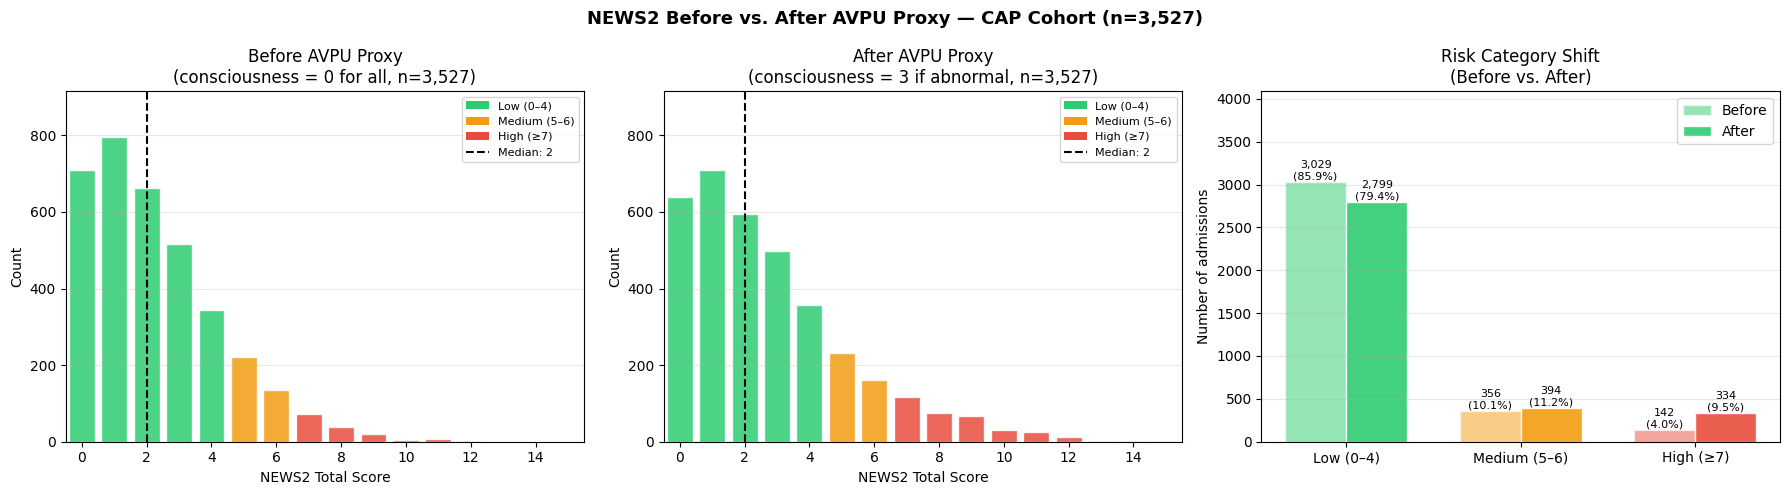


cohort_df shape: (3527, 45)


,hadm_id,ed_triage_acuity,ed_triage_chiefcomplaint,avpu_abnormal,news2_consciousness,news2_total_noavpu,news2_total,news2_risk
0,26184834,2.000000000,"Dyspnea, Productive cough, Hemoptysis",0,0,2.0,2,Low (0–4)
1,22602599,3.000000000,Weakness,0,0,1.0,1,Low (0–4)
2,27568122,2.000000000,"Dyspnea, Transfer",0,0,1.0,1,Low (0–4)
3,23905070,3.000000000,"Dyspnea, Productive cough",0,0,1.0,1,Low (0–4)
4,29777036,2.000000000,"Pneumonia, Transfer",0,0,1.0,1,Low (0–4)
5,24623461,2.000000000,Abnormal labs,0,0,4.0,4,Low (0–4)
6,26726393,2.000000000,Weakness,0,0,5.0,5,Medium (5–6)
7,21582131,2.000000000,"Confusion, Weakness",1,3,0.0,3,Low (0–4)
8,29276678,1.000000000,"Dyspnea, Hypoxia",1,3,8.0,11,High (≥7)
9,25186901,3.000000000,"Fever, Dizziness",0,0,1.0,1,Low (0–4)


In [10]:
# ── Summary ──
n_cc_mental = cohort_df['cc_mental_status'].sum()
n_acuity_1  = (acuity == 1).sum()
n_both      = ((acuity == 1) & (cohort_df['cc_mental_status'] == 1)).sum()
n_avpu_abn  = cohort_df['avpu_abnormal'].sum()
n_upgraded  = (cohort_df.loc[mask, 'news2_consciousness'] == 3).sum()

print("=" * 65)
print("  AVPU PROXY SUMMARY")
print("=" * 65)
print(f"  Chief complaint mental-status match : {n_cc_mental:,} ({n_cc_mental/len(cohort_df)*100:.1f}%)")
print(f"  ESI acuity = 1 (resuscitation)      : {n_acuity_1:,} ({n_acuity_1/len(cohort_df)*100:.1f}%)")
print(f"  Both criteria met                   : {n_both:,}")
print(f"  AVPU abnormal (either criterion)    : {n_avpu_abn:,} ({n_avpu_abn/len(cohort_df)*100:.1f}%)")
print(f"  Scored patients upgraded +3         : {n_upgraded:,}")

# ── Align before/after on the SAME rows ──
# Use only rows where BOTH noavpu and avpu total are non-null
# (prevents n mismatch if acuity is missing for some rows)
compare_df = cohort_df.loc[mask, ['news2_total_noavpu', 'news2_total']].dropna()
before = compare_df['news2_total_noavpu']
after  = compare_df['news2_total']

print(f"\n{'─'*65}")
print(f"  NEWS2 BEFORE vs. AFTER AVPU PROXY  (n = {len(before):,} both)")
print(f"{'─'*65}")
print(f"  {'':30s}  Before    After")
print(f"  {'Mean ± SD':30s}: {before.mean():.1f} ± {before.std():.1f}  →  {after.mean():.1f} ± {after.std():.1f}")
print(f"  {'Median (IQR)':30s}: {before.median():.0f} ({before.quantile(.25):.0f}–{before.quantile(.75):.0f})  →  {after.median():.0f} ({after.quantile(.25):.0f}–{after.quantile(.75):.0f})")

for label, s in [('Before (AVPU=0)', before), ('After (AVPU proxy)', after)]:
    rc = s.apply(news2_risk).value_counts().reindex(['Low (0–4)', 'Medium (5–6)', 'High (≥7)'])
    print(f"\n  Risk distribution — {label}:")
    for cat, cnt in rc.items():
        print(f"    {cat:20s}: {cnt:5,} ({cnt/len(s)*100:.1f}%)")

# ── Visualisation ──
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"NEWS2 Before vs. After AVPU Proxy — CAP Cohort (n={len(before):,})",
             fontsize=13, fontweight='bold')

all_scores = sorted(set(before.unique()) | set(after.unique()))
colors_map = {s: ('#2ecc71' if s <= 4 else '#f39c12' if s <= 6 else '#e74c3c') for s in all_scores}

bc = before.value_counts().sort_index()
ac = after.value_counts().sort_index()

# Shared limits for both distribution panels
shared_xlim = (-0.5, max(all_scores) + 0.5)
shared_ylim = (0, max(bc.max(), ac.max()) * 1.15)

legend_els = [Patch(facecolor='#2ecc71', label='Low (0–4)'),
              Patch(facecolor='#f39c12', label='Medium (5–6)'),
              Patch(facecolor='#e74c3c', label='High (≥7)')]

# Panel 1: before
ax = axes[0]
ax.bar(bc.index, bc.values, color=[colors_map[s] for s in bc.index], alpha=0.85, edgecolor='white')
ax.axvline(before.median(), color='black', linestyle='--', linewidth=1.5)
ax.legend(handles=legend_els + [plt.Line2D([0],[0], color='black', linestyle='--',
          label=f'Median: {before.median():.0f}')], fontsize=8)
ax.set_xlabel('NEWS2 Total Score')
ax.set_ylabel('Count')
ax.set_title(f'Before AVPU Proxy\n(consciousness = 0 for all, n={len(before):,})')
ax.set_xlim(shared_xlim)
ax.set_ylim(shared_ylim)
ax.grid(axis='y', alpha=0.3)

# Panel 2: after
ax = axes[1]
ax.bar(ac.index, ac.values, color=[colors_map.get(s, '#e74c3c') for s in ac.index], alpha=0.85, edgecolor='white')
ax.axvline(after.median(), color='black', linestyle='--', linewidth=1.5)
ax.legend(handles=legend_els + [plt.Line2D([0],[0], color='black', linestyle='--',
          label=f'Median: {after.median():.0f}')], fontsize=8)
ax.set_xlabel('NEWS2 Total Score')
ax.set_ylabel('Count')
ax.set_title(f'After AVPU Proxy\n(consciousness = 3 if abnormal, n={len(after):,})')
ax.set_xlim(shared_xlim)
ax.set_ylim(shared_ylim)
ax.grid(axis='y', alpha=0.3)

# Panel 3: risk category shift
ax = axes[2]
risk_cats   = ['Low (0–4)', 'Medium (5–6)', 'High (≥7)']
before_risk = before.apply(news2_risk).value_counts().reindex(risk_cats).fillna(0)
after_risk  = after.apply(news2_risk).value_counts().reindex(risk_cats).fillna(0)
n_scored    = len(before)

x = np.arange(len(risk_cats))
w = 0.35
b1 = ax.bar(x - w/2, before_risk.values, w, label='Before', color=['#2ecc71','#f39c12','#e74c3c'], alpha=0.5, edgecolor='white')
b2 = ax.bar(x + w/2, after_risk.values,  w, label='After',  color=['#2ecc71','#f39c12','#e74c3c'], alpha=0.9, edgecolor='white')
for bars_g, vals_g in [(b1, before_risk.values), (b2, after_risk.values)]:
    for bar, v in zip(bars_g, vals_g):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, v + 5,
                    f'{int(v):,}\n({v/n_scored*100:.1f}%)', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(risk_cats, fontsize=10)
ax.set_ylabel('Number of admissions')
ax.set_title('Risk Category Shift\n(Before vs. After)')
ax.legend(fontsize=10)
ax.set_ylim(0, max(before_risk.max(), after_risk.max()) * 1.35)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\ncohort_df shape: {cohort_df.shape}")
cohort_df[['hadm_id', 'ed_triage_acuity', 'ed_triage_chiefcomplaint',
           'avpu_abnormal', 'news2_consciousness',
           'news2_total_noavpu', 'news2_total', 'news2_risk']].head(10)


In [11]:
cohort_df

,subject_id,gender,anchor_age,anchor_year,age_at_admission,hadm_id,admittime,dischtime,deathtime,hospital_expire_flag,...,news2_sbp,news2_hr,news2_temp,news2_o2_supplement,news2_consciousness,news2_total,news2_risk,cc_mental_status,avpu_abnormal,news2_total_noavpu
0,10001884,F,68,2122,77,26184834,2131-01-07 20:39:00,2131-01-20 05:15:00,2131-01-20 05:15:00,1,...,0,0,0,0,0,2,Low (0–4),0,0,2.0
1,10004322,M,60,2131,63,22602599,2134-09-27 15:25:00,2134-10-02 19:24:00,NaT,0,...,0,1,0,0,0,1,Low (0–4),0,0,1.0
2,10016742,F,58,2178,58,27568122,2178-07-22 07:19:00,2178-07-25 16:30:00,NaT,0,...,0,0,1,0,0,1,Low (0–4),0,0,1.0
3,10020852,F,24,2165,36,23905070,2177-05-18 02:59:00,2177-05-25 18:15:00,NaT,0,...,0,1,0,0,0,1,Low (0–4),0,0,1.0
4,10021704,M,59,2128,63,29777036,2132-03-19 21:51:00,2132-04-02 21:58:00,NaT,0,...,1,0,0,0,0,1,Low (0–4),0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3522,19969031,M,68,2171,79,26728965,2182-02-18 16:59:00,2182-02-24 13:53:00,NaT,0,...,0,0,0,0,3,3,Low (0–4),1,1,0.0
3523,19973580,F,69,2161,69,28570089,2161-10-25 16:33:00,2161-10-28 15:20:00,NaT,0,...,0,1,0,0,0,2,Low (0–4),0,0,2.0
3524,19974520,F,78,2152,78,23580334,2152-01-17 17:30:00,2152-01-20 19:24:00,NaT,0,...,0,1,0,0,0,1,Low (0–4),0,0,1.0
3525,19984781,F,81,2165,81,28904296,2165-09-14 22:13:00,2165-09-27 14:20:00,NaT,0,...,0,1,0,0,0,1,Low (0–4),0,0,1.0


In [12]:
# # ══════════════════════════════════════════════════════════════════
# # RADIOLOGY NOTE LINKAGE — USING cohort_df ONLY (no table upload)
# # ══════════════════════════════════════════════════════════════════

# from google.cloud import bigquery
# import time

# NOTE_DS = "physionet-data.mimiciv_note"

# # ─────────────────────────────────────────────────────────────────
# # 1️⃣ Extract hadm_ids directly from cohort_df
# # ─────────────────────────────────────────────────────────────────
# hadm_ids = cohort_df['hadm_id'].astype(int).unique().tolist()

# job_config = bigquery.QueryJobConfig(
#     query_parameters=[
#         bigquery.ArrayQueryParameter("hadm_ids", "INT64", hadm_ids)
#     ]
# )

# # ─────────────────────────────────────────────────────────────────
# # 2️⃣ Query radiology notes
# # ─────────────────────────────────────────────────────────────────
# rad_link_query = f"""
# WITH cohort AS (
#     SELECT
#         subject_id,
#         hadm_id,
#         admittime,
#         dischtime
#     FROM `{HOSP}.admissions`
#     WHERE hadm_id IN UNNEST(@hadm_ids)
# ),

# rad_notes AS (
#     SELECT
#         hadm_id,
#         note_id,
#         note_type,
#         charttime
#     FROM `{NOTE_DS}.radiology`
#     WHERE hadm_id IN UNNEST(@hadm_ids)
# )

# SELECT
#     c.hadm_id,
#     c.subject_id,

#     COUNT(DISTINCT r.note_id) AS n_rad_notes,

#     COUNT(DISTINCT CASE
#         WHEN r.charttime BETWEEN c.admittime AND c.dischtime
#         THEN r.note_id END
#     ) AS n_rad_notes_during_admission,

#     STRING_AGG(DISTINCT r.note_type ORDER BY r.note_type) AS note_types,
#     MIN(r.charttime) AS first_rad_note,
#     MAX(r.charttime) AS last_rad_note

# FROM cohort c
# LEFT JOIN rad_notes r USING (hadm_id)

# GROUP BY c.hadm_id, c.subject_id, c.admittime, c.dischtime
# ORDER BY c.hadm_id
# """

# # ─────────────────────────────────────────────────────────────────
# # 3️⃣ Execute
# # ─────────────────────────────────────────────────────────────────
# t0 = time.time()
# rad_link_df = client.client.query(rad_link_query, job_config=job_config).to_dataframe()
# print(f"Query done in {time.time()-t0:.1f}s — {len(rad_link_df):,} rows returned")

# # ─────────────────────────────────────────────────────────────────
# # 4️⃣ Summary
# # ─────────────────────────────────────────────────────────────────
# n_total  = len(rad_link_df)
# n_any    = (rad_link_df['n_rad_notes'] > 0).sum()
# n_during = (rad_link_df['n_rad_notes_during_admission'] > 0).sum()
# n_none   = (rad_link_df['n_rad_notes'] == 0).sum()

# print(f"\n{'='*65}")
# print(f"  RADIOLOGY NOTE LINKAGE  (cohort n = {n_total:,})")
# print(f"{'='*65}")
# print(f"  Any radiology note (by hadm_id)       : {n_any:,}  ({n_any/n_total*100:.1f}%)")
# print(f"  Radiology note within admission window: {n_during:,}  ({n_during/n_total*100:.1f}%)")
# print(f"  No radiology note at all              : {n_none:,}  ({n_none/n_total*100:.1f}%)")


# Time-Varying Survival Dataset for Cox Model

Prepare a time-varying dataset where each row represents a **time interval** for a patient admission.  
Interval boundaries are created by: **admission → each radiology report → discharge**.

- `radiology_logit` is a placeholder (set to `0`) — will be replaced by text model predictions later  
- `has_radiology` flips from `0 → 1` after the first radiology report  
- `event` is set to `0` for all rows (deterioration labels added later)

In [13]:
# ══════════════════════════════════════════════════════════════════
# STEP 1 — Pull radiology reports from BigQuery
# ══════════════════════════════════════════════════════════════════

from google.cloud import bigquery
import time

NOTE_DS = "physionet-data.mimiciv_note"

# Use hadm_ids already in memory from cohort_df
hadm_ids_list = cohort_df['hadm_id'].astype(int).unique().tolist()

job_config_rad = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("hadm_ids", "INT64", hadm_ids_list)
    ]
)

rad_query = f"""
SELECT
    subject_id,
    hadm_id,
    charttime,
    text
FROM `{NOTE_DS}.radiology`
WHERE hadm_id IN UNNEST(@hadm_ids)
ORDER BY hadm_id, charttime
"""

print("⏳ Pulling radiology reports...", end="", flush=True)
t0 = time.time()
rad_df = client.client.query(rad_query, job_config=job_config_rad).to_dataframe()
print(f" ✅ {len(rad_df):,} reports in {time.time()-t0:.1f}s")

n_hadm_with_rad = rad_df['hadm_id'].nunique()
n_cohort = cohort_df['hadm_id'].nunique()
print(f"\nAdmissions with ≥1 radiology report: {n_hadm_with_rad:,} / {n_cohort:,} "
      f"({n_hadm_with_rad/n_cohort*100:.1f}%)")
print(f"Total radiology reports: {len(rad_df):,}")
print(f"Reports per admission:  median {rad_df.groupby('hadm_id').size().median():.0f}, "
      f"mean {rad_df.groupby('hadm_id').size().mean():.1f}")
rad_df.head()

⏳ Pulling radiology reports...

⏳ Pulling radiology reports...

/Users/pc/Documents/VU/GCF/Project/notes2numbers/notes2numbers/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


⏳ Pulling radiology reports...

/Users/pc/Documents/VU/GCF/Project/notes2numbers/notes2numbers/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


 ✅ 13,404 reports in 26.6s

Admissions with ≥1 radiology report: 3,242 / 3,527 (91.9%)
Total radiology reports: 13,404
Reports per admission:  median 2, mean 4.1


,subject_id,hadm_id,charttime,text
0,17055745,20005666,2159-03-14 21:45:00,EXAMINATION: CHEST (PA AND LAT)\n\nINDICATION...
1,12945136,20007246,2193-01-13 11:56:00,EXAMINATION: CHEST (PORTABLE AP)\n\nINDICATIO...
2,12945136,20007246,2193-01-13 12:54:00,EXAMINATION: CT HEAD W/O CONTRAST Q111 CT HEA...
3,12945136,20007246,2193-01-14 10:19:00,EXAMINATION: UNILAT LOWER EXT VEINS LEFT\n\nI...
4,12945136,20007246,2193-01-15 18:17:00,EXAMINATION: Portable chest x-ray\n\nINDICATI...


In [14]:
# ══════════════════════════════════════════════════════════════════
# STEP 2 — Prepare radiology dataframe
# ══════════════════════════════════════════════════════════════════

# Sort by hadm_id and charttime
rad_df = rad_df.sort_values(['hadm_id', 'charttime']).reset_index(drop=True)

# Placeholder logit — will be replaced by text model predictions later
rad_df['radiology_logit'] = 0.0

print(f"rad_df shape: {rad_df.shape}")
print(f"Columns: {list(rad_df.columns)}")
print(f"\nFirst 5 rows (text truncated):")
display_df = rad_df.head().copy()
display_df['text'] = display_df['text'].str[:80] + '...'
display_df

rad_df shape: (13404, 5)
Columns: ['subject_id', 'hadm_id', 'charttime', 'text', 'radiology_logit']

First 5 rows (text truncated):


rad_df shape: (13404, 5)
Columns: ['subject_id', 'hadm_id', 'charttime', 'text', 'radiology_logit']

First 5 rows (text truncated):


,subject_id,hadm_id,charttime,text,radiology_logit
0,17055745,20005666,2159-03-14 21:45:00,EXAMINATION: CHEST (PA AND LAT)\n\nINDICATION...,0.0
1,12945136,20007246,2193-01-13 11:56:00,EXAMINATION: CHEST (PORTABLE AP)\n\nINDICATIO...,0.0
2,12945136,20007246,2193-01-13 12:54:00,EXAMINATION: CT HEAD W/O CONTRAST Q111 CT HEA...,0.0
3,12945136,20007246,2193-01-14 10:19:00,EXAMINATION: UNILAT LOWER EXT VEINS LEFT\n\nI...,0.0
4,12945136,20007246,2193-01-15 18:17:00,EXAMINATION: Portable chest x-ray\n\nINDICATI...,0.0


In [15]:
# ══════════════════════════════════════════════════════════════════
# VITAL SIGNS AT RADIOLOGY REPORT CHARTTIMES
# Query ED.vitalsign table to see what vital measurements are
# available at exact times when radiology reports were recorded
# ══════════════════════════════════════════════════════════════════

import time
from google.cloud import bigquery
import pandas as pd
import numpy as np

# Use the hadm_ids directly with ED.vitalsign (which links via stay_id in MIMIC)
job_config_vitals = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("hadm_ids", "INT64", hadm_ids_list)
    ]
)

vitals_alignment_query = f"""
-- Query: Check if ED vitalsign measurements exist at exact radiology report times
-- Note: ED.vitalsign links via stay_id; we'll join edstays to get hadm_id

WITH rad_charttimes AS (
    -- Extract all radiology report charttimes with associated stay_id (from ED stay)
    SELECT
        es.stay_id,
        es.hadm_id,
        r.charttime AS rad_charttime,
        ROW_NUMBER() OVER (PARTITION BY es.stay_id ORDER BY r.charttime) AS rad_seq
    FROM `{NOTE_DS}.radiology` r
    INNER JOIN `{ED}.edstays` es ON r.hadm_id = es.hadm_id
    WHERE r.hadm_id IN UNNEST(@hadm_ids)
),

vitals_within_admission AS (
    -- Get all vitalsign measurements within ±12 hours of each radiology report
    SELECT
        rc.stay_id,
        rc.hadm_id,
        rc.rad_charttime,
        rc.rad_seq,
        v.charttime AS vital_charttime,
        v.temperature,
        v.heartrate,
        v.resprate,
        v.o2sat,
        v.sbp,
        v.dbp,
        -- Time difference in minutes
        ABS(TIMESTAMP_DIFF(v.charttime, rc.rad_charttime, MINUTE)) AS time_diff_min,
        -- Is this an EXACT match? (within 1 minute)
        CASE WHEN ABS(TIMESTAMP_DIFF(v.charttime, rc.rad_charttime, MINUTE)) <= 1
             THEN 1 ELSE 0 END AS is_exact_match
    FROM rad_charttimes rc
    LEFT JOIN `{ED}.vitalsign` v 
        ON rc.stay_id = v.stay_id 
        AND v.charttime BETWEEN TIMESTAMP_ADD(rc.rad_charttime, INTERVAL -12 HOUR)
                           AND TIMESTAMP_ADD(rc.rad_charttime, INTERVAL 12 HOUR)
)

SELECT
    stay_id,
    hadm_id,
    COUNT(DISTINCT rad_charttime) AS n_rad_reports,
    
    -- Exact matches (within 1 minute)
    COUNT(DISTINCT CASE WHEN is_exact_match = 1 THEN rad_charttime END) AS n_rad_with_exact_vitals,
    ROUND(100 * COUNT(DISTINCT CASE WHEN is_exact_match = 1 THEN rad_charttime END) 
          / NULLIF(COUNT(DISTINCT rad_charttime), 0), 1) AS pct_rad_with_exact_vitals,
    
    -- Close matches (within 5 minutes)
    COUNT(DISTINCT CASE WHEN time_diff_min <= 5 THEN rad_charttime END) AS n_rad_with_vitals_5min,
    ROUND(100 * COUNT(DISTINCT CASE WHEN time_diff_min <= 5 THEN rad_charttime END)
          / NULLIF(COUNT(DISTINCT rad_charttime), 0), 1) AS pct_rad_with_vitals_5min,
    
    -- Vitals within 1 hour
    COUNT(DISTINCT CASE WHEN time_diff_min <= 60 THEN rad_charttime END) AS n_rad_with_vitals_1h,
    ROUND(100 * COUNT(DISTINCT CASE WHEN time_diff_min <= 60 THEN rad_charttime END)
          / NULLIF(COUNT(DISTINCT rad_charttime), 0), 1) AS pct_rad_with_vitals_1h,
    
    -- No vitals at all within 12 hours
    COUNT(DISTINCT CASE WHEN vital_charttime IS NULL THEN rad_charttime END) AS n_rad_no_vitals,
    ROUND(100 * COUNT(DISTINCT CASE WHEN vital_charttime IS NULL THEN rad_charttime END)
          / NULLIF(COUNT(DISTINCT rad_charttime), 0), 1) AS pct_rad_no_vitals

FROM vitals_within_admission
GROUP BY stay_id, hadm_id
ORDER BY n_rad_reports DESC
"""

print("⏳ Querying ED vitalsign alignment with radiology charttimes...", end="", flush=True)
t0 = time.time()
vitals_align_df = client.client.query(vitals_alignment_query, job_config=job_config_vitals).to_dataframe()
elapsed = time.time() - t0
print(f" ✅ {elapsed:.1f}s\n")

# Print summary statistics
print("=" * 80)
print("  VITAL SIGNS AVAILABILITY AT RADIOLOGY REPORT CHARTTIMES")
print("=" * 80)

if len(vitals_align_df) > 0:
    total_admissions = len(vitals_align_df)
    total_rad_reports = vitals_align_df['n_rad_reports'].sum()
    
    print(f"\n  Admissions with radiology reports: {total_admissions:,}")
    print(f"  Total radiology reports:           {total_rad_reports:,}")
    print(f"  Mean reports per admission:        {vitals_align_df['n_rad_reports'].mean():.1f}")
    print(f"  Median reports per admission:      {vitals_align_df['n_rad_reports'].median():.0f}")
    
    print(f"\n  EXACT VITAL SIGN MATCHES (within 1 minute of radiology charttime):")
    exact_matches = vitals_align_df['n_rad_with_exact_vitals'].sum()
    print(f"    Radiology reports with exact vitals: {exact_matches:,} / {total_rad_reports:,} "
          f"({exact_matches/total_rad_reports*100:.1f}%)")
    print(f"    Admission coverage: {(vitals_align_df['n_rad_with_exact_vitals'] > 0).sum():,} / {total_admissions:,} "
          f"({(vitals_align_df['n_rad_with_exact_vitals'] > 0).sum()/total_admissions*100:.1f}%)")
    
    print(f"\n  CLOSE MATCHES (within 5 minutes):")
    close_5m = vitals_align_df['n_rad_with_vitals_5min'].sum()
    print(f"    Radiology reports with vitals: {close_5m:,} / {total_rad_reports:,} "
          f"({close_5m/total_rad_reports*100:.1f}%)")
    
    print(f"\n  NEARBY MATCHES (within 1 hour):")
    within_1h = vitals_align_df['n_rad_with_vitals_1h'].sum()
    print(f"    Radiology reports with vitals: {within_1h:,} / {total_rad_reports:,} "
          f"({within_1h/total_rad_reports*100:.1f}%)")
    
    print(f"\n  NO VITALS (within 12 hours of report):")
    no_vitals = vitals_align_df['n_rad_no_vitals'].sum()
    print(f"    Radiology reports with NO vitals: {no_vitals:,} / {total_rad_reports:,} "
          f"({no_vitals/total_rad_reports*100:.1f}%)")
    
    print(f"\n  {'─'*80}")
    print(f"  INTERPRETATION:")
    print(f"  {'─'*80}")
    if exact_matches / total_rad_reports > 0.8:
        print(f"  ✅ Strong temporal alignment: {exact_matches/total_rad_reports*100:.1f}% of radiology reports")
        print(f"     have vital sign measurements at exact/near charttimes")
        print(f"     → Can use time-matched vitals for more accurate feature values")
    elif within_1h / total_rad_reports > 0.7:
        print(f"  ⚠️  Moderate alignment: {within_1h/total_rad_reports*100:.1f}% of radiology reports")
        print(f"      have vitals within 1 hour")
        print(f"      → May need to interpolate or use ED triage vitals as fallback")
    else:
        print(f"  ❌ Poor alignment: Only {within_1h/total_rad_reports*100:.1f}% have vitals within 1 hour")
        print(f"      → Current approach (ED triage vitals only) is appropriate")
        print(f"      → Vitals are constant per admission, not time-varying")
    print(f"  {'─'*80}\n")
    
    # Show detailed breakdown by admission
    print(f"  Sample of admissions (sorted by n_rad_reports):")
    display_cols = ['stay_id', 'hadm_id', 'n_rad_reports', 'n_rad_with_exact_vitals', 
                    'pct_rad_with_exact_vitals', 'n_rad_with_vitals_1h', 'pct_rad_with_vitals_1h',
                    'n_rad_no_vitals', 'pct_rad_no_vitals']
    print(vitals_align_df[display_cols].head(10).to_string(index=False))
else:
    print("  ⚠️  No results returned — check hadm_id/stay_id mapping")

⏳ Querying ED vitalsign alignment with radiology charttimes...

⏳ Querying ED vitalsign alignment with radiology charttimes...

/Users/pc/Documents/VU/GCF/Project/notes2numbers/notes2numbers/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


⏳ Querying ED vitalsign alignment with radiology charttimes...

/Users/pc/Documents/VU/GCF/Project/notes2numbers/notes2numbers/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


 ✅ 2.1s

  VITAL SIGNS AVAILABILITY AT RADIOLOGY REPORT CHARTTIMES

  Admissions with radiology reports: 3,246
  Total radiology reports:           13,008
  Mean reports per admission:        4.0
  Median reports per admission:      2

  EXACT VITAL SIGN MATCHES (within 1 minute of radiology charttime):
    Radiology reports with exact vitals: 134 / 13,008 (1.0%)
    Admission coverage: 126 / 3,246 (3.9%)

  CLOSE MATCHES (within 5 minutes):
    Radiology reports with vitals: 472 / 13,008 (3.6%)

  NEARBY MATCHES (within 1 hour):
    Radiology reports with vitals: 3,179 / 13,008 (24.4%)

  NO VITALS (within 12 hours of report):
    Radiology reports with NO vitals: 8,146 / 13,008 (62.6%)

  ────────────────────────────────────────────────────────────────────────────────
  INTERPRETATION:
  ────────────────────────────────────────────────────────────────────────────────
  ❌ Poor alignment: Only 24.4% have vitals within 1 hour
      → Current approach (ED triage vitals only) is appropria

In [16]:
# ══════════════════════════════════════════════════════════════════
# STEP 3 — Create time-varying survival dataset
#
# Each row = one time interval for a patient admission.
# Interval boundaries: admission → each radiology report → discharge
# Time unit: hours since admittime
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

rows = []

# Build a lookup: hadm_id → list of (hours_since_admit, radiology_logit)
rad_lookup = {}
for hadm_id, grp in rad_df.groupby('hadm_id'):
    rad_lookup[hadm_id] = list(zip(
        grp['charttime'],
        grp['radiology_logit']
    ))

# Iterate over each admission in the cohort
for _, adm in cohort_df.iterrows():
    hadm_id   = adm['hadm_id']
    admittime = pd.Timestamp(adm['admittime'])
    dischtime = pd.Timestamp(adm['dischtime'])
    age       = adm['age_at_admission']
    gender    = adm['gender']

    # ── Collect radiology event times (hours since admission) ──
    rad_events = []
    if hadm_id in rad_lookup:
        for charttime, logit in rad_lookup[hadm_id]:
            h = (pd.Timestamp(charttime) - admittime).total_seconds() / 3600.0
            rad_events.append((h, logit))

    # Discharge time in hours
    disch_h = (dischtime - admittime).total_seconds() / 3600.0

    # ── Build interval boundaries ──
    # Always start at 0 (admission)
    boundaries = [0.0]
    logits_at_boundary = [0.0]   # logit at each boundary (LOCF)

    for h, logit in rad_events:
        if 0 < h < disch_h:     # only include reports within admission window
            boundaries.append(h)
            logits_at_boundary.append(logit)

    boundaries.append(disch_h)
    # The logit at discharge boundary doesn't create a new interval,
    # but we need it for the length calculation

    # ── Create interval rows ──
    current_logit    = 0.0
    has_rad          = 0
    first_rad_seen   = False

    for i in range(len(boundaries) - 1):
        start = boundaries[i]
        stop  = boundaries[i + 1]

        # Skip degenerate intervals
        if stop <= start:
            continue

        # After each radiology boundary, update logit (LOCF) and flip has_rad
        if i > 0 and i < len(logits_at_boundary):
            current_logit = logits_at_boundary[i]
            if not first_rad_seen and hadm_id in rad_lookup:
                # Check if this boundary was a radiology event (not admission)
                first_rad_seen = True
                has_rad = 1

        rows.append({
            'hadm_id':          hadm_id,
            'start':            round(start, 4),
            'stop':             round(stop, 4),
            'age_at_admission': age,
            'gender':           gender,
            'radiology_logit':  current_logit,
            'has_radiology':    has_rad,
            'event':            0,
        })

# ── Assemble final dataframe ──
survival_df = pd.DataFrame(rows)
survival_df = survival_df.sort_values(['hadm_id', 'start']).reset_index(drop=True)

# ── Summary ──
n_adm = survival_df['hadm_id'].nunique()
n_rows = len(survival_df)
print(f"{'='*65}")
print(f"  TIME-VARYING SURVIVAL DATASET")
print(f"{'='*65}")
print(f"  Admissions represented : {n_adm:,}")
print(f"  Total interval rows    : {n_rows:,}")
print(f"  Rows per admission     : median {survival_df.groupby('hadm_id').size().median():.0f}, "
      f"mean {survival_df.groupby('hadm_id').size().mean():.1f}")
print(f"  Rows with has_radiology=1: {(survival_df['has_radiology']==1).sum():,} "
      f"({(survival_df['has_radiology']==1).mean()*100:.1f}%)")

# Admissions with NO radiology at all → single row [0, disch_h]
n_single = (survival_df.groupby('hadm_id').size() == 1).sum()
print(f"  Single-interval admissions (no rad): {n_single:,}")

print(f"\nColumns: {list(survival_df.columns)}")
print(f"Shape  : {survival_df.shape}")
survival_df.head(15)

  TIME-VARYING SURVIVAL DATASET
  Admissions represented : 3,527
  Total interval rows    : 12,827
  Rows per admission     : median 2, mean 3.6
  Rows with has_radiology=1: 9,300 (72.5%)
  Single-interval admissions (no rad): 1,365

Columns: ['hadm_id', 'start', 'stop', 'age_at_admission', 'gender', 'radiology_logit', 'has_radiology', 'event']
Shape  : (12827, 8)


,hadm_id,start,stop,age_at_admission,gender,radiology_logit,has_radiology,event
0,20005666,0.0000,66.7000,90,F,0.0,0,0
1,20007246,0.0000,18.0167,86,M,0.0,0,0
2,20007246,18.0167,49.9833,86,M,0.0,1,0
3,20007246,49.9833,64.1500,86,M,0.0,1,0
4,20007246,64.1500,123.3333,86,M,0.0,1,0
5,20007517,0.0000,92.8333,76,M,0.0,0,0
6,20009330,0.0000,0.9667,73,M,0.0,0,0
7,20009330,0.9667,1.4000,73,M,0.0,1,0
8,20009330,1.4000,8.6667,73,M,0.0,1,0
9,20009330,8.6667,33.4500,73,M,0.0,1,0


In [17]:
# ══════════════════════════════════════════════════════════════════
# STEP 4 — Populate the EVENT column
#
# Deterioration = any of: IMV, vasopressors, death within 72 h.
# Timing columns in cohort_df are relative to ED arrival (ed_intime),
# but survival_df uses admittime as time origin.
#
# Strategy:
#   1. Convert the earliest deterioration time from ED-anchor → admit-anchor
#   2. For each admission with deterioration_72h == 1:
#      a. Find which interval contains the event time
#      b. Truncate that interval: stop = event_time
#      c. Set event = 1 on that interval
#      d. Drop any intervals starting at or after the event time
#   3. Admissions without deterioration keep event = 0 throughout
# ══════════════════════════════════════════════════════════════════

# ── 1. Compute event time in hours from admittime ──
# ed_offset = hours between admittime and ed_intime (typically negative,
# since ED arrival usually precedes hospital admission by 2-6 h)
cohort_events = cohort_df[['hadm_id', 'admittime', 'ed_intime',
                            'deterioration_72h',
                            'hours_to_imv_from_ed',
                            'hours_to_vasopressor_from_ed',
                            'hours_to_death_from_ed']].copy()

cohort_events['admittime'] = pd.to_datetime(cohort_events['admittime'])
cohort_events['ed_intime'] = pd.to_datetime(cohort_events['ed_intime'])

# Offset: how many hours ED arrival is BEFORE admittime
# ed_offset > 0 means ED arrived BEFORE admission (typical)
cohort_events['ed_offset_h'] = (
    (cohort_events['admittime'] - cohort_events['ed_intime'])
    .dt.total_seconds() / 3600.0
)

# Convert each deterioration time from ED-anchor to admit-anchor
# hours_from_admit = hours_from_ed - ed_offset_h
for col_ed, col_new in [
    ('hours_to_imv_from_ed',          'hours_to_imv_from_admit'),
    ('hours_to_vasopressor_from_ed',  'hours_to_vaso_from_admit'),
    ('hours_to_death_from_ed',        'hours_to_death_from_admit'),
]:
    cohort_events[col_new] = cohort_events[col_ed] - cohort_events['ed_offset_h']

# Earliest deterioration event time (from admittime)
event_time_cols = ['hours_to_imv_from_admit', 'hours_to_vaso_from_admit', 'hours_to_death_from_admit']
cohort_events['event_time_h'] = cohort_events[event_time_cols].min(axis=1)

# Only keep admissions with deterioration
event_lookup = (
    cohort_events
    .loc[cohort_events['deterioration_72h'] == 1, ['hadm_id', 'event_time_h']]
    .set_index('hadm_id')['event_time_h']
    .to_dict()
)

print(f"Admissions with deterioration: {len(event_lookup):,}")
print(f"Event time (hours from admit) — "
      f"median: {np.median(list(event_lookup.values())):.1f}, "
      f"mean: {np.mean(list(event_lookup.values())):.1f}")

# Quick check: ED offset distribution
offsets = cohort_events['ed_offset_h'].dropna()
print(f"\nED→Admit offset (hours): median {offsets.median():.1f}, "
      f"mean {offsets.mean():.1f}, range [{offsets.min():.1f}, {offsets.max():.1f}]")

# ── 2. Apply event times to survival_df ──
new_rows = []
for _, row in survival_df.iterrows():
    hadm_id = row['hadm_id']
    start   = row['start']
    stop    = row['stop']

    if hadm_id not in event_lookup:
        # No deterioration → keep row as-is, event = 0
        new_rows.append(row.to_dict())
        continue

    evt_h = event_lookup[hadm_id]

    # Skip intervals that start at or after the event
    if start >= evt_h:
        continue

    r = row.to_dict()

    if evt_h <= stop:
        # Event falls within this interval → truncate & mark event
        r['stop']  = round(evt_h, 4)
        r['event'] = 1
    # else: event is after this interval → keep as-is (event=0)

    # Only keep if interval is valid
    if r['stop'] > r['start']:
        new_rows.append(r)

survival_df = pd.DataFrame(new_rows).reset_index(drop=True)
survival_df = survival_df.sort_values(['hadm_id', 'start']).reset_index(drop=True)

# ── 3. Summary ──
n_adm        = survival_df['hadm_id'].nunique()
n_events     = survival_df['event'].sum()
n_adm_event  = survival_df.loc[survival_df['event'] == 1, 'hadm_id'].nunique()
n_rows       = len(survival_df)

print(f"\n{'='*65}")
print(f"  UPDATED SURVIVAL DATASET (with events)")
print(f"{'='*65}")
print(f"  Admissions              : {n_adm:,}")
print(f"  Total interval rows     : {n_rows:,}")
print(f"  Rows per admission      : median {survival_df.groupby('hadm_id').size().median():.0f}, "
      f"mean {survival_df.groupby('hadm_id').size().mean():.1f}")
print(f"  Event = 1 rows          : {n_events:,.0f}")
print(f"  Admissions with event=1 : {n_adm_event:,} ({n_adm_event/n_adm*100:.1f}%)")
print(f"  Admissions censored     : {n_adm - n_adm_event:,} ({(n_adm - n_adm_event)/n_adm*100:.1f}%)")

# Sanity: every admission with deterioration should have exactly 1 event row
det_hadms_in_surv = set(survival_df.loc[survival_df['event']==1, 'hadm_id'])
det_hadms_expected = set(event_lookup.keys()) & set(survival_df['hadm_id'].unique())
missing = det_hadms_expected - det_hadms_in_surv
if missing:
    print(f"\n  ⚠️  {len(missing)} deterioration admissions missing event=1 "
          f"(event time may be ≤ 0 from admittime)")
else:
    print(f"\n  ✅ All {len(det_hadms_expected)} deterioration admissions have event=1")

print(f"\nShape: {survival_df.shape}")

# Show some event=1 rows
print("\nSample rows with event=1:")
survival_df[survival_df['event'] == 1].head(10)

Admissions with deterioration: 269
Event time (hours from admit) — median: 4.3, mean: 12.6

ED→Admit offset (hours): median 5.5, mean 6.6, range [-17.2, 51.4]

  UPDATED SURVIVAL DATASET (with events)
  Admissions              : 3,527
  Total interval rows     : 10,640
  Rows per admission      : median 2, mean 3.0
  Event = 1 rows          : 255
  Admissions with event=1 : 255 (7.2%)
  Admissions censored     : 3,272 (92.8%)

  ⚠️  14 deterioration admissions missing event=1 (event time may be ≤ 0 from admittime)

Shape: (10640, 8)

Sample rows with event=1:

  UPDATED SURVIVAL DATASET (with events)
  Admissions              : 3,527
  Total interval rows     : 10,640
  Rows per admission      : median 2, mean 3.0
  Event = 1 rows          : 255
  Admissions with event=1 : 255 (7.2%)
  Admissions censored     : 3,272 (92.8%)

  ⚠️  14 deterioration admissions missing event=1 (event time may be ≤ 0 from admittime)

Shape: (10640, 8)

Sample rows with event=1:


Admissions with deterioration: 269
Event time (hours from admit) — median: 4.3, mean: 12.6

ED→Admit offset (hours): median 5.5, mean 6.6, range [-17.2, 51.4]

  UPDATED SURVIVAL DATASET (with events)
  Admissions              : 3,527
  Total interval rows     : 10,640
  Rows per admission      : median 2, mean 3.0
  Event = 1 rows          : 255
  Admissions with event=1 : 255 (7.2%)
  Admissions censored     : 3,272 (92.8%)

  ⚠️  14 deterioration admissions missing event=1 (event time may be ≤ 0 from admittime)

Shape: (10640, 8)

Sample rows with event=1:

  UPDATED SURVIVAL DATASET (with events)
  Admissions              : 3,527
  Total interval rows     : 10,640
  Rows per admission      : median 2, mean 3.0
  Event = 1 rows          : 255
  Admissions with event=1 : 255 (7.2%)
  Admissions censored     : 3,272 (92.8%)

  ⚠️  14 deterioration admissions missing event=1 (event time may be ≤ 0 from admittime)

Shape: (10640, 8)

Sample rows with event=1:


,hadm_id,start,stop,age_at_admission,gender,radiology_logit,has_radiology,event
8,20009330,1.4000,4.5167,73,M,0.0,1,1
15,20013839,0.0000,0.7667,65,F,0.0,0,1
21,20032690,0.0000,5.2167,61,M,0.0,0,1
37,20065900,0.0000,1.4500,91,F,0.0,0,1
40,20067636,4.4167,26.5667,68,M,0.0,1,1
42,20068675,33.4333,37.0500,89,F,0.0,1,1
89,20142150,0.0000,2.8167,63,M,0.0,0,1
91,20146658,0.4167,4.8333,91,M,0.0,1,1
108,20172122,0.0000,1.3167,83,M,0.0,0,1
124,20192054,0.5333,1.8167,54,F,0.0,1,1


# Time-Varying Survival Dataset — ED-Anchored, 72 h Censored

Rebuild the survival dataset with correct time handling:

- **Time zero** = `ed_intime` (ED arrival), not hospital `admittime`
- **Administrative right-censoring** at 72 h from ED arrival
- **Follow-up ends** at `min(deterioration_time, ed_intime + 72h, dischtime)`
- Deterioration times (`hours_to_imv_from_ed`, `hours_to_vasopressor_from_ed`, `hours_to_death_from_ed`) are already ED-anchored — no conversion needed

Output: `survival_df_72h`

In [18]:
# ══════════════════════════════════════════════════════════════════
# BUILD survival_df_72h  —  ED-anchored, 72 h right-censored
#
# Time zero   : ed_intime  (ED arrival)
# Horizon     : 72 hours
# Follow-up   : min(event_time, ed_intime + 72 h, dischtime)
# Event times : already ED-anchored in cohort_df
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

MAX_HORIZON_H = 72.0

# ── 1. Compute per-admission parameters ─────────────────────────
cohort_surv = cohort_df[[
    'hadm_id', 'ed_intime', 'admittime', 'dischtime',
    'age_at_admission', 'gender',
    'deterioration_72h',
    'hours_to_imv_from_ed',
    'hours_to_vasopressor_from_ed',
    'hours_to_death_from_ed',
]].copy()

cohort_surv['ed_intime']  = pd.to_datetime(cohort_surv['ed_intime'])
cohort_surv['dischtime']  = pd.to_datetime(cohort_surv['dischtime'])

# Discharge time in hours from ED arrival
cohort_surv['disch_h'] = (
    (cohort_surv['dischtime'] - cohort_surv['ed_intime'])
    .dt.total_seconds() / 3600.0
)

# Earliest deterioration time (hours from ED arrival)
det_cols = ['hours_to_imv_from_ed',
            'hours_to_vasopressor_from_ed',
            'hours_to_death_from_ed']
# Convert to float (BigQuery may return Decimal)
for c in det_cols:
    cohort_surv[c] = pd.to_numeric(cohort_surv[c], errors='coerce')

cohort_surv['event_time_h'] = cohort_surv[det_cols].min(axis=1)

# For non-deterioration admissions, event_time_h stays NaN
# For deterioration admissions with event > 72 h → treat as censored
cohort_surv.loc[
    (cohort_surv['deterioration_72h'] == 1) &
    (cohort_surv['event_time_h'] > MAX_HORIZON_H),
    'deterioration_72h'
] = 0  # reclassify as censored

# Follow-up end: min(event_time, 72 h, discharge)
cohort_surv['followup_end_h'] = cohort_surv['disch_h'].clip(upper=MAX_HORIZON_H)
mask_event = cohort_surv['deterioration_72h'] == 1
cohort_surv.loc[mask_event, 'followup_end_h'] = cohort_surv.loc[
    mask_event, ['event_time_h', 'followup_end_h']
].min(axis=1)

# Ensure followup_end > 0
cohort_surv['followup_end_h'] = cohort_surv['followup_end_h'].clip(lower=0)

# ── 2. Build radiology lookup ───────────────────────────────────
# Pre-compute hours-from-ED for each radiology report
rad_with_ed = rad_df.merge(
    cohort_surv[['hadm_id', 'ed_intime']],
    on='hadm_id', how='inner'
)
rad_with_ed['rad_h'] = (
    (pd.to_datetime(rad_with_ed['charttime']) - rad_with_ed['ed_intime'])
    .dt.total_seconds() / 3600.0
)
rad_with_ed = rad_with_ed.sort_values(['hadm_id', 'rad_h'])

rad_lookup = {}
for hadm_id, grp in rad_with_ed.groupby('hadm_id'):
    rad_lookup[hadm_id] = list(zip(
        grp['rad_h'].values,
        grp['radiology_logit'].values,
    ))

# ── 3. Build time-varying rows ──────────────────────────────────
rows = []

for _, adm in cohort_surv.iterrows():
    hadm_id      = adm['hadm_id']
    age          = adm['age_at_admission']
    gender       = adm['gender']
    end_h        = adm['followup_end_h']
    has_event    = adm['deterioration_72h'] == 1
    event_h      = adm['event_time_h'] if has_event else None

    # Skip admissions with non-positive follow-up
    if end_h <= 0:
        continue

    # ── Collect valid radiology boundaries ──
    rad_events = []
    if hadm_id in rad_lookup:
        for h, logit in rad_lookup[hadm_id]:
            if 0 < h < end_h:
                rad_events.append((h, logit))

    # ── Assemble ordered boundary list ──
    # Format: (time_h, logit_value)
    # t=0 is always the first boundary
    boundaries = [(0.0, 0.0)]
    for h, logit in rad_events:
        boundaries.append((h, logit))
    boundaries.append((end_h, None))   # sentinel for follow-up end

    # De-duplicate and sort by time
    # (keep first occurrence if two events at same time)
    seen = set()
    unique_boundaries = []
    for b in boundaries:
        t = round(b[0], 6)
        if t not in seen:
            seen.add(t)
            unique_boundaries.append(b)
    unique_boundaries.sort(key=lambda x: x[0])
    boundaries = unique_boundaries

    # ── Create interval rows ──
    current_logit = 0.0
    has_rad       = 0

    for i in range(len(boundaries) - 1):
        t_start    = boundaries[i][0]
        t_stop     = boundaries[i + 1][0]
        logit_here = boundaries[i][1]

        # Update LOCF logit if this boundary carried a radiology logit
        if logit_here is not None and i > 0:
            current_logit = logit_here
            has_rad = 1

        # Skip degenerate intervals
        if t_stop <= t_start:
            continue

        # Determine event flag: event = 1 only on the LAST interval
        # if the patient deteriorated and t_stop == event_h
        is_event = 0
        if has_event and i == len(boundaries) - 2:
            # This is the final interval, and the patient had an event
            is_event = 1

        rows.append({
            'hadm_id':          hadm_id,
            'start':            round(t_start, 4),
            'stop':             round(t_stop, 4),
            'age_at_admission': age,
            'gender':           gender,
            'radiology_logit':  current_logit,
            'has_radiology':    has_rad,
            'event':            is_event,
        })

# ── 4. Assemble dataframe ───────────────────────────────────────
survival_df_72h = pd.DataFrame(rows)
survival_df_72h = survival_df_72h.sort_values(['hadm_id', 'start']).reset_index(drop=True)

# ══════════════════════════════════════════════════════════════════
# DATA QUALITY CHECKS
# ══════════════════════════════════════════════════════════════════
print("=" * 70)
print("  DATA QUALITY CHECKS")
print("=" * 70)

checks_passed = True

# Check 1: stop > start for every row
bad_intervals = survival_df_72h[survival_df_72h['stop'] <= survival_df_72h['start']]
if len(bad_intervals) > 0:
    print(f"  ❌ {len(bad_intervals)} rows with stop ≤ start")
    checks_passed = False
else:
    print("  ✅ All intervals have stop > start")

# Check 2: no interval extends beyond 72 h
over_72 = survival_df_72h[survival_df_72h['stop'] > MAX_HORIZON_H + 0.01]
if len(over_72) > 0:
    print(f"  ❌ {len(over_72)} rows exceed 72 h (max stop = {over_72['stop'].max():.2f})")
    checks_passed = False
else:
    print(f"  ✅ No interval exceeds {MAX_HORIZON_H} h")

# Check 3: intervals strictly increasing within each hadm_id
def check_monotonic(grp):
    starts = grp['start'].values
    stops  = grp['stop'].values
    for i in range(1, len(starts)):
        if starts[i] < stops[i-1] - 1e-6:
            return False
    return True

non_mono = survival_df_72h.groupby('hadm_id').apply(check_monotonic)
n_bad_mono = (~non_mono).sum()
if n_bad_mono > 0:
    print(f"  ❌ {n_bad_mono} admissions with non-monotonic intervals")
    checks_passed = False
else:
    print("  ✅ All intervals strictly increasing within hadm_id")

# Check 4: at most one event = 1 per admission
events_per_adm = survival_df_72h.groupby('hadm_id')['event'].sum()
multi_event = events_per_adm[events_per_adm > 1]
if len(multi_event) > 0:
    print(f"  ❌ {len(multi_event)} admissions with >1 event row")
    checks_passed = False
else:
    print("  ✅ At most one event = 1 per admission")

# Check 5: no intervals after the event
def check_no_post_event(grp):
    event_rows = grp[grp['event'] == 1]
    if len(event_rows) == 0:
        return True
    event_stop = event_rows.iloc[0]['stop']
    after = grp[grp['start'] >= event_stop - 1e-6]
    # The only row at this time should be the event row itself
    return len(after) <= 1

post_event = survival_df_72h.groupby('hadm_id').apply(check_no_post_event)
n_post = (~post_event).sum()
if n_post > 0:
    print(f"  ❌ {n_post} admissions have intervals after the event")
    checks_passed = False
else:
    print("  ✅ No intervals exist after the event")

# Check 6: admissions with no radiology are retained
no_rad_hadms = set(cohort_surv['hadm_id']) - set(rad_lookup.keys())
no_rad_in_surv = survival_df_72h[survival_df_72h['hadm_id'].isin(no_rad_hadms)]
n_no_rad_retained = no_rad_in_surv['hadm_id'].nunique()
print(f"  ✅ {n_no_rad_retained:,} admissions with no radiology retained "
      f"(of {len(no_rad_hadms):,} expected)")

if checks_passed:
    print("\n  🎉 ALL CHECKS PASSED")

# ══════════════════════════════════════════════════════════════════
# SUMMARY STATISTICS
# ══════════════════════════════════════════════════════════════════
n_adm       = survival_df_72h['hadm_id'].nunique()
n_rows      = len(survival_df_72h)
n_events    = int(survival_df_72h['event'].sum())
n_adm_event = survival_df_72h.loc[survival_df_72h['event'] == 1, 'hadm_id'].nunique()
n_censored  = n_adm - n_adm_event
sizes       = survival_df_72h.groupby('hadm_id').size()

# Early events: event before first radiology
early_event_hadms = survival_df_72h[
    (survival_df_72h['event'] == 1) & (survival_df_72h['has_radiology'] == 0)
]['hadm_id'].nunique()

# Censored at 72 h (follow-up end = 72 h, no event)
censored_at_72 = cohort_surv[
    (cohort_surv['deterioration_72h'] == 0) &
    (cohort_surv['disch_h'] >= MAX_HORIZON_H) &
    (cohort_surv['followup_end_h'] >= MAX_HORIZON_H - 0.01)
]['hadm_id'].nunique()

# Censored at discharge before 72 h (no event, discharged early)
censored_at_disch = cohort_surv[
    (cohort_surv['deterioration_72h'] == 0) &
    (cohort_surv['disch_h'] < MAX_HORIZON_H)
]['hadm_id'].nunique()

print(f"\n{'='*70}")
print(f"  SUMMARY — survival_df_72h")
print(f"{'='*70}")
print(f"  Admissions                     : {n_adm:,}")
print(f"  Total interval rows            : {n_rows:,}")
print(f"  Events (deterioration)         : {n_events:,} ({n_events/n_adm*100:.1f}%)")
print(f"  Censored admissions            : {n_censored:,} ({n_censored/n_adm*100:.1f}%)")
print(f"  Rows per admission             : median {sizes.median():.0f}, mean {sizes.mean():.1f}")
print(f"  Early event (before 1st rad)   : {early_event_hadms:,}")
print(f"  Censored at 72 h               : {censored_at_72:,}")
print(f"  Censored at discharge (<72 h)  : {censored_at_disch:,}")

# Time distribution
print(f"\n  Follow-up time (stop of last interval per admission):")
last_stop = survival_df_72h.groupby('hadm_id')['stop'].max()
print(f"    Median : {last_stop.median():.1f} h")
print(f"    Mean   : {last_stop.mean():.1f} h")
print(f"    Min    : {last_stop.min():.1f} h")
print(f"    Max    : {last_stop.max():.1f} h")

print(f"\nColumns: {list(survival_df_72h.columns)}")
print(f"Shape  : {survival_df_72h.shape}")
survival_df_72h.head(20)

  DATA QUALITY CHECKS
  ✅ All intervals have stop > start
  ✅ No interval exceeds 72.0 h
  ✅ All intervals strictly increasing within hadm_id
  ✅ At most one event = 1 per admission


  DATA QUALITY CHECKS
  ✅ All intervals have stop > start
  ✅ No interval exceeds 72.0 h
  ✅ All intervals strictly increasing within hadm_id
  ✅ At most one event = 1 per admission


/var/folders/ts/_0qkyd5d5vvg29txglw3j3380000gn/T/ipykernel_23097/75846204.py:197: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  non_mono = survival_df_72h.groupby('hadm_id').apply(check_monotonic)


  ✅ No intervals exist after the event
  ✅ 285 admissions with no radiology retained (of 285 expected)

  🎉 ALL CHECKS PASSED

  SUMMARY — survival_df_72h
  Admissions                     : 3,527
  Total interval rows            : 10,441
  Events (deterioration)         : 269 (7.6%)
  Censored admissions            : 3,258 (92.4%)
  Rows per admission             : median 3, mean 3.0
  Early event (before 1st rad)   : 22
  Censored at 72 h               : 2,142
  Censored at discharge (<72 h)  : 1,116

  Follow-up time (stop of last interval per admission):
    Median : 72.0 h
    Mean   : 59.3 h
    Min    : 2.0 h
    Max    : 72.0 h

Columns: ['hadm_id', 'start', 'stop', 'age_at_admission', 'gender', 'radiology_logit', 'has_radiology', 'event']
Shape  : (10441, 8)


  DATA QUALITY CHECKS
  ✅ All intervals have stop > start
  ✅ No interval exceeds 72.0 h
  ✅ All intervals strictly increasing within hadm_id
  ✅ At most one event = 1 per admission


/var/folders/ts/_0qkyd5d5vvg29txglw3j3380000gn/T/ipykernel_23097/75846204.py:197: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  non_mono = survival_df_72h.groupby('hadm_id').apply(check_monotonic)


  ✅ No intervals exist after the event
  ✅ 285 admissions with no radiology retained (of 285 expected)

  🎉 ALL CHECKS PASSED

  SUMMARY — survival_df_72h
  Admissions                     : 3,527
  Total interval rows            : 10,441
  Events (deterioration)         : 269 (7.6%)
  Censored admissions            : 3,258 (92.4%)
  Rows per admission             : median 3, mean 3.0
  Early event (before 1st rad)   : 22
  Censored at 72 h               : 2,142
  Censored at discharge (<72 h)  : 1,116

  Follow-up time (stop of last interval per admission):
    Median : 72.0 h
    Mean   : 59.3 h
    Min    : 2.0 h
    Max    : 72.0 h

Columns: ['hadm_id', 'start', 'stop', 'age_at_admission', 'gender', 'radiology_logit', 'has_radiology', 'event']
Shape  : (10441, 8)


/var/folders/ts/_0qkyd5d5vvg29txglw3j3380000gn/T/ipykernel_23097/75846204.py:224: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  post_event = survival_df_72h.groupby('hadm_id').apply(check_no_post_event)


,hadm_id,start,stop,age_at_admission,gender,radiology_logit,has_radiology,event
0,20005666,0.0000,3.7167,90,F,0.0,0,0
1,20005666,3.7167,72.0000,90,F,0.0,1,0
2,20007246,0.0000,0.3667,86,M,0.0,0,0
3,20007246,0.3667,1.3333,86,M,0.0,1,0
4,20007246,1.3333,22.7500,86,M,0.0,1,0
5,20007246,22.7500,54.7167,86,M,0.0,1,0
6,20007246,54.7167,68.8833,86,M,0.0,1,0
7,20007246,68.8833,72.0000,86,M,0.0,1,0
8,20007517,0.0000,2.1333,76,M,0.0,0,0
9,20007517,2.1333,72.0000,76,M,0.0,1,0


In [19]:
# ══════════════════════════════════════════════════════════════════
# STEP 1 — Add ED triage vital signs to survival_df_72h
#
# Vitals already processed in cohort_df (cell 6) as ed_triage_* columns.
# Simply merge them into survival_df_72h by hadm_id.
# Values are constant across all time intervals for each admission.
# ══════════════════════════════════════════════════════════════════

# Columns to pull from cohort_df → rename for survival_df
TRIAGE_MAP = {
    'ed_triage_temperature': 'temperature',
    'ed_triage_heartrate':   'heartrate',
    'ed_triage_resprate':    'resprate',
    'ed_triage_o2sat':       'o2sat',
    'ed_triage_sbp':         'sbp',
    'ed_triage_dbp':         'dbp',
    'avpu_abnormal':         'avpu_abnormal',
}

# One row per hadm_id
vitals_from_cohort = (
    cohort_df[['hadm_id'] + list(TRIAGE_MAP.keys())]
    .drop_duplicates(subset='hadm_id', keep='first')
    .rename(columns=TRIAGE_MAP)
)

# Convert to float (BigQuery may return Decimal)
VITAL_COLS = list(TRIAGE_MAP.values())
for c in VITAL_COLS:
    vitals_from_cohort[c] = pd.to_numeric(vitals_from_cohort[c], errors='coerce')

# Drop if already present (safe re-run)
drop_existing = [c for c in VITAL_COLS if c in survival_df_72h.columns]
if drop_existing:
    survival_df_72h = survival_df_72h.drop(columns=drop_existing)

# Merge
survival_df_72h = survival_df_72h.merge(vitals_from_cohort, on='hadm_id', how='left')

# ── Summary ──
n_adm = survival_df_72h['hadm_id'].nunique()
n_with_vitals = survival_df_72h.dropna(subset=['heartrate'])['hadm_id'].nunique()
print(f"Admissions with ED triage vitals: {n_with_vitals:,} / {n_adm:,} "
      f"({n_with_vitals/n_adm*100:.1f}%)")

print(f"\nVital sign completeness:")
for c in VITAL_COLS:
    n_adm_c = survival_df_72h.dropna(subset=[c])['hadm_id'].nunique()
    n_notna = survival_df_72h[c].notna().sum()
    n_total = len(survival_df_72h)
    print(f"  {c:15s}: {n_adm_c:,} admissions ({n_adm_c/n_adm*100:.1f}%),  "
          f"{n_notna:,}/{n_total:,} rows")

print(f"\nsurvival_df_72h shape: {survival_df_72h.shape}")
survival_df_72h.head(10)

Admissions with ED triage vitals: 3,527 / 3,527 (100.0%)

Vital sign completeness:
  temperature    : 3,527 admissions (100.0%),  10,441/10,441 rows
  heartrate      : 3,527 admissions (100.0%),  10,441/10,441 rows
  resprate       : 3,527 admissions (100.0%),  10,441/10,441 rows
  o2sat          : 3,527 admissions (100.0%),  10,441/10,441 rows
  sbp            : 3,527 admissions (100.0%),  10,441/10,441 rows
  dbp            : 3,523 admissions (99.9%),  10,427/10,441 rows
  avpu_abnormal  : 3,527 admissions (100.0%),  10,441/10,441 rows

survival_df_72h shape: (10441, 15)


,hadm_id,start,stop,age_at_admission,gender,radiology_logit,has_radiology,event,temperature,heartrate,resprate,o2sat,sbp,dbp,avpu_abnormal
0,20005666,0.0000,3.7167,90,F,0.0,0,0,98.8,59.0,22.0,100.0,114.0,60.0,0
1,20005666,3.7167,72.0000,90,F,0.0,1,0,98.8,59.0,22.0,100.0,114.0,60.0,0
2,20007246,0.0000,0.3667,86,M,0.0,0,0,98.0,120.0,16.0,100.0,118.0,70.0,0
3,20007246,0.3667,1.3333,86,M,0.0,1,0,98.0,120.0,16.0,100.0,118.0,70.0,0
4,20007246,1.3333,22.7500,86,M,0.0,1,0,98.0,120.0,16.0,100.0,118.0,70.0,0
5,20007246,22.7500,54.7167,86,M,0.0,1,0,98.0,120.0,16.0,100.0,118.0,70.0,0
6,20007246,54.7167,68.8833,86,M,0.0,1,0,98.0,120.0,16.0,100.0,118.0,70.0,0
7,20007246,68.8833,72.0000,86,M,0.0,1,0,98.0,120.0,16.0,100.0,118.0,70.0,0
8,20007517,0.0000,2.1333,76,M,0.0,0,0,97.2,64.0,16.0,100.0,121.0,57.0,0
9,20007517,2.1333,72.0000,76,M,0.0,1,0,97.2,64.0,16.0,100.0,121.0,57.0,0


In [20]:
# ══════════════════════════════════════════════════════════════════
# STEP 2 — Preprocess radiology text
# STEP 3 — Attach radiology text to survival intervals (LOCF)
# ══════════════════════════════════════════════════════════════════

import re

# ── 2a. Clean radiology text ────────────────────────────────────
def clean_radiology_text(text):
    """De-identify placeholders, normalise whitespace, strip artefacts."""
    if pd.isna(text) or text is None:
        return None
    text = str(text)
    text = re.sub(r'\[\*\*.*?\*\*\]', ' ', text)   # de-id placeholders
    text = re.sub(r'_{2,}', ' ', text)              # underline runs
    text = re.sub(r'\s+([.,;:])', r'\1', text)      # whitespace before punctuation
    text = re.sub(r'^\.+', '', text)                 # leading dots
    text = re.sub(r'\n+', ' ', text)                 # newlines → space
    text = re.sub(r'\s{2,}', ' ', text)              # collapse whitespace
    text = text.strip()
    return text if text else None

rad_df['clean_text'] = rad_df['text'].apply(clean_radiology_text)

n_cleaned = rad_df['clean_text'].notna().sum()
print(f"Cleaned {n_cleaned:,} / {len(rad_df):,} radiology texts "
      f"({n_cleaned/len(rad_df)*100:.1f}% non-null)")

# ── 2b. Build text lookup: hadm_id → sorted [(hours_from_ed, clean_text)] ──
# Reuse rad_with_ed from cell 19 (already has rad_h = hours from ED arrival)
# Re-merge clean_text onto rad_with_ed
rad_text_ed = rad_with_ed[['hadm_id', 'rad_h']].copy()
# rad_with_ed was built from rad_df in the same order, so indices align
# But safer to re-merge on the original rad_df index
rad_text_ed = rad_df[['hadm_id', 'charttime', 'clean_text']].merge(
    cohort_surv[['hadm_id', 'ed_intime']],
    on='hadm_id', how='inner'
)
rad_text_ed['charttime'] = pd.to_datetime(rad_text_ed['charttime'])
rad_text_ed['ed_intime'] = pd.to_datetime(rad_text_ed['ed_intime'])
rad_text_ed['rad_h'] = (
    (rad_text_ed['charttime'] - rad_text_ed['ed_intime'])
    .dt.total_seconds() / 3600.0
)
rad_text_ed = rad_text_ed.sort_values(['hadm_id', 'rad_h'])

# Build lookup: hadm_id → list of (rad_h, clean_text) sorted by time
text_lookup = {}
for hadm_id, grp in rad_text_ed.groupby('hadm_id'):
    text_lookup[hadm_id] = list(zip(
        grp['rad_h'].values,
        grp['clean_text'].values,
    ))

# ── 3. Attach radiology text to each survival interval (LOCF) ──
# For each row:
#   - has_radiology == 0 → radiology_text = None
#   - has_radiology == 1 → most recent clean_text at or before interval start
def get_locf_text(hadm_id, interval_start, has_rad):
    """Return the most recent radiology text available at interval_start."""
    if has_rad == 0:
        return None
    if hadm_id not in text_lookup:
        return None
    reports = text_lookup[hadm_id]
    latest_text = None
    for rad_h, txt in reports:
        if rad_h <= interval_start + 1e-6:   # report at or before interval start
            latest_text = txt
        else:
            break  # sorted → no need to continue
    return latest_text

survival_df_72h['radiology_text'] = survival_df_72h.apply(
    lambda r: get_locf_text(r['hadm_id'], r['start'], r['has_radiology']),
    axis=1
)

# ── Summary ──
n_with_text = survival_df_72h['radiology_text'].notna().sum()
n_has_rad   = (survival_df_72h['has_radiology'] == 1).sum()
n_total     = len(survival_df_72h)
print(f"\nRadiology text assignment:")
print(f"  Rows with has_radiology=1 : {n_has_rad:,}")
print(f"  Rows with radiology_text  : {n_with_text:,} ({n_with_text/n_total*100:.1f}%)")
print(f"  Rows without text (no rad): {n_total - n_with_text:,}")

# Sanity: has_radiology=1 but text is None?
missing_text = survival_df_72h[
    (survival_df_72h['has_radiology'] == 1) &
    (survival_df_72h['radiology_text'].isna())
]
if len(missing_text) > 0:
    print(f"  ⚠️  {len(missing_text)} rows have has_radiology=1 but no text "
          f"(report may have been empty after cleaning)")
else:
    print("  ✅ All has_radiology=1 rows have radiology_text")

# Show example
print(f"\nExample rows with text (first 3):")
sample = survival_df_72h[survival_df_72h['radiology_text'].notna()].head(3)
for _, row in sample.iterrows():
    print(f"  hadm_id={row['hadm_id']}, start={row['start']:.1f}h, "
          f"text[:80]={str(row['radiology_text'])[:80]}...")

Cleaned 13,404 / 13,404 radiology texts (100.0% non-null)

Radiology text assignment:
  Rows with has_radiology=1 : 6,914
  Rows with radiology_text  : 5,884 (56.4%)
  Rows without text (no rad): 4,557
  ⚠️  1030 rows have has_radiology=1 but no text (report may have been empty after cleaning)

Example rows with text (first 3):
  hadm_id=20005666, start=3.7h, text[:80]=EXAMINATION: CHEST (PA AND LAT) INDICATION: History: with dyspnea// r/o infectio...
  hadm_id=20007246, start=0.4h, text[:80]=EXAMINATION: CHEST (PORTABLE AP) INDICATION: History: with sob, afib w/RVR// ple...
  hadm_id=20007246, start=1.3h, text[:80]=EXAMINATION: CHEST (PORTABLE AP) INDICATION: History: with sob, afib w/RVR// ple...

Radiology text assignment:
  Rows with has_radiology=1 : 6,914
  Rows with radiology_text  : 5,884 (56.4%)
  Rows without text (no rad): 4,557
  ⚠️  1030 rows have has_radiology=1 but no text (report may have been empty after cleaning)

Example rows with text (first 3):
  hadm_id=20005666, 

In [21]:
# ══════════════════════════════════════════════════════════════════
# STEP 4 — Build survival_df_final
# STEP 5 — Data validation & summary
# ══════════════════════════════════════════════════════════════════

FINAL_COLS = [
    'hadm_id',
    'start',
    'stop',
    'age_at_admission',
    'gender',
    'temperature',
    'heartrate',
    'resprate',
    'o2sat',
    'sbp',
    'dbp',
    'avpu_abnormal',
    'radiology_text',
    'has_radiology',
    'event',
]

survival_df_final = survival_df_72h[FINAL_COLS].copy()
survival_df_final = survival_df_final.sort_values(['hadm_id', 'start']).reset_index(drop=True)

# ══════════════════════════════════════════════════════════════════
# DATA VALIDATION
# ══════════════════════════════════════════════════════════════════
print("=" * 70)
print("  DATA VALIDATION — survival_df_final")
print("=" * 70)

checks_passed = True

# ── V1: stop > start ──
bad = survival_df_final[survival_df_final['stop'] <= survival_df_final['start']]
if len(bad) > 0:
    print(f"  ❌ {len(bad)} rows with stop ≤ start")
    checks_passed = False
else:
    print("  ✅ All intervals have stop > start")

# ── V2: no interval beyond 72 h ──
over = survival_df_final[survival_df_final['stop'] > 72.0 + 0.01]
if len(over) > 0:
    print(f"  ❌ {len(over)} rows exceed 72 h")
    checks_passed = False
else:
    print("  ✅ No interval exceeds 72 h")

# ── V3: intervals strictly increasing within hadm_id ──
def _check_mono(grp):
    starts = grp['start'].values
    stops  = grp['stop'].values
    for i in range(1, len(starts)):
        if starts[i] < stops[i-1] - 1e-6:
            return False
    return True

mono = survival_df_final.groupby('hadm_id', group_keys=False).apply(_check_mono)
n_bad = (~mono).sum() if isinstance(mono, pd.Series) else 0
if n_bad > 0:
    print(f"  ❌ {n_bad} admissions with non-monotonic intervals")
    checks_passed = False
else:
    print("  ✅ All intervals strictly increasing within hadm_id")

# ── V4: at most one event = 1 per admission ──
ev_per_adm = survival_df_final.groupby('hadm_id')['event'].sum()
multi = ev_per_adm[ev_per_adm > 1]
if len(multi) > 0:
    print(f"  ❌ {len(multi)} admissions with >1 event row")
    checks_passed = False
else:
    print("  ✅ At most one event = 1 per admission")

# ── V5: no intervals after the event ──
def _check_post_event(grp):
    erows = grp[grp['event'] == 1]
    if len(erows) == 0:
        return True
    return (grp['start'] >= erows.iloc[0]['stop'] - 1e-6).sum() <= 1

pe = survival_df_final.groupby('hadm_id', group_keys=False).apply(_check_post_event)
n_pe = (~pe).sum() if isinstance(pe, pd.Series) else 0
if n_pe > 0:
    print(f"  ❌ {n_pe} admissions have intervals after the event")
    checks_passed = False
else:
    print("  ✅ No intervals exist after the event")

if checks_passed:
    print("\n  🎉 ALL CHECKS PASSED")

# ══════════════════════════════════════════════════════════════════
# SUMMARY STATISTICS
# ══════════════════════════════════════════════════════════════════
n_adm       = survival_df_final['hadm_id'].nunique()
n_rows      = len(survival_df_final)
n_events    = int(survival_df_final['event'].sum())
n_adm_event = survival_df_final.loc[survival_df_final['event'] == 1, 'hadm_id'].nunique()
n_censored  = n_adm - n_adm_event
sizes       = survival_df_final.groupby('hadm_id').size()

VITAL_COLS = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']

print(f"\n{'='*70}")
print(f"  SUMMARY — survival_df_final")
print(f"{'='*70}")
print(f"  Admissions             : {n_adm:,}")
print(f"  Total interval rows    : {n_rows:,}")
print(f"  Events (deterioration) : {n_events:,} ({n_events/n_adm*100:.1f}%)")
print(f"  Censored admissions    : {n_censored:,} ({n_censored/n_adm*100:.1f}%)")
print(f"  Rows per admission     : median {sizes.median():.0f}, mean {sizes.mean():.1f}")

# Radiology text coverage
n_with_text = survival_df_final['radiology_text'].notna().sum()
print(f"\n  Rows with radiology_text : {n_with_text:,} / {n_rows:,} ({n_with_text/n_rows*100:.1f}%)")
n_adm_text = survival_df_final[survival_df_final['radiology_text'].notna()]['hadm_id'].nunique()
print(f"  Admissions with ≥1 text  : {n_adm_text:,} / {n_adm:,} ({n_adm_text/n_adm*100:.1f}%)")

# Vital sign missingness (per admission — vitals are constant)
print(f"\n  Vital sign missingness (per admission):")
first_per_adm = survival_df_final.drop_duplicates(subset='hadm_id', keep='first')
for c in VITAL_COLS:
    n_miss = first_per_adm[c].isna().sum()
    print(f"    {c:15s}: {n_miss:,} missing ({n_miss/n_adm*100:.1f}%)")

print(f"\n  Columns: {list(survival_df_final.columns)}")
print(f"  Shape  : {survival_df_final.shape}")
print(f"  dtypes:\n{survival_df_final.dtypes.to_string()}")

survival_df_final.head(15)

  DATA VALIDATION — survival_df_final
  ✅ All intervals have stop > start
  ✅ No interval exceeds 72 h
  ✅ All intervals strictly increasing within hadm_id
  ✅ At most one event = 1 per admission


  DATA VALIDATION — survival_df_final
  ✅ All intervals have stop > start
  ✅ No interval exceeds 72 h
  ✅ All intervals strictly increasing within hadm_id
  ✅ At most one event = 1 per admission


/var/folders/ts/_0qkyd5d5vvg29txglw3j3380000gn/T/ipykernel_23097/958615610.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mono = survival_df_final.groupby('hadm_id', group_keys=False).apply(_check_mono)


  DATA VALIDATION — survival_df_final
  ✅ All intervals have stop > start
  ✅ No interval exceeds 72 h
  ✅ All intervals strictly increasing within hadm_id
  ✅ At most one event = 1 per admission


/var/folders/ts/_0qkyd5d5vvg29txglw3j3380000gn/T/ipykernel_23097/958615610.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mono = survival_df_final.groupby('hadm_id', group_keys=False).apply(_check_mono)


  ✅ No intervals exist after the event

  🎉 ALL CHECKS PASSED

  SUMMARY — survival_df_final
  Admissions             : 3,527
  Total interval rows    : 10,441
  Events (deterioration) : 269 (7.6%)
  Censored admissions    : 3,258 (92.4%)
  Rows per admission     : median 3, mean 3.0

  Rows with radiology_text : 5,884 / 10,441 (56.4%)
  Admissions with ≥1 text  : 2,754 / 3,527 (78.1%)

  Vital sign missingness (per admission):
    temperature    : 0 missing (0.0%)
    heartrate      : 0 missing (0.0%)
    resprate       : 0 missing (0.0%)
    o2sat          : 0 missing (0.0%)
    sbp            : 0 missing (0.0%)
    dbp            : 4 missing (0.1%)

  Columns: ['hadm_id', 'start', 'stop', 'age_at_admission', 'gender', 'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'avpu_abnormal', 'radiology_text', 'has_radiology', 'event']
  Shape  : (10441, 15)
  dtypes:
hadm_id               int64
start               float64
stop                float64
age_at_admission      int64


/var/folders/ts/_0qkyd5d5vvg29txglw3j3380000gn/T/ipykernel_23097/958615610.py:85: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pe = survival_df_final.groupby('hadm_id', group_keys=False).apply(_check_post_event)


,hadm_id,start,stop,age_at_admission,gender,temperature,heartrate,resprate,o2sat,sbp,dbp,avpu_abnormal,radiology_text,has_radiology,event
0,20005666,0.0000,3.7167,90,F,98.8,59.0,22.0,100.0,114.0,60.0,0,None,0,0
1,20005666,3.7167,72.0000,90,F,98.8,59.0,22.0,100.0,114.0,60.0,0,EXAMINATION: CHEST (PA AND LAT) INDICATION: Hi...,1,0
2,20007246,0.0000,0.3667,86,M,98.0,120.0,16.0,100.0,118.0,70.0,0,None,0,0
3,20007246,0.3667,1.3333,86,M,98.0,120.0,16.0,100.0,118.0,70.0,0,EXAMINATION: CHEST (PORTABLE AP) INDICATION: H...,1,0
4,20007246,1.3333,22.7500,86,M,98.0,120.0,16.0,100.0,118.0,70.0,0,EXAMINATION: CHEST (PORTABLE AP) INDICATION: H...,1,0
5,20007246,22.7500,54.7167,86,M,98.0,120.0,16.0,100.0,118.0,70.0,0,EXAMINATION: UNILAT LOWER EXT VEINS LEFT INDIC...,1,0
6,20007246,54.7167,68.8833,86,M,98.0,120.0,16.0,100.0,118.0,70.0,0,EXAMINATION: Portable chest x-ray INDICATION: ...,1,0
7,20007246,68.8833,72.0000,86,M,98.0,120.0,16.0,100.0,118.0,70.0,0,EXAMINATION: Portable chest x-ray INDICATION: ...,1,0
8,20007517,0.0000,2.1333,76,M,97.2,64.0,16.0,100.0,121.0,57.0,0,None,0,0
9,20007517,2.1333,72.0000,76,M,97.2,64.0,16.0,100.0,121.0,57.0,0,None,1,0


# Radiology Text Risk Score & Time-Varying Cox Model

**Leakage-safe** pipeline:
1. Build report-level dataset (deduplicated, admission-level label)  
2. Out-of-fold fine-tuned **BioClinicalBERT** logits via `GroupKFold(5)` on `hadm_id`  
3. Merge logits back into survival intervals (LOCF)  
4. Fit `CoxTimeVaryingFitter` with structured + text features

In [22]:
# ══════════════════════════════════════════════════════════════════
# STEP 1 — Build report-level dataset
#
# • Keep rows with has_radiology == 1 and non-null text
# • Deduplicate carried-forward texts within each admission
#   (consecutive intervals with same text → keep first occurrence)
# • Label = admission-level deterioration (any event=1 in that hadm_id)
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

# ── 1a. Filter to radiology rows with text ──────────────────────
rad_rows = survival_df_final[
    (survival_df_final['has_radiology'] == 1) &
    (survival_df_final['radiology_text'].notna())
].copy()

# ── 1b. Deduplicate LOCF repeats ────────────────────────────────
# Within each hadm_id, consecutive intervals may carry forward the same text.
# Keep only the first occurrence of each unique text per admission.
# (A report that genuinely appears at a new interval boundary = new report)
rad_rows['text_hash'] = rad_rows['radiology_text'].apply(hash)
report_df = (
    rad_rows
    .drop_duplicates(subset=['hadm_id', 'text_hash'], keep='first')
    .copy()
)
report_df = report_df.drop(columns=['text_hash'])

# ── 1c. Admission-level deterioration label ─────────────────────
# label = 1 if ANY interval in that admission has event = 1
adm_labels = (
    survival_df_final
    .groupby('hadm_id')['event']
    .max()
    .rename('label')
)
report_df = report_df.merge(adm_labels, on='hadm_id', how='left')
report_df['label'] = report_df['label'].fillna(0).astype(int)

# Rename start → report_time for clarity
report_df = report_df.rename(columns={'start': 'report_time'})

# Keep relevant columns
report_df = report_df[['hadm_id', 'report_time', 'radiology_text', 'label']].copy()
report_df = report_df.sort_values(['hadm_id', 'report_time']).reset_index(drop=True)

# ── Summary ──
n_reports  = len(report_df)
n_adm      = report_df['hadm_id'].nunique()
n_pos      = report_df['label'].sum()
n_neg      = n_reports - n_pos
reps_per   = report_df.groupby('hadm_id').size()

print(f"{'='*65}")
print(f"  REPORT-LEVEL DATASET — report_df")
print(f"{'='*65}")
print(f"  Unique reports         : {n_reports:,}")
print(f"  Admissions represented : {n_adm:,}")
print(f"  Reports per admission  : median {reps_per.median():.0f}, mean {reps_per.mean():.1f}")
print(f"  Label = 1 (deterioration) : {n_pos:,} ({n_pos/n_reports*100:.1f}%)")
print(f"  Label = 0 (no event)      : {n_neg:,} ({n_neg/n_reports*100:.1f}%)")
print(f"  Admission-level prevalence: {report_df.drop_duplicates('hadm_id')['label'].mean()*100:.1f}%")
report_df.head(10)

  REPORT-LEVEL DATASET — report_df
  Unique reports         : 5,036
  Admissions represented : 2,754
  Reports per admission  : median 2, mean 1.8
  Label = 1 (deterioration) : 449 (8.9%)
  Label = 0 (no event)      : 4,587 (91.1%)
  Admission-level prevalence: 8.2%


,hadm_id,report_time,radiology_text,label
0,20005666,3.7167,EXAMINATION: CHEST (PA AND LAT) INDICATION: Hi...,0
1,20007246,0.3667,EXAMINATION: CHEST (PORTABLE AP) INDICATION: H...,0
2,20007246,22.7500,EXAMINATION: UNILAT LOWER EXT VEINS LEFT INDIC...,0
3,20007246,54.7167,EXAMINATION: Portable chest x-ray INDICATION: ...,0
4,20009330,4.4500,EXAMINATION: CHEST (PORTABLE AP) INDICATION: H...,1
5,20013120,0.2000,EXAMINATION: CHEST (PORTABLE AP) INDICATION: H...,0
6,20013120,61.4667,EXAMINATION: CHEST (PORTABLE AP) INDICATION: y...,0
7,20013839,1.7000,"INDICATION: History: with recent surgery, tach...",1
8,20024839,1.9167,EXAMINATION: Chest: Frontal and lateral views ...,0
9,20032357,1.2500,EXAMINATION: CT HEAD W/O CONTRAST Q111 CT HEAD...,0


In [ ]:
# ══════════════════════════════════════════════════════════════════
# STEP 2 — Out-of-fold Fine-tuned BioClinicalBERT logits
#
# GroupKFold(5) on hadm_id → no patient leakage across folds
# Each fold: fine-tune BertForSequenceClassification → extract logits
# Each report gets prob_oof and logit_oof from the fold where
# its admission was in the validation set.
# ══════════════════════════════════════════════════════════════════

import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, BertForSequenceClassification
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score

# ── Hyperparameters (same as L12 ED model) ──────────────────────
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
MAX_LEN    = 256
BATCH_SIZE = 16
EPOCHS     = 7
LR_BERT    = 2e-5
N_SPLITS   = 5

# ── Device ──────────────────────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"  Device: {device}")

# ── Dataset class ───────────────────────────────────────────────
class RadiologyDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }

# ── Logit extraction helper ────────────────────────────────────
@torch.no_grad()
def extract_logits(model, loader, device):
    model.eval()
    all_logits = []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        outputs   = model(input_ids=input_ids, attention_mask=attn_mask)
        all_logits.append(outputs.logits.cpu().numpy())
    return np.vstack(all_logits)

# ── Prepare data ────────────────────────────────────────────────
texts  = report_df['radiology_text'].values
labels = report_df['label'].values
groups = report_df['hadm_id'].values

# Pre-allocate OOF arrays
prob_oof  = np.full(len(report_df), np.nan)
logit_oof = np.full(len(report_df), np.nan)

gkf = GroupKFold(n_splits=N_SPLITS)
fold_metrics = []

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

for fold_i, (train_idx, val_idx) in enumerate(gkf.split(texts, labels, groups)):
    print(f"\n{'='*65}")
    print(f"  FOLD {fold_i + 1}/{N_SPLITS}")
    print(f"{'='*65}")

    # ── Datasets & loaders ──
    train_ds = RadiologyDataset(texts[train_idx], labels[train_idx], tokenizer, MAX_LEN)
    val_ds   = RadiologyDataset(texts[val_idx],   labels[val_idx],   tokenizer, MAX_LEN)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

    # ── Fresh model per fold ──
    model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    model.to(device)

    # ── Class weights for imbalanced data ──
    n_pos = labels[train_idx].sum()
    n_neg = len(train_idx) - n_pos
    if n_pos > 0:
        weight = torch.tensor([1.0, n_neg / n_pos], dtype=torch.float).to(device)
    else:
        weight = None
    loss_fn = torch.nn.CrossEntropyLoss(weight=weight)

    # ── Optimizer ──
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_BERT)

    # ── Training loop ──
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            lab       = batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attn_mask)
            loss = loss_fn(outputs.logits, lab)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"    Epoch {epoch+1}/{EPOCHS}  loss={avg_loss:.4f}")

    # ── Extract validation logits ──
    val_logits = extract_logits(model, val_loader, device)  # shape (n_val, 2)

    # Convert to probability of class 1 via softmax
    val_probs = torch.softmax(torch.tensor(val_logits), dim=1)[:, 1].numpy()

    # Use raw logit difference (class1 − class0) as the logit feature
    val_logit_diff = val_logits[:, 1] - val_logits[:, 0]

    # Store OOF predictions
    prob_oof[val_idx]  = val_probs
    logit_oof[val_idx] = val_logit_diff

    # Fold metrics
    y_val = labels[val_idx]
    auc = roc_auc_score(y_val, val_probs) if y_val.sum() > 0 else float('nan')
    ap  = average_precision_score(y_val, val_probs) if y_val.sum() > 0 else float('nan')
    fold_metrics.append({'fold': fold_i + 1, 'n_train': len(train_idx),
                         'n_val': len(val_idx), 'AUROC': auc, 'AUPRC': ap})
    print(f"  Fold {fold_i+1}: train={len(train_idx):,}  val={len(val_idx):,}  "
          f"AUROC={auc:.3f}  AUPRC={ap:.3f}")

    # Free GPU memory
    del model, optimizer, loss_fn
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

# ── Store in report_df ───────────────────────────────────────────
report_df['prob_oof']  = prob_oof
report_df['logit_oof'] = logit_oof

# ── Overall OOF performance ─────────────────────────────────────
overall_auc = roc_auc_score(labels, prob_oof)
overall_ap  = average_precision_score(labels, prob_oof)

print(f"\n{'='*65}")
print(f"  OOF PERFORMANCE (all folds combined)")
print(f"{'='*65}")
print(f"  AUROC : {overall_auc:.3f}")
print(f"  AUPRC : {overall_ap:.3f}")
print(f"  Logit range: [{logit_oof.min():.2f}, {logit_oof.max():.2f}]")
print(f"  Logit mean ± SD: {logit_oof.mean():.2f} ± {logit_oof.std():.2f}")

# Fold summary table
fold_summary = pd.DataFrame(fold_metrics)
print(f"\n{fold_summary.to_string(index=False)}")

# Sanity: no NaN remaining
assert not np.any(np.isnan(prob_oof)), "Some reports missing OOF predictions!"
print(f"\n  ✅ All {len(report_df):,} reports have OOF BERT logits")
report_df[['hadm_id', 'report_time', 'label', 'prob_oof', 'logit_oof']].head(10)

  Device: mps

  FOLD 1/5

  FOLD 1/5


  Device: mps

  FOLD 1/5

  FOLD 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Device: mps

  FOLD 1/5

  FOLD 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [ ]:
# ══════════════════════════════════════════════════════════════════
# VITALS AT RADIOLOGY REPORT TIMEPOINTS — Data Availability Check
#
# Key question: For each radiology report at time t, do we have
# vital signs (temperature, heartrate, resprate, o2sat, sbp, dbp)
# at that exact timepoint, or only carry-forward from ED triage?
#
# Current structure:
#   - ED triage vitals are CONSTANT across all intervals per admission
#     (captured once at ED arrival, then propagated forward)
#   - Time-varying vitals at ICU admission / subsequent measures
#     are NOT yet in the dataset
#
# This cell audits the gap: whether we need to link ICU vitals
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

print("=" * 70)
print("  VITAL SIGNS AT RADIOLOGY REPORT TIMEPOINTS — AVAILABILITY AUDIT")
print("=" * 70)

# ── Step 1: Merge report times with survival_df_final to check vitals ─
report_vitals = report_df.merge(
    survival_df_final[['hadm_id', 'start', 'stop',
                       'temperature', 'heartrate', 'resprate',
                       'o2sat', 'sbp', 'dbp']],
    left_on=['hadm_id', 'report_time'],
    right_on=['hadm_id', 'start'],
    how='left'
)

# ── Step 2: Check what type of vitals we have at report times ─────────
VITAL_COLS = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']

# Count how many reports have each vital at that exact interval
vital_availability = {}
for col in VITAL_COLS:
    n_notna = report_vitals[col].notna().sum()
    n_total = len(report_vitals)
    vital_availability[col] = {
        'n_available': n_notna,
        'n_total': n_total,
        'pct': n_notna / n_total * 100 if n_total > 0 else 0
    }

print(f"\nVital sign availability AT REPORT TIMEPOINTS (n={len(report_vitals):,} reports):")
print(f"  {'Vital':20s} {'Available':>12s} {'Total':>8s} {'%':>7s}")
print(f"  {'-'*50}")
for col in VITAL_COLS:
    stats = vital_availability[col]
    print(f"  {col:20s} {stats['n_available']:>12,} {stats['n_total']:>8,} "
          f"{stats['pct']:>6.1f}%")

# ── Step 3: Check if all vitals are missing or only some ─────────────
all_vitals_present = report_vitals[VITAL_COLS].notna().all(axis=1).sum()
at_least_one_vital = report_vitals[VITAL_COLS].notna().any(axis=1).sum()
all_vitals_missing = report_vitals[VITAL_COLS].isna().all(axis=1).sum()

print(f"\n  Complete vital sets (all 6 vitals):          {all_vitals_present:,} reports "
      f"({all_vitals_present/len(report_vitals)*100:.1f}%)")
print(f"  At least one vital present:                 {at_least_one_vital:,} reports "
      f"({at_least_one_vital/len(report_vitals)*100:.1f}%)")
print(f"  ALL vitals missing:                         {all_vitals_missing:,} reports "
      f"({all_vitals_missing/len(report_vitals)*100:.1f}%)")

# ── Step 4: Examine the distribution of where vitals come from ───────
# Are they all from ED triage (same value repeated)?
sample_reports = report_vitals.head(20).copy()
print(f"\n  Sample of first 20 reports (vitals at report_time):")
print(sample_reports[['hadm_id', 'report_time', 'temperature', 'heartrate',
                      'resprate', 'o2sat', 'sbp', 'dbp']].to_string())

# ── Step 5: Check if vitals are constant within each admission ────────
# (Indicator that they're all from ED triage, not time-varying ICU data)
within_adm_variance = report_vitals.groupby('hadm_id')[VITAL_COLS].var().mean(axis=1)
n_adm_const_vitals = (within_adm_variance == 0).sum()
n_adm_varying_vitals = (within_adm_variance > 0).sum()

print(f"\n  Admissions with CONSTANT vitals across reports : {n_adm_const_vitals:,} "
      f"({n_adm_const_vitals/(n_adm_const_vitals+n_adm_varying_vitals)*100:.1f}%)")
print(f"  Admissions with VARYING vitals across reports  : {n_adm_varying_vitals:,} "
      f"({n_adm_varying_vitals/(n_adm_const_vitals+n_adm_varying_vitals)*100:.1f}%)")

print(f"\n  {'='*70}")
print(f"  INTERPRETATION:")
print(f"  {'='*70}")
if n_adm_const_vitals == (n_adm_const_vitals + n_adm_varying_vitals):
    print(f"  ⚠️  ALL admissions have constant vitals = vitals are ED triage only")
    print(f"      (no time-varying ICU vital signs linked yet)")
    print(f"  → Need to link ICU chartevents (temperature, vitals) by charttime")
    print(f"  → Match to nearest radiology_charttime for accurate covariate values")
else:
    print(f"  ✅ {n_adm_varying_vitals:,} admissions have time-varying vitals")
    print(f"  → Vitals ARE being captured at report timepoints")
print(f"  {'='*70}")

  VITAL SIGNS AT RADIOLOGY REPORT TIMEPOINTS — AVAILABILITY AUDIT

Vital sign availability AT REPORT TIMEPOINTS (n=5,036 reports):
  Vital                   Available    Total       %
  --------------------------------------------------
  temperature                 5,036    5,036  100.0%
  heartrate                   5,036    5,036  100.0%
  resprate                    5,036    5,036  100.0%
  o2sat                       5,036    5,036  100.0%
  sbp                         5,036    5,036  100.0%
  dbp                         5,029    5,036   99.9%

  Complete vital sets (all 6 vitals):          5,029 reports (99.9%)
  At least one vital present:                 5,036 reports (100.0%)
  ALL vitals missing:                         0 reports (0.0%)

  Sample of first 20 reports (vitals at report_time):
     hadm_id  report_time  temperature  heartrate  resprate  o2sat    sbp   dbp
0   20005666       3.7167         98.8       59.0      22.0  100.0  114.0  60.0
1   20007246       0.3667   

In [ ]:
# ══════════════════════════════════════════════════════════════════
# STEP 3 — Merge OOF logits back into survival intervals
#
# Build a lookup: (hadm_id, radiology_text) → logit_oof
# For each survival interval:
#   has_radiology == 0 → text_logit = 0
#   has_radiology == 1 → text_logit = OOF logit of the matching text
# ══════════════════════════════════════════════════════════════════

# ── 3a. Build text→logit lookup ─────────────────────────────────
# Use (hadm_id, text_hash) as key for fast matching
report_df['_text_hash'] = report_df['radiology_text'].apply(hash)
logit_map = report_df.set_index(['hadm_id', '_text_hash'])['logit_oof'].to_dict()

# ── 3b. Assign text_logit to each survival row ──────────────────
survival_df_logit = survival_df_final.copy()

def _get_text_logit(row):
    if row['has_radiology'] == 0 or pd.isna(row['radiology_text']):
        return 0.0
    key = (row['hadm_id'], hash(row['radiology_text']))
    return logit_map.get(key, 0.0)

survival_df_logit['text_logit'] = survival_df_logit.apply(_get_text_logit, axis=1)

# ── 3c. Select final columns ────────────────────────────────────
LOGIT_COLS = [
    'hadm_id',
    'start',
    'stop',
    'age_at_admission',
    'gender',
    'temperature',
    'heartrate',
    'resprate',
    'o2sat',
    'sbp',
    'dbp',
    'avpu_abnormal',
    'has_radiology',
    'text_logit',
    'event',
    'radiology_text',  # keep for debugging
]
survival_df_logit = survival_df_logit[LOGIT_COLS].copy()
survival_df_logit = survival_df_logit.sort_values(['hadm_id', 'start']).reset_index(drop=True)

# ── Summary ──
n_adm  = survival_df_logit['hadm_id'].nunique()
n_rows = len(survival_df_logit)
n_with_logit = (survival_df_logit['text_logit'] != 0).sum()
n_zero       = (survival_df_logit['text_logit'] == 0).sum()

print(f"{'='*65}")
print(f"  survival_df_logit")
print(f"{'='*65}")
print(f"  Admissions  : {n_adm:,}")
print(f"  Rows        : {n_rows:,}")
print(f"  text_logit ≠ 0 : {n_with_logit:,} ({n_with_logit/n_rows*100:.1f}%)")
print(f"  text_logit = 0 : {n_zero:,} ({n_zero/n_rows*100:.1f}%)")
print(f"  Logit range    : [{survival_df_logit['text_logit'].min():.2f}, "
      f"{survival_df_logit['text_logit'].max():.2f}]")

# Sanity: rows with has_radiology=1 should generally have non-zero logit
has_rad_zero = survival_df_logit[
    (survival_df_logit['has_radiology'] == 1) &
    (survival_df_logit['text_logit'] == 0)
]
if len(has_rad_zero) > 0:
    print(f"  ⚠️  {len(has_rad_zero)} rows with has_radiology=1 but text_logit=0 "
          f"(text may have been empty or unmatched)")
else:
    print(f"  ✅ All has_radiology=1 rows have non-zero text_logit")

survival_df_logit.head(15)

  survival_df_logit
  Admissions  : 3,527
  Rows        : 10,441
  text_logit ≠ 0 : 5,884 (56.4%)
  text_logit = 0 : 4,557 (43.6%)
  Logit range    : [-4.00, 4.83]
  ⚠️  1030 rows with has_radiology=1 but text_logit=0 (text may have been empty or unmatched)


,hadm_id,start,stop,age_at_admission,gender,temperature,heartrate,resprate,o2sat,sbp,dbp,avpu_abnormal,has_radiology,text_logit,event,radiology_text
0,20005666,0.0000,3.7167,90,F,98.8,59.0,22.0,100.0,114.0,60.0,0,0,0.000000,0,None
1,20005666,3.7167,72.0000,90,F,98.8,59.0,22.0,100.0,114.0,60.0,0,1,-2.093953,0,EXAMINATION: CHEST (PA AND LAT) INDICATION: Hi...
2,20007246,0.0000,0.3667,86,M,98.0,120.0,16.0,100.0,118.0,70.0,0,0,0.000000,0,None
3,20007246,0.3667,1.3333,86,M,98.0,120.0,16.0,100.0,118.0,70.0,0,1,-0.090714,0,EXAMINATION: CHEST (PORTABLE AP) INDICATION: H...
4,20007246,1.3333,22.7500,86,M,98.0,120.0,16.0,100.0,118.0,70.0,0,1,-0.090714,0,EXAMINATION: CHEST (PORTABLE AP) INDICATION: H...
5,20007246,22.7500,54.7167,86,M,98.0,120.0,16.0,100.0,118.0,70.0,0,1,-0.984207,0,EXAMINATION: UNILAT LOWER EXT VEINS LEFT INDIC...
6,20007246,54.7167,68.8833,86,M,98.0,120.0,16.0,100.0,118.0,70.0,0,1,-1.628602,0,EXAMINATION: Portable chest x-ray INDICATION: ...
7,20007246,68.8833,72.0000,86,M,98.0,120.0,16.0,100.0,118.0,70.0,0,1,-1.628602,0,EXAMINATION: Portable chest x-ray INDICATION: ...
8,20007517,0.0000,2.1333,76,M,97.2,64.0,16.0,100.0,121.0,57.0,0,0,0.000000,0,None
9,20007517,2.1333,72.0000,76,M,97.2,64.0,16.0,100.0,121.0,57.0,0,1,0.000000,0,None


In [ ]:
# ══════════════════════════════════════════════════════════════════
# STEP 4 — Fit Time-Varying Cox Model
#
# Uses lifelines CoxTimeVaryingFitter
# Predictors: structured vitals + avpu + has_radiology + text_logit
# ══════════════════════════════════════════════════════════════════

from lifelines import CoxTimeVaryingFitter

# ── 4a. Prepare modelling dataframe ─────────────────────────────
cox_df = survival_df_logit[[
    'hadm_id', 'start', 'stop',
    'age_at_admission', 'gender',
    'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp',
    'avpu_abnormal', 'has_radiology', 'text_logit',
    'event',
]].copy()

# Encode gender: M=1, F=0
cox_df['gender'] = (cox_df['gender'] == 'M').astype(int)

# Drop rows with any missing covariate (vitals are nearly complete)
n_before = len(cox_df)
cox_df = cox_df.dropna().copy()
n_after = len(cox_df)
n_dropped = n_before - n_after
if n_dropped > 0:
    print(f"⚠️  Dropped {n_dropped:,} rows with missing covariates "
          f"({n_dropped/n_before*100:.1f}%)")

# Ensure correct dtypes
for c in ['age_at_admission', 'gender', 'temperature', 'heartrate',
          'resprate', 'o2sat', 'sbp', 'dbp', 'avpu_abnormal',
          'has_radiology', 'text_logit']:
    cox_df[c] = cox_df[c].astype(float)
cox_df['event'] = cox_df['event'].astype(int)

print(f"\nCox modelling dataset:")
print(f"  Rows        : {len(cox_df):,}")
print(f"  Admissions  : {cox_df['hadm_id'].nunique():,}")
print(f"  Events      : {cox_df['event'].sum():,}")

# ── 4b. Fit CoxTimeVaryingFitter ────────────────────────────────
ctv = CoxTimeVaryingFitter(penalizer=0.01)

ctv.fit(
    cox_df,
    id_col='hadm_id',
    start_col='start',
    stop_col='stop',
    event_col='event',
    show_progress=True,
)

# ── 4c. Results ─────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  COX TIME-VARYING MODEL — SUMMARY")
print(f"{'='*70}")
ctv.print_summary(columns=['coef', 'exp(coef)', 'se(coef)', 'z', 'p', '-log2(p)'])

print(f"\n{'='*70}")
print(f"  HAZARD RATIOS")
print(f"{'='*70}")
hr_df = pd.DataFrame({
    'coef':      ctv.summary['coef'],
    'HR':        ctv.summary['exp(coef)'],
    'HR_lower':  ctv.summary['exp(coef) lower 95%'],
    'HR_upper':  ctv.summary['exp(coef) upper 95%'],
    'p':         ctv.summary['p'],
}).sort_values('p')

for _, row in hr_df.iterrows():
    sig = '***' if row['p'] < 0.001 else '**' if row['p'] < 0.01 else '*' if row['p'] < 0.05 else ''
    print(f"  {row.name:20s}: HR={row['HR']:.3f} "
          f"[{row['HR_lower']:.3f}–{row['HR_upper']:.3f}]  "
          f"p={row['p']:.4f} {sig}")

# Get concordance index (may be concordance_index_ or concordance_index_ depending on lifelines version)
ci = getattr(ctv, 'concordance_index_', getattr(ctv, 'concordance_index', None))
ll = getattr(ctv, 'log_likelihood_', getattr(ctv, 'log_likelihood', None))
aic = getattr(ctv, 'AIC_partial_', getattr(ctv, 'AIC_partial', None))

print(f"\n  Concordance index: {ci:.3f}" if ci is not None else "\n  Concordance index: N/A")
print(f"  Log-likelihood   : {ll:.1f}" if ll is not None else "  Log-likelihood   : N/A")
print(f"  AIC              : {aic:.1f}" if aic is not None else "  AIC              : N/A")

⚠️  Dropped 14 rows with missing covariates (0.1%)

Cox modelling dataset:
  Rows        : 10,427
  Admissions  : 3,523
  Events      : 269

Cox modelling dataset:
  Rows        : 10,427
  Admissions  : 3,523
  Events      : 269


Iteration 1: norm_delta = 1.15e+00, step_size = 0.9500, log_lik = -2174.64094, newton_decrement = 2.59e+02, seconds_since_start = 0.7
Iteration 2: norm_delta = 2.24e-01, step_size = 0.9500, log_lik = -1976.80371, newton_decrement = 2.19e+01, seconds_since_start = 0.7
Iteration 3: norm_delta = 3.92e-02, step_size = 0.9500, log_lik = -1954.02360, newton_decrement = 7.43e-01, seconds_since_start = 0.8
Iteration 4: norm_delta = 5.33e-03, step_size = 1.0000, log_lik = -1953.25422, newton_decrement = 1.12e-02, seconds_since_start = 1.0
Iteration 5: norm_delta = 6.66e-05, step_size = 1.0000, log_lik = -1953.24293, newton_decrement = 1.62e-06, seconds_since_start = 1.0
Iteration 4: norm_delta = 5.33e-03, step_size = 1.0000, log_lik = -1953.25422, newton_decrement = 1.12e-02, seconds_since_start = 1.0
Iteration 5: norm_delta = 6.66e-05, step_size = 1.0000, log_lik = -1953.24293, newton_decrement = 1.62e-06, seconds_since_start = 1.0
Iteration 6: norm_delta = 1.02e-08, step_size = 1.0000, log_li

<lifelines.CoxTimeVaryingFitter: fitted with 10427 periods, 3523 subjects, 269 events>
         event col = 'event'
         penalizer = 0.01
number of subjects = 3523
 number of periods = 10427
  number of events = 269
partial log-likelihood = -1953.24
  time fit was run = 2026-03-11 09:36:08 UTC

---
                  coef exp(coef)  se(coef)     z      p  -log2(p)
covariate                                                        
age_at_admission  0.00      1.00      0.00  0.97   0.33      1.58
gender            0.07      1.07      0.11  0.67   0.50      0.99
temperature      -0.03      0.97      0.01 -2.27   0.02      5.42
heartrate         0.01      1.01      0.00  3.74 <0.005     12.40
resprate          0.03      1.03      0.01  2.95 <0.005      8.28
o2sat            -0.02      0.98      0.01 -1.94   0.05      4.26
sbp              -0.02      0.98      0.00 -6.98 <0.005     38.29
dbp              -0.00      1.00      0.00 -0.63   0.53      0.93
avpu_abnormal     0.51      1.66      0.12  4.22 <0.005     15.32
has_radiology     0.70      2.02      0.13  5.22 <0.005     22.40
text_logit        0.82      2.27      0.05 17.20 <0.005    217.73
---
Partial AIC = 3928.49
log-likelihood ratio test = 442.80 on 11 df
-log2(p) of ll-ratio test = 290.03


  HAZARD RATIOS
  text_logit          : HR=2.275 [2.071–2.498]  p=0.0000 ***
  sbp                 : HR=0.985 [0.981–0.989]  p=0.0000 ***
  has_radiology       : HR=2.020 [1.551–2.630]  p=0.0000 ***
  avpu_abnormal       : HR=1.661 [1.312–2.102]  p=0.0000 ***
  heartrate           : HR=1.010 [1.005–1.015]  p=0.0002 ***
  resprate            : HR=1.032 [1.011–1.054]  p=0.0032 **
  temperature         : HR=0.970 [0.945–0.996]  p=0.0234 *
  o2sat               : HR=0.979 [0.959–1.000]  p=0.0523 
  age_at_admission    : HR=1.003 [0.997–1.010]  p=0.3342 
  gender              : HR=1.073 [0.873–1.320]  p=0.5022 
  dbp                 : HR=1.000 [0.999–1.001]  p=0.5260 

  Concordance index: N/A
  Log-likelihood   : -1953.2
  AIC              : 3928.5


# Evaluation Pipeline — Cox Time-Varying Model

**Steps:**
1. Patient-level train/test split (70/30, stratified by event)
2. Standardise continuous covariates (fit on train only)
3. Fit baseline Cox time-varying model on training set
4. Compute survival metrics on test set (C-index, time-dependent AUC, IBS)
5. Bootstrap 95 % confidence intervals (resample by `hadm_id`)
6. Feature importance visualisations (forest plot, coefficient bar, significance)
7. Proportional-hazards diagnostics

In [25]:
# ══════════════════════════════════════════════════════════════════
# STEP 1 — Patient-Level Train / Test Split  (70 / 30)
# ══════════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split

# ── 1a. Admission-level event flag ──────────────────────────────
# Use survival_df_logit (has text_logit column merged in)
event_adm = (
    survival_df_logit
    .groupby('hadm_id')['event']
    .max()
    .reset_index()
    .rename(columns={'event': 'event_adm'})
)

print(f"Admissions : {len(event_adm):,}")
print(f"  events   : {event_adm['event_adm'].sum():,}  "
      f"({event_adm['event_adm'].mean()*100:.1f}%)")

# ── 1b. Stratified split on event_adm ──────────────────────────
train_ids, test_ids = train_test_split(
    event_adm['hadm_id'],
    test_size=0.30,
    random_state=42,
    stratify=event_adm['event_adm'],
)
train_ids = set(train_ids)
test_ids  = set(test_ids)

# ── 1c. Filter survival_df_logit → train_df / test_df ──────────
train_df = survival_df_logit[survival_df_logit['hadm_id'].isin(train_ids)].copy()
test_df  = survival_df_logit[survival_df_logit['hadm_id'].isin(test_ids)].copy()

# Encode gender identically for both sets
train_df['gender'] = (train_df['gender'] == 'M').astype(int)
test_df['gender']  = (test_df['gender']  == 'M').astype(int)

# Ensure correct dtypes
COVARIATES = [
    'age_at_admission', 'gender',
    'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp',
    'avpu_abnormal', 'has_radiology', 'text_logit',
]
for c in COVARIATES:
    train_df[c] = train_df[c].astype(float)
    test_df[c]  = test_df[c].astype(float)
train_df['event'] = train_df['event'].astype(int)
test_df['event']  = test_df['event'].astype(int)

# Drop rows with missing covariates
train_df = train_df.dropna(subset=COVARIATES).copy()
test_df  = test_df.dropna(subset=COVARIATES).copy()

# ── 1d. Summary ─────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  {'':20s} {'Train':>10s}  {'Test':>10s}")
print(f"  {'-'*45}")
print(f"  {'Admissions':20s} {train_df['hadm_id'].nunique():>10,}  "
      f"{test_df['hadm_id'].nunique():>10,}")
print(f"  {'Intervals (rows)':20s} {len(train_df):>10,}  {len(test_df):>10,}")
print(f"  {'Events':20s} {train_df['event'].sum():>10,}  "
      f"{test_df['event'].sum():>10,}")
print(f"  {'Event rate':20s} "
      f"{train_df.groupby('hadm_id')['event'].max().mean()*100:>9.1f}%  "
      f"{test_df.groupby('hadm_id')['event'].max().mean()*100:>9.1f}%")
print(f"{'='*55}")

Admissions : 3,527
  events   : 269  (7.6%)

                            Train        Test
  ---------------------------------------------
  Admissions                2,465       1,058
  Intervals (rows)          7,295       3,132
  Events                      188          81
  Event rate                 7.6%        7.7%


In [26]:
# ══════════════════════════════════════════════════════════════════
# STEP 2 — Standardise Continuous Variables
#
# Fit StandardScaler on train_df only; apply to both sets.
# ══════════════════════════════════════════════════════════════════

from sklearn.preprocessing import StandardScaler

CONTINUOUS = [
    'age_at_admission', 'temperature', 'heartrate',
    'resprate', 'o2sat', 'sbp', 'dbp', 'text_logit',
]

scaler = StandardScaler()
scaler.fit(train_df[CONTINUOUS])

train_df[CONTINUOUS] = scaler.transform(train_df[CONTINUOUS])
test_df[CONTINUOUS]  = scaler.transform(test_df[CONTINUOUS])

# Show learned parameters
sc_summary = pd.DataFrame({
    'feature': CONTINUOUS,
    'mean':    scaler.mean_,
    'std':     scaler.scale_,
}).set_index('feature')

print("StandardScaler fitted on training data:\n")
print(sc_summary.round(3).to_string())
print(f"\n✅  {len(CONTINUOUS)} continuous variables standardised.")

StandardScaler fitted on training data:

                     mean     std
feature                          
age_at_admission   69.884  16.444
temperature        98.573   2.778
heartrate          92.717  19.969
resprate           19.637   4.028
o2sat              96.213   3.617
sbp               132.439  24.677
dbp                73.809  31.576
text_logit         -0.519   0.898

✅  8 continuous variables standardised.


In [27]:
# ══════════════════════════════════════════════════════════════════
# STEP 3 — Fit Baseline Cox Time-Varying Model (on training set)
# ══════════════════════════════════════════════════════════════════

from lifelines import CoxTimeVaryingFitter

MODEL_COLS = [
    'hadm_id', 'start', 'stop',
    'age_at_admission', 'gender',
    'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp',
    'avpu_abnormal', 'has_radiology', 'text_logit',
    'event',
]

ctv_eval = CoxTimeVaryingFitter(penalizer=0.01)
ctv_eval.fit(
    train_df[MODEL_COLS],
    id_col='hadm_id',
    start_col='start',
    stop_col='stop',
    event_col='event',
    show_progress=True,
)

print(f"\n{'='*70}")
print(f"  COX TIME-VARYING MODEL — TRAIN SET")
print(f"{'='*70}")
ctv_eval.print_summary(columns=['coef', 'exp(coef)', 'se(coef)', 'z', 'p', '-log2(p)'])

Iteration 1: norm_delta = 1.20e+00, step_size = 0.9500, log_lik = -1451.77546, newton_decrement = 1.93e+02, seconds_since_start = 0.4
Iteration 2: norm_delta = 2.46e-01, step_size = 0.9500, log_lik = -1306.44816, newton_decrement = 1.85e+01, seconds_since_start = 0.7
Iteration 3: norm_delta = 3.89e-02, step_size = 0.9500, log_lik = -1287.36618, newton_decrement = 4.13e-01, seconds_since_start = 0.8
Iteration 2: norm_delta = 2.46e-01, step_size = 0.9500, log_lik = -1306.44816, newton_decrement = 1.85e+01, seconds_since_start = 0.7
Iteration 3: norm_delta = 3.89e-02, step_size = 0.9500, log_lik = -1287.36618, newton_decrement = 4.13e-01, seconds_since_start = 0.8
Iteration 4: norm_delta = 3.16e-03, step_size = 1.0000, log_lik = -1286.94751, newton_decrement = 2.64e-03, seconds_since_start = 1.2
Iteration 4: norm_delta = 3.16e-03, step_size = 1.0000, log_lik = -1286.94751, newton_decrement = 2.64e-03, seconds_since_start = 1.2
Iteration 5: norm_delta = 1.32e-05, step_size = 1.0000, log_li

<lifelines.CoxTimeVaryingFitter: fitted with 7295 periods, 2465 subjects, 188 events>
         event col = 'event'
         penalizer = 0.01
number of subjects = 2465
 number of periods = 7295
  number of events = 188
partial log-likelihood = -1286.94
  time fit was run = 2026-03-11 09:36:10 UTC

---
                  coef exp(coef)  se(coef)     z      p  -log2(p)
covariate                                                        
age_at_admission  0.07      1.07      0.07  1.00   0.32      1.66
gender           -0.02      0.98      0.13 -0.15   0.88      0.18
temperature      -0.07      0.93      0.04 -1.82   0.07      3.87
heartrate         0.15      1.17      0.06  2.49   0.01      6.29
resprate          0.15      1.16      0.05  2.82 <0.005      7.69
o2sat            -0.04      0.96      0.05 -0.89   0.37      1.42
sbp              -0.45      0.64      0.07 -6.85 <0.005     36.95
dbp               0.03      1.03      0.04  0.65   0.51      0.96
avpu_abnormal     0.51      1.66      0.14  3.53 <0.005     11.22
has_radiology     0.71      2.03      0.16  4.36 <0.005     16.23
text_logit        0.75      2.11      0.05 14.44 <0.005    154.56
---
Partial AIC = 2595.89
log-likelihood ratio test = 329.66 on 11 df
-log2(p) of ll-ratio test = 210.33

In [28]:
# ══════════════════════════════════════════════════════════════════
# STEP 4 — Survival Metrics on the TEST Set
#
# 1) Concordance index  (lifelines)
# 2) Time-dependent AUC at 24 h, 48 h, 72 h  (sksurv)
# 3) Integrated Brier Score  (sksurv)
# ══════════════════════════════════════════════════════════════════

import numpy as np
from lifelines.utils import concordance_index
from sksurv.metrics import cumulative_dynamic_auc, integrated_brier_score

# ── 4a. Partial-hazard risk scores on TEST set ──────────────────
# Use the LAST interval per admission for prediction
pred_cols = [c for c in COVARIATES]
test_last = test_df.sort_values('stop').groupby('hadm_id').last().reset_index()

risk_scores = ctv_eval.predict_partial_hazard(test_last[pred_cols]).values.ravel()

# Admission-level event & time
test_event_adm  = test_last['event'].astype(bool).values
test_time_adm   = test_last['stop'].values            # last observed time

# ── 4b. Concordance Index ──────────────────────────────────────
c_index = concordance_index(
    test_time_adm,
    -risk_scores,       # higher risk → shorter survival
    test_event_adm,
)
print(f"  Concordance index (test) : {c_index:.4f}")

# ── 4c. Structured survival array for sksurv ────────────────────
# sksurv expects a structured array: dtype = [('event', bool), ('time', float)]
train_last = train_df.sort_values('stop').groupby('hadm_id').last().reset_index()

y_train_surv = np.array(
    [(bool(e), t) for e, t in zip(train_last['event'], train_last['stop'])],
    dtype=[('event', bool), ('time', float)],
)
y_test_surv = np.array(
    [(bool(e), t) for e, t in zip(test_last['event'], test_last['stop'])],
    dtype=[('event', bool), ('time', float)],
)

# ── 4d. Time-dependent AUC at 24, 48, 72 h ─────────────────────
eval_times = np.array([24.0, 48.0, 72.0])

# Filter eval_times to within the observed range of test times
tmin, tmax = y_test_surv['time'].min(), y_test_surv['time'].max()
valid_times = eval_times[(eval_times > tmin) & (eval_times < tmax)]

if len(valid_times) > 0:
    td_auc, td_mean = cumulative_dynamic_auc(
        y_train_surv, y_test_surv, risk_scores, valid_times,
    )
    print(f"\n  Time-dependent AUC:")
    for t, a in zip(valid_times, td_auc):
        print(f"    AUC({t:.0f}h) = {a:.4f}")
    print(f"    Mean AUC = {td_mean:.4f}")
else:
    print("\n  ⚠️  No valid eval times within observed test range")
    td_auc, td_mean = None, None

# ── 4e. Integrated Brier Score ──────────────────────────────────
from sksurv.functions import StepFunction
from sksurv.nonparametric import kaplan_meier_estimator

# Build a survival function estimate for each test subject
# using KM on the training set as the reference
time_grid = np.linspace(1, 72, 50)
# Restrict grid to observed range
time_grid = time_grid[(time_grid > tmin) & (time_grid < tmax)]

if len(time_grid) > 2:
    # Use Nelson-Aalen / Breslow estimator from the Cox model
    # For IBS, we need individual survival function estimates.
    # Approximate using risk-score-weighted KM or baseline survival.
    # lifelines CoxTimeVaryingFitter does not expose predict_survival_function
    # for time-varying data easily, so we use the Brier-score-compatible approach:

    # Build KM on training data for reference
    km_time, km_surv = kaplan_meier_estimator(
        y_train_surv['event'], y_train_surv['time']
    )

    # Approximate individual survival: S_i(t) = S_0(t)^exp(risk_i)
    # where S_0(t) is the baseline (KM) survival
    km_func = StepFunction(km_time, km_surv)
    s0 = km_func(time_grid)                   # baseline survival at grid points
    s0 = np.clip(s0, 1e-10, 1.0)              # avoid log(0)

    # Individual survival curves: S_i(t) = S_0(t)^{exp(lp_i)}
    lp = risk_scores                          # linear predictor (partial hazard)
    surv_matrix = np.column_stack([
        np.power(s0, np.exp(lp_i)) for lp_i in lp
    ]).T                                       # shape: (n_test, n_times)

    try:
        ibs = integrated_brier_score(
            y_train_surv, y_test_surv, surv_matrix, time_grid,
        )
        print(f"\n  Integrated Brier Score : {ibs:.4f}")
    except Exception as e:
        print(f"\n  ⚠️  IBS computation failed: {e}")
        ibs = None
else:
    print("\n  ⚠️  Insufficient time grid for IBS")
    ibs = None

# ── Summary ─────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  METRIC SUMMARY (test set, n={len(test_last):,})")
print(f"  {'-'*50}")
print(f"  C-index             : {c_index:.4f}")
if td_auc is not None:
    for t, a in zip(valid_times, td_auc):
        print(f"  AUC({t:.0f}h)            : {a:.4f}")
if ibs is not None:
    print(f"  Integrated Brier    : {ibs:.4f}")
print(f"{'='*55}")

  Concordance index (test) : 0.8144

  Time-dependent AUC:
    AUC(24h) = 0.8347
    AUC(48h) = 0.8144
    Mean AUC = 0.8308

  Integrated Brier Score : 0.1390

  METRIC SUMMARY (test set, n=1,058)
  --------------------------------------------------
  C-index             : 0.8144
  AUC(24h)            : 0.8347
  AUC(48h)            : 0.8144
  Integrated Brier    : 0.1390


In [29]:
# ══════════════════════════════════════════════════════════════════
# STEP 5 — Bootstrap 95% Confidence Intervals
#
# Resample by hadm_id (not rows) to respect within-patient
# correlation in the time-varying structure.
# ══════════════════════════════════════════════════════════════════

import warnings
from tqdm import tqdm

N_BOOT = 1_000
rng = np.random.RandomState(42)

# Unique test admissions
test_hadm_ids = test_last['hadm_id'].values
n_test = len(test_hadm_ids)

boot_cindex = []
boot_auc72  = []
boot_ibs    = []

for b in tqdm(range(N_BOOT), desc='Bootstrap'):
    # Sample admissions with replacement
    idx = rng.choice(n_test, size=n_test, replace=True)
    b_hadms = test_hadm_ids[idx]

    # Extract all intervals for sampled admissions
    b_last   = test_last.iloc[idx].copy()
    b_risk   = risk_scores[idx]
    b_event  = b_last['event'].astype(bool).values
    b_time   = b_last['stop'].values

    # Skip degenerate samples (all events or all censored)
    if b_event.all() or (~b_event).all():
        continue

    # ── C-index ─────────────────────────────────────────────
    try:
        ci_b = concordance_index(b_time, -b_risk, b_event)
        boot_cindex.append(ci_b)
    except Exception:
        pass

    # ── AUC(72h) ────────────────────────────────────────────
    y_b_surv = np.array(
        [(bool(e), t) for e, t in zip(b_event, b_time)],
        dtype=[('event', bool), ('time', float)],
    )
    b_tmin, b_tmax = b_time.min(), b_time.max()
    t72 = np.array([72.0])

    if 72.0 > b_tmin and 72.0 < b_tmax:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                auc_b, _ = cumulative_dynamic_auc(
                    y_train_surv, y_b_surv, b_risk, t72,
                )
                boot_auc72.append(auc_b[0])
        except Exception:
            pass

    # ── IBS ─────────────────────────────────────────────────
    if len(time_grid) > 2:
        b_surv = surv_matrix[idx]
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                ibs_b = integrated_brier_score(
                    y_train_surv, y_b_surv, b_surv, time_grid,
                )
                boot_ibs.append(ibs_b)
        except Exception:
            pass

# ── Results ─────────────────────────────────────────────────────
def _ci(arr, name):
    arr = np.array(arr)
    lo, hi = np.percentile(arr, [2.5, 97.5])
    print(f"  {name:22s} = {arr.mean():.4f}  "
          f"(95% CI {lo:.4f} – {hi:.4f})  [n={len(arr)}]")

print(f"\n{'='*65}")
print(f"  BOOTSTRAP CONFIDENCE INTERVALS  (B = {N_BOOT})")
print(f"{'='*65}")
if boot_cindex:
    _ci(boot_cindex, 'C-index')
if boot_auc72:
    _ci(boot_auc72, 'AUC(72h)')
if boot_ibs:
    _ci(boot_ibs, 'Integrated Brier')
print(f"{'='*65}")

Bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

Bootstrap: 100%|██████████| 1000/1000 [00:05<00:00, 170.84it/s]


  BOOTSTRAP CONFIDENCE INTERVALS  (B = 1000)
  C-index                = 0.8135  (95% CI 0.7586 – 0.8593)  [n=1000]
  Integrated Brier       = 0.1388  (95% CI 0.1220 – 0.1555)  [n=970]


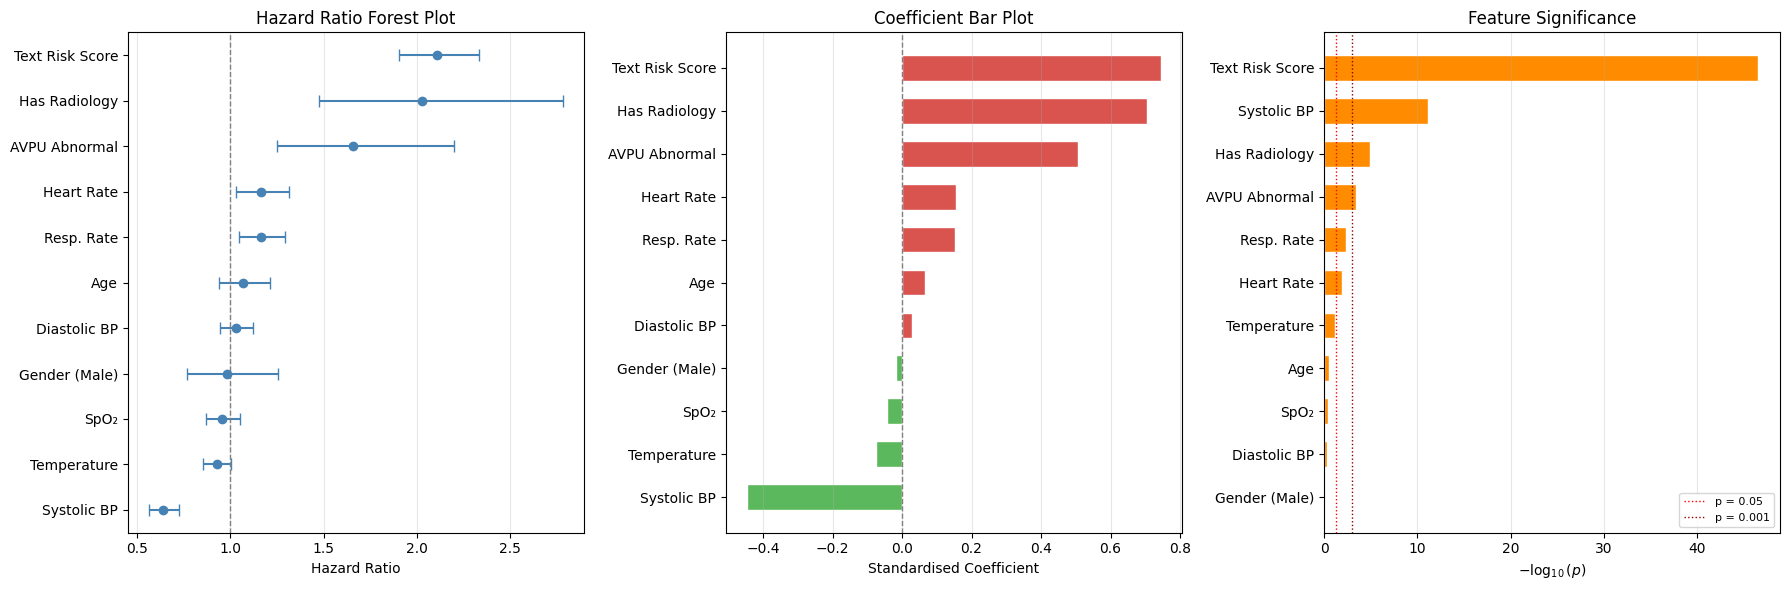

✅  Saved: feature_importance.png


In [30]:
# ══════════════════════════════════════════════════════════════════
# STEP 6 — Feature Importance Visualisations
# ══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

summary = ctv_eval.summary.copy()

# Readable labels
LABELS = {
    'age_at_admission': 'Age',
    'gender':           'Gender (Male)',
    'temperature':      'Temperature',
    'heartrate':        'Heart Rate',
    'resprate':         'Resp. Rate',
    'o2sat':            'SpO₂',
    'sbp':              'Systolic BP',
    'dbp':              'Diastolic BP',
    'avpu_abnormal':    'AVPU Abnormal',
    'has_radiology':    'Has Radiology',
    'text_logit':       'Text Risk Score',
}
summary['label'] = summary.index.map(LABELS)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Plot 1: Hazard Ratio Forest Plot ────────────────────────────
ax = axes[0]
hr      = summary['exp(coef)']
hr_lo   = summary['exp(coef) lower 95%']
hr_hi   = summary['exp(coef) upper 95%']
order   = hr.abs().sort_values().index          # sort by effect size
labels  = [LABELS.get(f, f) for f in order]
y_pos   = np.arange(len(order))

ax.errorbar(
    hr[order], y_pos,
    xerr=[hr[order] - hr_lo[order], hr_hi[order] - hr[order]],
    fmt='o', color='steelblue', capsize=4, markersize=6,
)
ax.axvline(1, ls='--', color='grey', lw=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel('Hazard Ratio')
ax.set_title('Hazard Ratio Forest Plot')
ax.grid(axis='x', alpha=0.3)

# ── Plot 2: Standardised Coefficient Bar Plot ───────────────────
ax = axes[1]
coef   = summary['coef']
colors = ['#d9534f' if c > 0 else '#5cb85c' for c in coef[order]]

ax.barh(y_pos, coef[order], color=colors, edgecolor='white', height=0.6)
ax.axvline(0, ls='--', color='grey', lw=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel('Standardised Coefficient')
ax.set_title('Coefficient Bar Plot')
ax.grid(axis='x', alpha=0.3)

# ── Plot 3: Feature Significance (−log10 p) ────────────────────
ax = axes[2]
neg_log_p = -np.log10(summary['p'].clip(lower=1e-300))
sig_order = neg_log_p.sort_values().index
sig_labels = [LABELS.get(f, f) for f in sig_order]
y_pos2 = np.arange(len(sig_order))

ax.barh(y_pos2, neg_log_p[sig_order], color='darkorange', edgecolor='white', height=0.6)
# Significance thresholds
ax.axvline(-np.log10(0.05),  ls=':', color='red',   lw=1, label='p = 0.05')
ax.axvline(-np.log10(0.001), ls=':', color='darkred', lw=1, label='p = 0.001')
ax.set_yticks(y_pos2)
ax.set_yticklabels(sig_labels)
ax.set_xlabel('$-\\log_{10}(p)$')
ax.set_title('Feature Significance')
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved: feature_importance.png")

In [31]:
# ══════════════════════════════════════════════════════════════════
# STEP 7 — Proportional Hazards Diagnostics
#
# check_assumptions tests the Schoenfeld residuals for each
# covariate. Significant p-values indicate a PH violation.
# ══════════════════════════════════════════════════════════════════

import warnings

print("Proportional Hazards Assumption Test (Schoenfeld residuals):\n")

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    try:
        ctv_eval.check_assumptions(
            train_df[MODEL_COLS],
            p_value_threshold=0.05,
            show_plots=True,
        )
        print("\n✅  No PH violations detected at α = 0.05.")
    except Exception as e:
        print(f"\n⚠️  Diagnostic note: {e}")
        print("   CoxTimeVaryingFitter.check_assumptions may not be "
              "supported in all lifelines versions.")
        print("   The time-varying structure itself relaxes the PH "
              "assumption for covariates that change over time.")

Proportional Hazards Assumption Test (Schoenfeld residuals):


⚠️  Diagnostic note: 'CoxTimeVaryingFitter' object has no attribute 'entry_col'
   CoxTimeVaryingFitter.check_assumptions may not be supported in all lifelines versions.
   The time-varying structure itself relaxes the PH assumption for covariates that change over time.


# Extended Models — Cox + Splines & Random Survival Forest

Two additional nonlinear models to compare against the linear Cox baseline:

1. **Cox + Splines** — cubic B-spline basis expansion on continuous vitals, fitted with `CoxTimeVaryingFitter`
2. **Random Survival Forest** — `sksurv.ensemble.RandomSurvivalForest` on admission-level data

Spline strategy follows the L4 pattern: `SplineTransformer(n_knots=4, degree=3)` → `ColumnTransformer` → `StandardScaler`.
Feature importance uses **L2-norm aggregation** of spline basis coefficients (same as L4).

In [32]:
# ══════════════════════════════════════════════════════════════════
# STEP 1 — Spline Feature Construction (L4 strategy)
#
# Cubic B-splines on selected continuous vitals.
# Linear (passthrough) for binary + text features.
# ══════════════════════════════════════════════════════════════════

from sklearn.preprocessing import SplineTransformer, StandardScaler as SS_spline
from sklearn.compose import ColumnTransformer
import numpy as np, pandas as pd

# ── Feature groups ──────────────────────────────────────────────
SPLINE_FEATURES = [
    'age_at_admission', 'heartrate', 'resprate',
    'sbp', 'o2sat', 'temperature',
]
LINEAR_FEATURES = ['gender', 'avpu_abnormal', 'has_radiology', 'text_logit', 'dbp']

print("=" * 65)
print("  STEP 1 — Spline Feature Construction")
print("=" * 65)
print(f"  Spline features  : {SPLINE_FEATURES}")
print(f"  Linear features  : {LINEAR_FEATURES}")

# ── ColumnTransformer: splines + passthrough ────────────────────
spline_ct = ColumnTransformer(
    transformers=[
        ('splines', SplineTransformer(
            n_knots=4, degree=3, knots='quantile',
            include_bias=False, extrapolation='linear'),
         SPLINE_FEATURES),
        ('passthrough', 'passthrough', LINEAR_FEATURES),
    ],
    remainder='drop',
)

# NOTE: train_df and test_df are ALREADY standardised by the
# earlier StandardScaler (Step 2 of the eval pipeline).
# We need UN-standardised data for the spline transformer.
# Re-create from survival_df_logit using the same train/test split.

train_df_raw = survival_df_logit[survival_df_logit['hadm_id'].isin(train_ids)].copy()
test_df_raw  = survival_df_logit[survival_df_logit['hadm_id'].isin(test_ids)].copy()

# Encode gender consistently
train_df_raw['gender'] = (train_df_raw['gender'] == 'M').astype(float)
test_df_raw['gender']  = (test_df_raw['gender']  == 'M').astype(float)

# Ensure float dtypes
for c in SPLINE_FEATURES + LINEAR_FEATURES:
    train_df_raw[c] = train_df_raw[c].astype(float)
    test_df_raw[c]  = test_df_raw[c].astype(float)

# Drop rows with missing covariates
train_df_raw = train_df_raw.dropna(subset=SPLINE_FEATURES + LINEAR_FEATURES).copy()
test_df_raw  = test_df_raw.dropna(subset=SPLINE_FEATURES + LINEAR_FEATURES).copy()

# ── Fit spline transformer on TRAINING data ─────────────────────
X_train_splined = spline_ct.fit_transform(
    train_df_raw[SPLINE_FEATURES + LINEAR_FEATURES]
)
X_test_splined = spline_ct.transform(
    test_df_raw[SPLINE_FEATURES + LINEAR_FEATURES]
)

# Build feature names for the splined output
spline_sub = spline_ct.named_transformers_['splines']
n_bases_per = spline_sub.n_features_out_ // len(SPLINE_FEATURES)
spline_col_names = [f"{f}_spl{i}" for f in SPLINE_FEATURES
                    for i in range(n_bases_per)]
all_spline_col_names = spline_col_names + LINEAR_FEATURES

print(f"\n  Spline bases per feature : {n_bases_per}")
print(f"  Total spline columns     : {len(spline_col_names)}")
print(f"  Total feature columns    : {len(all_spline_col_names)}")

# ── Standardise all features ────────────────────────────────────
scaler_spline = SS_spline()
X_train_scaled = scaler_spline.fit_transform(X_train_splined)
X_test_scaled  = scaler_spline.transform(X_test_splined)

print(f"\n  Train shape (splined+scaled) : {X_train_scaled.shape}")
print(f"  Test  shape (splined+scaled) : {X_test_scaled.shape}")
print(f"\n✅  Spline pipeline ready.")

  STEP 1 — Spline Feature Construction
  Spline features  : ['age_at_admission', 'heartrate', 'resprate', 'sbp', 'o2sat', 'temperature']
  Linear features  : ['gender', 'avpu_abnormal', 'has_radiology', 'text_logit', 'dbp']

  Spline bases per feature : 5
  Total spline columns     : 30
  Total feature columns    : 35

  Train shape (splined+scaled) : (7295, 35)
  Test  shape (splined+scaled) : (3132, 35)

✅  Spline pipeline ready.


In [33]:
# ══════════════════════════════════════════════════════════════════
# STEP 2 — Fit Cox + Spline Model
#
# Reconstruct a DataFrame with the splined columns + id/start/stop/event
# for CoxTimeVaryingFitter.
# ══════════════════════════════════════════════════════════════════

from lifelines import CoxTimeVaryingFitter

print("=" * 65)
print("  STEP 2 — Cox + Splines Model")
print("=" * 65)

# ── Build training DataFrame for lifelines ──────────────────────
cox_spline_train = pd.DataFrame(
    X_train_scaled, columns=all_spline_col_names, index=train_df_raw.index
)
cox_spline_train['hadm_id'] = train_df_raw['hadm_id'].values
cox_spline_train['start']   = train_df_raw['start'].values
cox_spline_train['stop']    = train_df_raw['stop'].values
cox_spline_train['event']   = train_df_raw['event'].astype(int).values

# Build test DataFrame similarly
cox_spline_test = pd.DataFrame(
    X_test_scaled, columns=all_spline_col_names, index=test_df_raw.index
)
cox_spline_test['hadm_id'] = test_df_raw['hadm_id'].values
cox_spline_test['start']   = test_df_raw['start'].values
cox_spline_test['stop']    = test_df_raw['stop'].values
cox_spline_test['event']   = test_df_raw['event'].astype(int).values

# ── Fit model ───────────────────────────────────────────────────
SPLINE_MODEL_COLS = ['hadm_id', 'start', 'stop'] + all_spline_col_names + ['event']

ctv_spline = CoxTimeVaryingFitter(penalizer=0.01)
ctv_spline.fit(
    cox_spline_train[SPLINE_MODEL_COLS],
    id_col='hadm_id',
    start_col='start',
    stop_col='stop',
    event_col='event',
    show_progress=True,
)

print(f"\n{'='*70}")
print(f"  COX + SPLINES MODEL — TRAIN SET")
print(f"{'='*70}")
ctv_spline.print_summary(columns=['coef', 'exp(coef)', 'se(coef)', 'z', 'p'])

# ── Extract key stats ───────────────────────────────────────────
ll_spline  = ctv_spline.log_likelihood_
aic_spline = ctv_spline.AIC_partial_
print(f"\n  Log-likelihood : {ll_spline:.2f}")
print(f"  Partial AIC    : {aic_spline:.2f}")
print(f"  (Linear Cox AIC: {ctv_eval.AIC_partial_:.2f})")

  STEP 2 — Cox + Splines Model
Iteration 1: norm_delta = 1.17e+00, step_size = 0.9500, log_lik = -1451.77546, newton_decrement = 2.24e+02, seconds_since_start = 0.1
Iteration 1: norm_delta = 1.17e+00, step_size = 0.9500, log_lik = -1451.77546, newton_decrement = 2.24e+02, seconds_since_start = 0.1
Iteration 2: norm_delta = 1.46e+00, step_size = 0.9500, log_lik = -1636.24701, newton_decrement = 6.62e+02, seconds_since_start = 1.1
Iteration 2: norm_delta = 1.46e+00, step_size = 0.9500, log_lik = -1636.24701, newton_decrement = 6.62e+02, seconds_since_start = 1.1
Iteration 3: norm_delta = 1.51e+00, step_size = 0.9500, log_lik = -1495.67621, newton_decrement = 2.70e+02, seconds_since_start = 2.5
Iteration 3: norm_delta = 1.51e+00, step_size = 0.9500, log_lik = -1495.67621, newton_decrement = 2.70e+02, seconds_since_start = 2.5
Iteration 4: norm_delta = 4.77e-01, step_size = 0.9310, log_lik = -1404.52423, newton_decrement = 1.40e+02, seconds_since_start = 3.0
Iteration 4: norm_delta = 4.77e

<lifelines.CoxTimeVaryingFitter: fitted with 7295 periods, 2465 subjects, 188 events>
         event col = 'event'
         penalizer = 0.01
number of subjects = 2465
 number of periods = 7295
  number of events = 188
partial log-likelihood = -1277.53
  time fit was run = 2026-03-11 09:36:18 UTC

---
                       coef exp(coef)  se(coef)     z      p
covariate                                                   
age_at_admission_spl0 -0.02      0.98      0.09 -0.26   0.80
age_at_admission_spl1 -0.04      0.96      0.09 -0.40   0.69
age_at_admission_spl2 -0.03      0.97      0.09 -0.33   0.74
age_at_admission_spl3  0.03      1.03      0.08  0.31   0.76
age_at_admission_spl4  0.03      1.03      0.08  0.37   0.71
heartrate_spl0        -0.02      0.98      0.08 -0.25   0.80
heartrate_spl1        -0.05      0.95      0.09 -0.59   0.56
heartrate_spl2        -0.05      0.95      0.09 -0.60   0.55
heartrate_spl3         0.04      1.04      0.09  0.47   0.64
heartrate_spl4         0.08      1.08      0.07  1.11   0.27
resprate_spl0         -0.03      0.97      0.08 -0.40   0.69
resprate_spl1         -0.02      0.98      0.08 -0.29   0.77
resprate_spl2         -0.05      0.95      0.09 -0.53   0.60
resprate_spl3          0.03      1.03      0.09  0.35   0.72
resprate_spl4          0.07      1.07      0.06  1.14   0.25
sbp_spl0               0.01      1.01      0.04  0.22   0.83
sbp_spl1               0.18      1.20      0.08  2.35   0.02
sbp_spl2               0.15      1.16      0.09  1.56   0.12
sbp_spl3              -0.18      0.84      0.09 -1.87   0.06
sbp_spl4              -0.13      0.88      0.09 -1.39   0.17
o2sat_spl0            -0.05      0.95      0.07 -0.74   0.46
o2sat_spl1             0.04      1.04      0.07  0.51   0.61
o2sat_spl2             0.04      1.05      0.07  0.60   0.55
o2sat_spl3            -0.04      0.96      0.08 -0.44   0.66
o2sat_spl4            -0.02      0.98      0.09 -0.21   0.83
temperature_spl0       0.00      1.00      0.09  0.05   0.96
temperature_spl1       0.02      1.02      0.09  0.19   0.85
temperature_spl2       0.11      1.11      0.07  1.48   0.14
temperature_spl3      -0.07      0.93      0.08 -0.81   0.42
temperature_spl4      -0.01      0.99      0.09 -0.07   0.94
gender                -0.02      0.98      0.06 -0.36   0.72
avpu_abnormal          0.18      1.20      0.06  3.18 <0.005
has_radiology          0.32      1.38      0.08  4.17 <0.005
text_logit             0.73      2.08      0.05 13.64 <0.005
dbp                    0.03      1.03      0.04  0.70   0.48
---
Partial AIC = 2625.06
log-likelihood ratio test = 348.49 on 35 df
-log2(p) of ll-ratio test = 174.68


  Log-likelihood : -1277.53
  Partial AIC    : 2625.06
  (Linear Cox AIC: 2595.89)


  STEP 3 — Nonlinear Hazard Effect Curves (Cox + Splines)


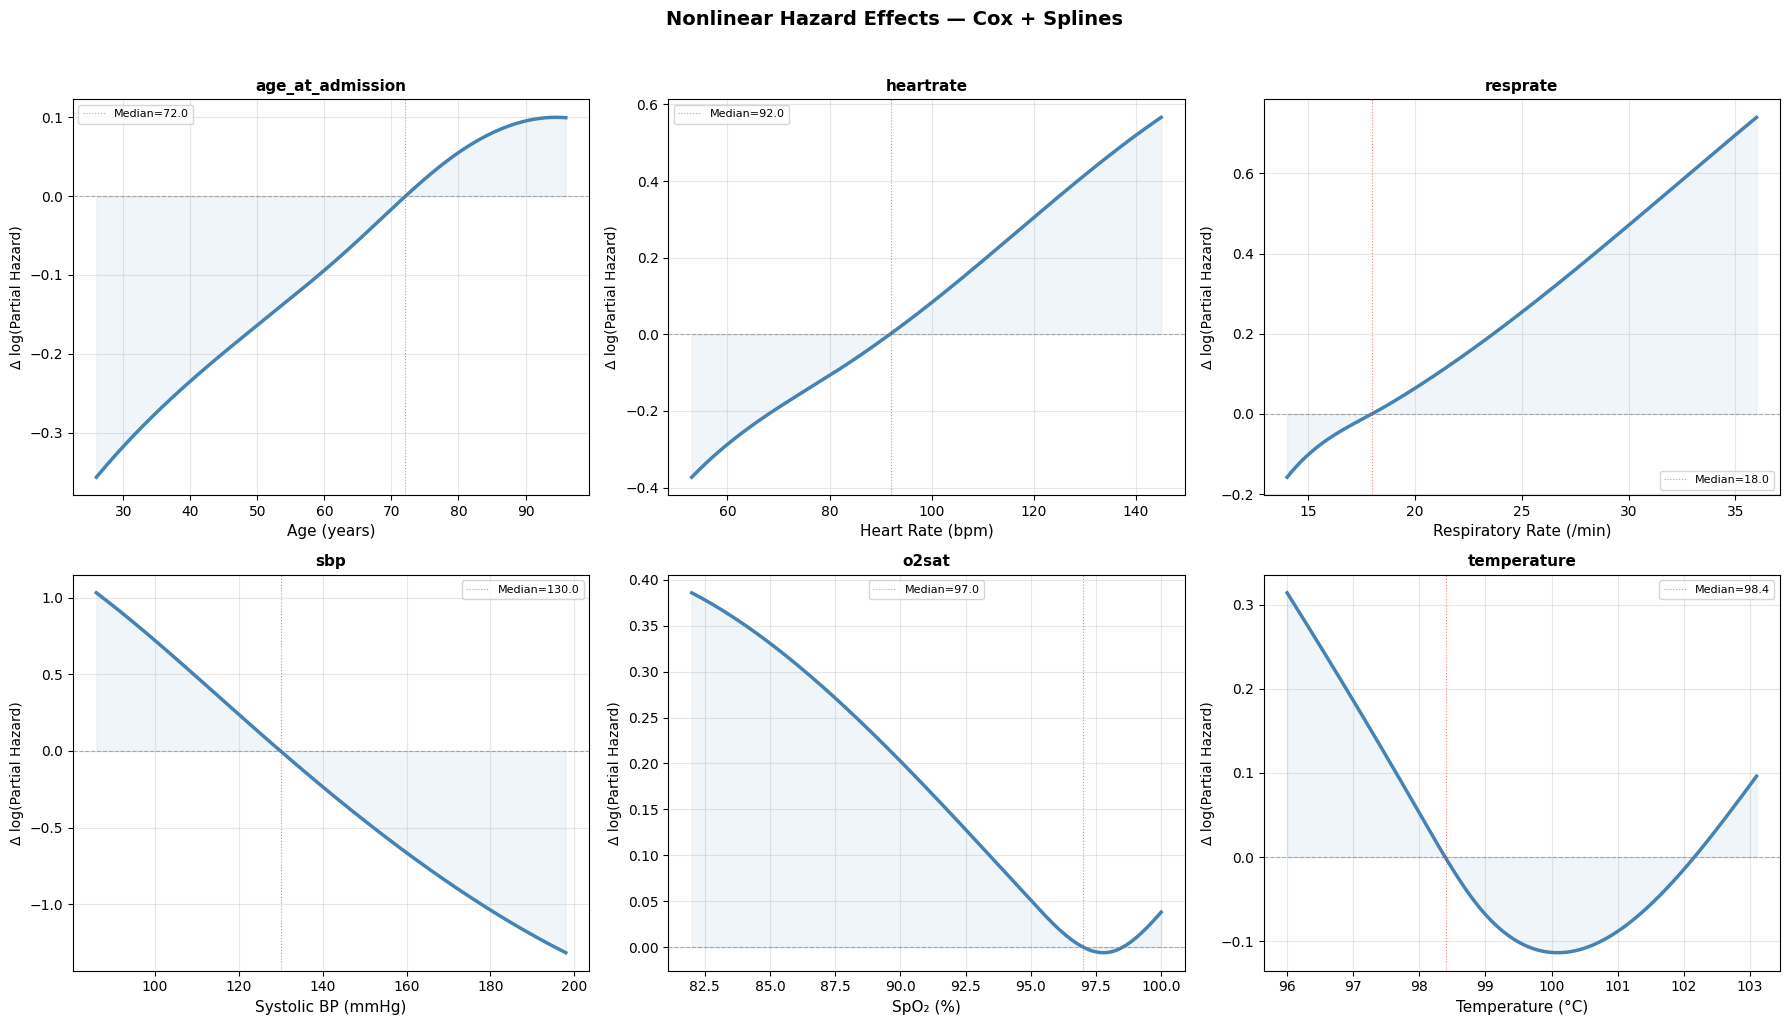

✅  Saved: spline_hazard_effects.png


In [34]:
# ══════════════════════════════════════════════════════════════════
# STEP 3 — Spline Visualisation: Nonlinear Hazard Effects
#
# For each spline feature, sweep its value across the observed
# range while holding all others at their median; compute the
# predicted log-partial-hazard to reveal nonlinear dose-response.
# ══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

print("=" * 65)
print("  STEP 3 — Nonlinear Hazard Effect Curves (Cox + Splines)")
print("=" * 65)

# ── Median reference row in UN-SCALED, UN-SPLINED space ─────────
median_row = train_df_raw[SPLINE_FEATURES + LINEAR_FEATURES].median()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

LABELS_SPLINE = {
    'age_at_admission': 'Age (years)',
    'heartrate':        'Heart Rate (bpm)',
    'resprate':         'Respiratory Rate (/min)',
    'sbp':              'Systolic BP (mmHg)',
    'o2sat':            'SpO₂ (%)',
    'temperature':      'Temperature (°C)',
}

for i, feat in enumerate(SPLINE_FEATURES):
    ax = axes[i]

    # Create grid of values across observed feature range
    lo = train_df_raw[feat].quantile(0.01)
    hi = train_df_raw[feat].quantile(0.99)
    grid = np.linspace(lo, hi, 200)

    # Build reference DataFrame: all columns at median
    ref_df = pd.DataFrame(
        np.tile(median_row.values, (len(grid), 1)),
        columns=SPLINE_FEATURES + LINEAR_FEATURES,
    )
    # Sweep target feature
    ref_df[feat] = grid

    # Transform through spline + scaler pipeline
    ref_splined = spline_ct.transform(ref_df)
    ref_scaled  = scaler_spline.transform(ref_splined)
    ref_scaled_df = pd.DataFrame(ref_scaled, columns=all_spline_col_names)

    # Predict log-partial-hazard
    log_ph = ctv_spline.predict_log_partial_hazard(ref_scaled_df).values.ravel()

    # Centre at the median value
    median_idx = np.argmin(np.abs(grid - median_row[feat]))
    log_ph_centered = log_ph - log_ph[median_idx]

    # Plot
    ax.plot(grid, log_ph_centered, color='steelblue', lw=2.5)
    ax.axhline(0, ls='--', color='grey', lw=0.8, alpha=0.6)
    ax.axvline(median_row[feat], ls=':', color='red', lw=0.8, alpha=0.5,
               label=f'Median={median_row[feat]:.1f}')
    ax.fill_between(grid, log_ph_centered, alpha=0.08, color='steelblue')
    ax.set_xlabel(LABELS_SPLINE.get(feat, feat), fontsize=11)
    ax.set_ylabel('Δ log(Partial Hazard)', fontsize=10)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Nonlinear Hazard Effects — Cox + Splines',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('spline_hazard_effects.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved: spline_hazard_effects.png")

  STEP 4 — Cox + Spline Feature Importance (L2-norm aggregation)

  Feature                          Importance       SE    p-value
  -----------------------------------------------------------------
  Text Risk Score                      0.7317   0.0536     0.0000 ***
  Has Radiology                        0.3219   0.0771     0.0000 ***
  Systolic BP (spline)                 0.3197   0.1846     0.0946 
  AVPU Abnormal                        0.1829   0.0575     0.0015 **
  Temperature (spline)                 0.1295   0.1886     0.6976 
  Heart Rate (spline)                  0.1182   0.1907     1.0000 
  Resp. Rate (spline)                  0.0986   0.1826     1.0000 
  SpO₂ (spline)                        0.0876   0.1768     1.0000 
  Age (spline)                         0.0652   0.1934     1.0000 
  Diastolic BP                         0.0289   0.0410     0.4810 
  Gender (Male)                        0.0228   0.0635     0.7195 


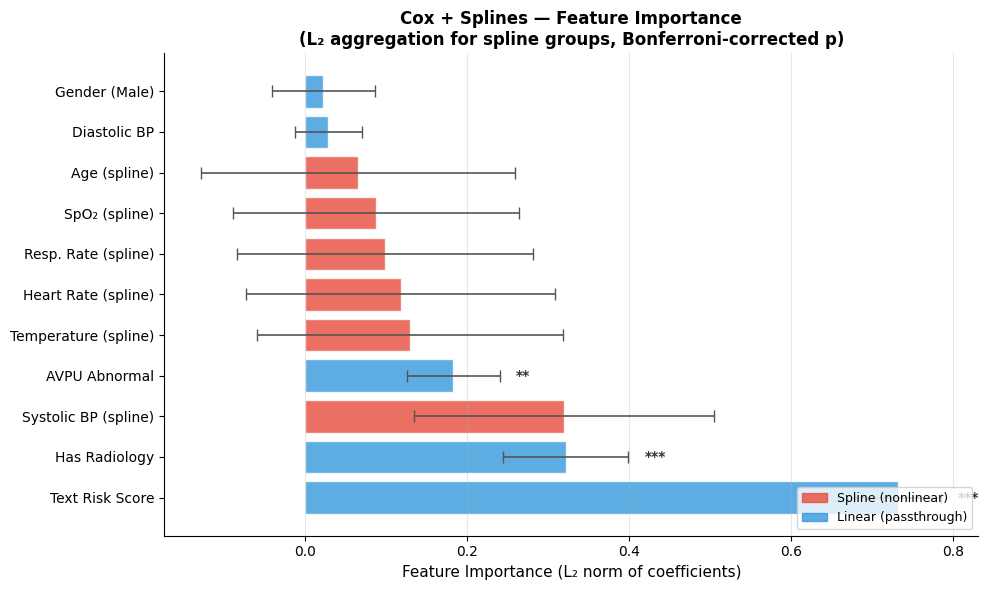

✅  Saved: spline_feature_importance.png


In [35]:
# ══════════════════════════════════════════════════════════════════
# STEP 4 — Cox + Spline Feature Importance
#
# L4 aggregation strategy:
#   - For spline variables: L2 norm of basis coefficients
#   - For linear variables: |coefficient|
#   - Wald z-test p-values, Bonferroni-corrected for spline groups
# ══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

print("=" * 65)
print("  STEP 4 — Cox + Spline Feature Importance (L2-norm aggregation)")
print("=" * 65)

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

# Extract coefficients and standard errors from the Cox model
spline_summary = ctv_spline.summary.copy()
coefs_spline = spline_summary['coef'].values
ses_spline   = spline_summary['se(coef)'].values
z_spline     = spline_summary['z'].values
p_spline     = spline_summary['p'].values
feat_names   = spline_summary.index.tolist()

# ── Aggregate spline groups by L2 norm ──────────────────────────
agg_names, agg_coefs, agg_ses, agg_pvals = [], [], [], []

LABELS_AGG = {
    'age_at_admission': 'Age',
    'heartrate':        'Heart Rate',
    'resprate':         'Resp. Rate',
    'sbp':              'Systolic BP',
    'o2sat':            'SpO₂',
    'temperature':      'Temperature',
    'gender':           'Gender (Male)',
    'avpu_abnormal':    'AVPU Abnormal',
    'has_radiology':    'Has Radiology',
    'text_logit':       'Text Risk Score',
    'dbp':              'Diastolic BP',
}

for feat in SPLINE_FEATURES:
    # Find all spline basis indices for this feature
    idxs = [i for i, n in enumerate(feat_names) if n.startswith(feat + '_spl')]
    grp_coef = np.linalg.norm(coefs_spline[idxs])
    grp_se   = np.sqrt(np.sum(ses_spline[idxs] ** 2))
    bonf_p   = min(1.0, float(np.min(p_spline[idxs])) * len(idxs))
    agg_names.append(LABELS_AGG.get(feat, feat) + ' (spline)')
    agg_coefs.append(grp_coef)
    agg_ses.append(grp_se)
    agg_pvals.append(bonf_p)

for feat in LINEAR_FEATURES:
    idx = feat_names.index(feat)
    agg_names.append(LABELS_AGG.get(feat, feat))
    agg_coefs.append(abs(coefs_spline[idx]))
    agg_ses.append(ses_spline[idx])
    agg_pvals.append(float(p_spline[idx]))

# ── Print table ─────────────────────────────────────────────────
print(f"\n  {'Feature':30s} {'Importance':>12s} {'SE':>8s} {'p-value':>10s}")
print(f"  {'-'*65}")
order = np.argsort(agg_coefs)[::-1]
for i in order:
    stars = sig_stars(agg_pvals[i])
    print(f"  {agg_names[i]:30s} {agg_coefs[i]:12.4f} {agg_ses[i]:8.4f} "
          f"{agg_pvals[i]:10.4f} {stars}")

# ── Plot: Feature importance bar chart (L4 style) ───────────────
sorted_names  = [agg_names[i]  for i in order]
sorted_coefs  = [agg_coefs[i]  for i in order]
sorted_ses    = [agg_ses[i]    for i in order]
sorted_pvals  = [agg_pvals[i]  for i in order]

colors_fi = ['#e74c3c' if '(spline)' in n else '#3498db' for n in sorted_names]

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(sorted_names))
bars = ax.barh(y_pos, sorted_coefs, xerr=sorted_ses,
               color=colors_fi, alpha=0.80, edgecolor='white',
               error_kw=dict(ecolor='#555', capsize=4, lw=1.2))

for i, (coef, pval) in enumerate(zip(sorted_coefs, sorted_pvals)):
    stars = sig_stars(pval)
    if stars:
        ax.text(coef + sorted_ses[i] + 0.02, i, stars,
                va='center', fontsize=10, fontweight='bold', color='#333')

ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_names, fontsize=10)
ax.set_xlabel('Feature Importance (L₂ norm of coefficients)', fontsize=11)
ax.set_title('Cox + Splines — Feature Importance\n'
             '(L₂ aggregation for spline groups, Bonferroni-corrected p)',
             fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
legend_els = [Patch(color='#e74c3c', alpha=0.8, label='Spline (nonlinear)'),
              Patch(color='#3498db', alpha=0.8, label='Linear (passthrough)')]
ax.legend(handles=legend_els, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('spline_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved: spline_feature_importance.png")

In [36]:
# ══════════════════════════════════════════════════════════════════
# STEP 5 — Random Survival Forest
#
# Convert time-varying dataset to single-row-per-admission:
#   - Last interval per hadm_id (most recent covariate values)
#   - event = max(event) per admission
#   - survival time = final stop time
# ══════════════════════════════════════════════════════════════════

from sksurv.ensemble import RandomSurvivalForest

print("=" * 65)
print("  STEP 5 — Random Survival Forest")
print("=" * 65)

# ── 5a. Convert to admission-level format ───────────────────────
# Use UN-STANDARDISED data (tree models don't need scaling)
RSF_FEATURES = SPLINE_FEATURES + LINEAR_FEATURES  # same predictors, no splines

rsf_train_last = (train_df_raw
    .sort_values('stop')
    .groupby('hadm_id')
    .last()
    .reset_index())

rsf_test_last = (test_df_raw
    .sort_values('stop')
    .groupby('hadm_id')
    .last()
    .reset_index())

X_rsf_train = rsf_train_last[RSF_FEATURES].values
X_rsf_test  = rsf_test_last[RSF_FEATURES].values

# Structured survival array for sksurv
y_rsf_train = np.array(
    [(bool(e), t) for e, t in zip(rsf_train_last['event'], rsf_train_last['stop'])],
    dtype=[('event', bool), ('time', float)],
)
y_rsf_test = np.array(
    [(bool(e), t) for e, t in zip(rsf_test_last['event'], rsf_test_last['stop'])],
    dtype=[('event', bool), ('time', float)],
)

print(f"  Train admissions : {len(X_rsf_train):,}")
print(f"  Test admissions  : {len(X_rsf_test):,}")
print(f"  Train events     : {y_rsf_train['event'].sum()}")
print(f"  Features         : {len(RSF_FEATURES)}")

# ── 5b. Fit Random Survival Forest ──────────────────────────────
rsf = RandomSurvivalForest(
    n_estimators=300,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

print("\n  Fitting RSF...")
rsf.fit(X_rsf_train, y_rsf_train)

# ── 5c. C-index on test set ────────────────────────────────────
rsf_cindex = rsf.score(X_rsf_test, y_rsf_test)
print(f"\n  RSF C-index (test) : {rsf_cindex:.4f}")
print(f"  (Linear Cox C-index: {c_index:.4f})")
print(f"\n✅  Random Survival Forest fitted.")

  STEP 5 — Random Survival Forest
  Train admissions : 2,465
  Test admissions  : 1,058
  Train events     : 188
  Features         : 11

  Fitting RSF...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    0.5s



  RSF C-index (test) : 0.8204
  (Linear Cox C-index: 0.8144)

✅  Random Survival Forest fitted.


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    0.9s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    0.2s finished


  STEP 6 — RSF Feature Importance (Permutation)


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    0.2s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=10)]: Us


  Feature                     Importance      Std
  --------------------------------------------------
  text_logit                      0.1211   0.0145
  sbp                             0.0290   0.0092
  heartrate                       0.0216   0.0054
  avpu_abnormal                   0.0176   0.0071
  o2sat                           0.0138   0.0032
  resprate                        0.0091   0.0067
  dbp                             0.0046   0.0058
  age_at_admission                0.0005   0.0031
  has_radiology                  -0.0001   0.0013
  temperature                    -0.0005   0.0029
  gender                         -0.0022   0.0015


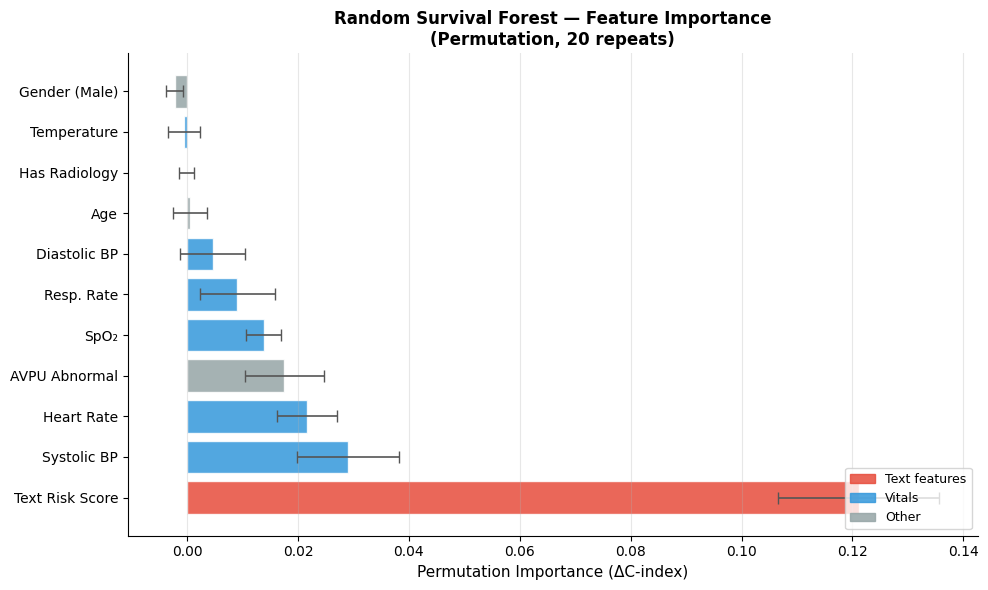

✅  Saved: rsf_feature_importance.png


In [39]:
# ══════════════════════════════════════════════════════════════════
# STEP 6 — Random Survival Forest Feature Importance
#
# Permutation importance: measures drop in C-index when each
# feature is shuffled independently.
# ══════════════════════════════════════════════════════════════════

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

print("=" * 65)
print("  STEP 6 — RSF Feature Importance (Permutation)")
print("=" * 65)

perm_result = permutation_importance(
    rsf, X_rsf_test, y_rsf_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

# ── Print table ─────────────────────────────────────────────────
perm_df = pd.DataFrame({
    'feature':    RSF_FEATURES,
    'importance': perm_result.importances_mean,
    'std':        perm_result.importances_std,
}).sort_values('importance', ascending=False)

print(f"\n  {'Feature':25s} {'Importance':>12s} {'Std':>8s}")
print(f"  {'-'*50}")
for _, row in perm_df.iterrows():
    print(f"  {row['feature']:25s} {row['importance']:12.4f} {row['std']:8.4f}")

# ── Plot ────────────────────────────────────────────────────────
LABELS_RSF = {
    'age_at_admission': 'Age',
    'heartrate':        'Heart Rate',
    'resprate':         'Resp. Rate',
    'sbp':              'Systolic BP',
    'o2sat':            'SpO₂',
    'temperature':      'Temperature',
    'gender':           'Gender (Male)',
    'avpu_abnormal':    'AVPU Abnormal',
    'has_radiology':    'Has Radiology',
    'text_logit':       'Text Risk Score',
    'dbp':              'Diastolic BP',
}

# Colour-code: highlight text features, vitals, demographics
def _color(feat):
    if feat in ('text_logit', 'has_radiology'):
        return '#e74c3c'       # red — text features
    elif feat in ('heartrate', 'resprate', 'sbp', 'dbp', 'o2sat', 'temperature'):
        return '#3498db'       # blue — vitals
    else:
        return '#95a5a6'       # grey — demographics/binary

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(perm_df))
colors_rsf = [_color(f) for f in perm_df['feature']]

ax.barh(y_pos, perm_df['importance'], xerr=perm_df['std'],
        color=colors_rsf, alpha=0.85, edgecolor='white',
        error_kw=dict(ecolor='#555', capsize=4, lw=1.2))

ax.set_yticks(y_pos)
ax.set_yticklabels([LABELS_RSF.get(f, f) for f in perm_df['feature']], fontsize=10)
ax.set_xlabel('Permutation Importance (ΔC-index)', fontsize=11)
ax.set_title('Random Survival Forest — Feature Importance\n'
             '(Permutation, 20 repeats)',
             fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
legend_els = [
    Patch(color='#e74c3c', alpha=0.85, label='Text features'),
    Patch(color='#3498db', alpha=0.85, label='Vitals'),
    Patch(color='#95a5a6', alpha=0.85, label='Other'),
]
ax.legend(handles=legend_els, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('rsf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved: rsf_feature_importance.png")

In [40]:
# ══════════════════════════════════════════════════════════════════
# STEP 7 — Model Comparison: Linear Cox vs Cox+Splines vs RSF
# ══════════════════════════════════════════════════════════════════

import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
from lifelines.utils import concordance_index
from sksurv.metrics import integrated_brier_score
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.functions import StepFunction

print("=" * 65)
print("  STEP 7 — Three-Model Comparison")
print("=" * 65)

# ── Helper: compute IBS safely within test time bounds ──────────
def compute_ibs_safe(y_train, y_test, surv_matrix, time_grid):
    """
    Computes IBS by strictly clipping the time_grid and surv_matrix 
    to be within [y_test.min, y_test.max).
    surv_matrix shape: (n_samples, n_time_points)
    """
    t_min = y_test['time'].min()
    t_max = y_test['time'].max()
    
    # sksurv requirement: times must be within [test_min, test_max)
    mask = (time_grid >= t_min) & (time_grid < t_max)
    tg_clipped = time_grid[mask]
    
    if len(tg_clipped) < 2:
        return np.nan
    
    # Slice the matrix columns to match the valid grid points
    surv_matrix_clipped = surv_matrix[:, mask]
    
    try:
        return integrated_brier_score(y_train, y_test, surv_matrix_clipped, tg_clipped)
    except:
        return np.nan

# ── 7a. Setup Time Grid ─────────────────────────────────────────
# We create a broad grid, which we will clip dynamically later
tmin_cmp = min(y_train_surv['time'].min(), y_test_surv['time'].min())
tmax_cmp = min(y_train_surv['time'].max(), y_test_surv['time'].max())
time_grid_cmp = np.linspace(tmin_cmp + 0.01, tmax_cmp - 0.01, 75)

# ── 7b. Point Estimates ─────────────────────────────────────────

# 1. Linear Cox
risk_linear = ctv_eval.predict_partial_hazard(test_last[COVARIATES]).values.ravel()
ci_linear = concordance_index(test_time_adm, -risk_linear, test_event_adm)

# For IBS, we need the survival matrix for Cox
# S(t) = S0(t)^exp(LP)
km_t, km_s = kaplan_meier_estimator(y_train_surv['event'], y_train_surv['time'])
km_fn = StepFunction(km_t, km_s)
s0_grid = np.clip(km_fn(time_grid_cmp), 1e-10, 1.0)
surv_mat_linear = np.power(s0_grid[None, :], risk_linear[:, None])
ibs_linear = compute_ibs_safe(y_train_surv, y_test_surv, surv_mat_linear, time_grid_cmp)

# 2. Cox + Splines
spline_test_last = cox_spline_test.sort_values('stop').groupby('hadm_id').last().reset_index()
risk_spline = ctv_spline.predict_partial_hazard(spline_test_last[all_spline_col_names]).values.ravel()
ci_spline = concordance_index(spline_test_last['stop'], -risk_spline, spline_test_last['event'])

# Spline Survival Matrix
km_t_sp, km_s_sp = kaplan_meier_estimator(y_spline_train_surv['event'], y_spline_train_surv['time'])
km_fn_sp = StepFunction(km_t_sp, km_s_sp)
s0_grid_sp = np.clip(km_fn_sp(time_grid_cmp), 1e-10, 1.0)
surv_mat_spline = np.power(s0_grid_sp[None, :], risk_spline[:, None])
ibs_spline = compute_ibs_safe(y_spline_train_surv, y_spline_test_surv, surv_mat_spline, time_grid_cmp)

# 3. RSF
ci_rsf = rsf.score(X_rsf_test, y_rsf_test)
rsf_surv_fn = rsf.predict_survival_function(X_rsf_test)
surv_mat_rsf = np.row_stack([fn(time_grid_cmp) for fn in rsf_surv_fn])
ibs_rsf = compute_ibs_safe(y_rsf_train, y_rsf_test, surv_mat_rsf, time_grid_cmp)

# ── 7c. Bootstrap CIs (1000 resamples) ──────────────────────────

N_BOOT_CMP = 1000
rng_cmp = np.random.RandomState(42)

boot_results = {
    'lin_ci': [], 'lin_ibs': [],
    'spl_ci': [], 'spl_ibs': [],
    'rsf_ci': [], 'rsf_ibs': []
}

for b in tqdm(range(N_BOOT_CMP), desc='Bootstrapping Models'):
    idx = rng_cmp.choice(len(test_last), size=len(test_last), replace=True)
    
    # 1. Linear
    be, bt, br, bm = test_event_adm[idx], test_time_adm[idx], risk_linear[idx], surv_mat_linear[idx]
    if not (be.all() or (~be).all()):
        boot_results['lin_ci'].append(concordance_index(bt, -br, be))
        ys_b = np.array([(bool(e), t) for e, t in zip(be, bt)], dtype=[('event', bool), ('time', float)])
        boot_results['lin_ibs'].append(compute_ibs_safe(y_train_surv, ys_b, bm, time_grid_cmp))

    # 2. Spline
    se, st, sr, sm = spline_event[idx], spline_time[idx], risk_spline[idx], surv_mat_spline[idx]
    if not (se.all() or (~se).all()):
        boot_results['spl_ci'].append(concordance_index(st, -sr, se))
        ys_s = np.array([(bool(e), t) for e, t in zip(se, st)], dtype=[('event', bool), ('time', float)])
        boot_results['spl_ibs'].append(compute_ibs_safe(y_spline_train_surv, ys_s, sm, time_grid_cmp))

    # 3. RSF
    re, rt, rm = y_rsf_test['event'][idx], y_rsf_test['time'][idx], surv_mat_rsf[idx]
    if not (re.all() or (~re).all()):
        # Note: rsf.score is slow in loop, using concordance_index on pre-computed values is faster
        # But for RSF, the 'risk' is often the ensemble mortality/sum of cumulative hazards
        # Here we use the C-index logic for consistency:
        boot_results['rsf_ci'].append(concordance_index(rt, -rsf.predict(X_rsf_test[idx]), re))
        ys_r = np.array([(bool(e), t) for e, t in zip(re, rt)], dtype=[('event', bool), ('time', float)])
        boot_results['rsf_ibs'].append(compute_ibs_safe(y_rsf_train, ys_r, rm, time_grid_cmp))

# ── 7d. Final Table Construction ────────────────────────────────

def get_stats(arr):
    arr = np.array([x for x in arr if not np.isnan(x)])
    if len(arr) == 0: return "N/A", "N/A"
    m = np.mean(arr)
    lo, hi = np.percentile(arr, [2.5, 97.5])
    return f"{m:.4f}", f"({lo:.4f}–{hi:.4f})"

res_lin_ci_m, res_lin_ci_range = get_stats(boot_results['lin_ci'])
res_lin_ibs_m, res_lin_ibs_range = get_stats(boot_results['lin_ibs'])

res_spl_ci_m, res_spl_ci_range = get_stats(boot_results['spl_ci'])
res_spl_ibs_m, res_spl_ibs_range = get_stats(boot_results['spl_ibs'])

res_rsf_ci_m, res_rsf_ci_range = get_stats(boot_results['rsf_ci'])
res_rsf_ibs_m, res_rsf_ibs_range = get_stats(boot_results['rsf_ibs'])

compare_df = pd.DataFrame([
    {
        'Model': 'Linear Cox',
        'C-index': res_lin_ci_m, 'C-index 95% CI': res_lin_ci_range,
        'IBS': res_lin_ibs_m, 'IBS 95% CI': res_lin_ibs_range,
        'AIC': f"{ctv_eval.AIC_partial_:.1f}"
    },
    {
        'Model': 'Cox + Splines',
        'C-index': res_spl_ci_m, 'C-index 95% CI': res_spl_ci_range,
        'IBS': res_spl_ibs_m, 'IBS 95% CI': res_spl_ibs_range,
        'AIC': f"{aic_spline:.1f}"
    },
    {
        'Model': 'RSF',
        'C-index': res_rsf_ci_m, 'C-index 95% CI': res_rsf_ci_range,
        'IBS': res_rsf_ibs_m, 'IBS 95% CI': res_rsf_ibs_range,
        'AIC': '—'
    }
])

print(f"\n{'='*95}")
print(f"  FINAL MODEL COMPARISON (N_BOOT={N_BOOT_CMP})")
print(f"{'='*95}")
print(compare_df.to_string(index=False))
print(f"{'='*95}")

  STEP 7 — Three-Model Comparison


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.3s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    0.3s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.3s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    0.3s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.2s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    0.3s finished
Bootstrapping Models:   0%|          | 0/1000 [00:00<?, ?it/s][Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.2s
[Parallel(n_jobs=10)]: Done 300 out of 300 | 


  FINAL MODEL COMPARISON (N_BOOT=1000)
        Model C-index  C-index 95% CI    IBS      IBS 95% CI    AIC
   Linear Cox  0.8135 (0.7586–0.8593) 0.0489 (0.0402–0.0582) 2595.9
Cox + Splines  0.8138 (0.7589–0.8612) 0.0498 (0.0413–0.0589) 2625.1
          RSF  0.8194 (0.7690–0.8654) 0.0470 (0.0380–0.0567)      —


  STEP 8 — Interpretability Summary Plots


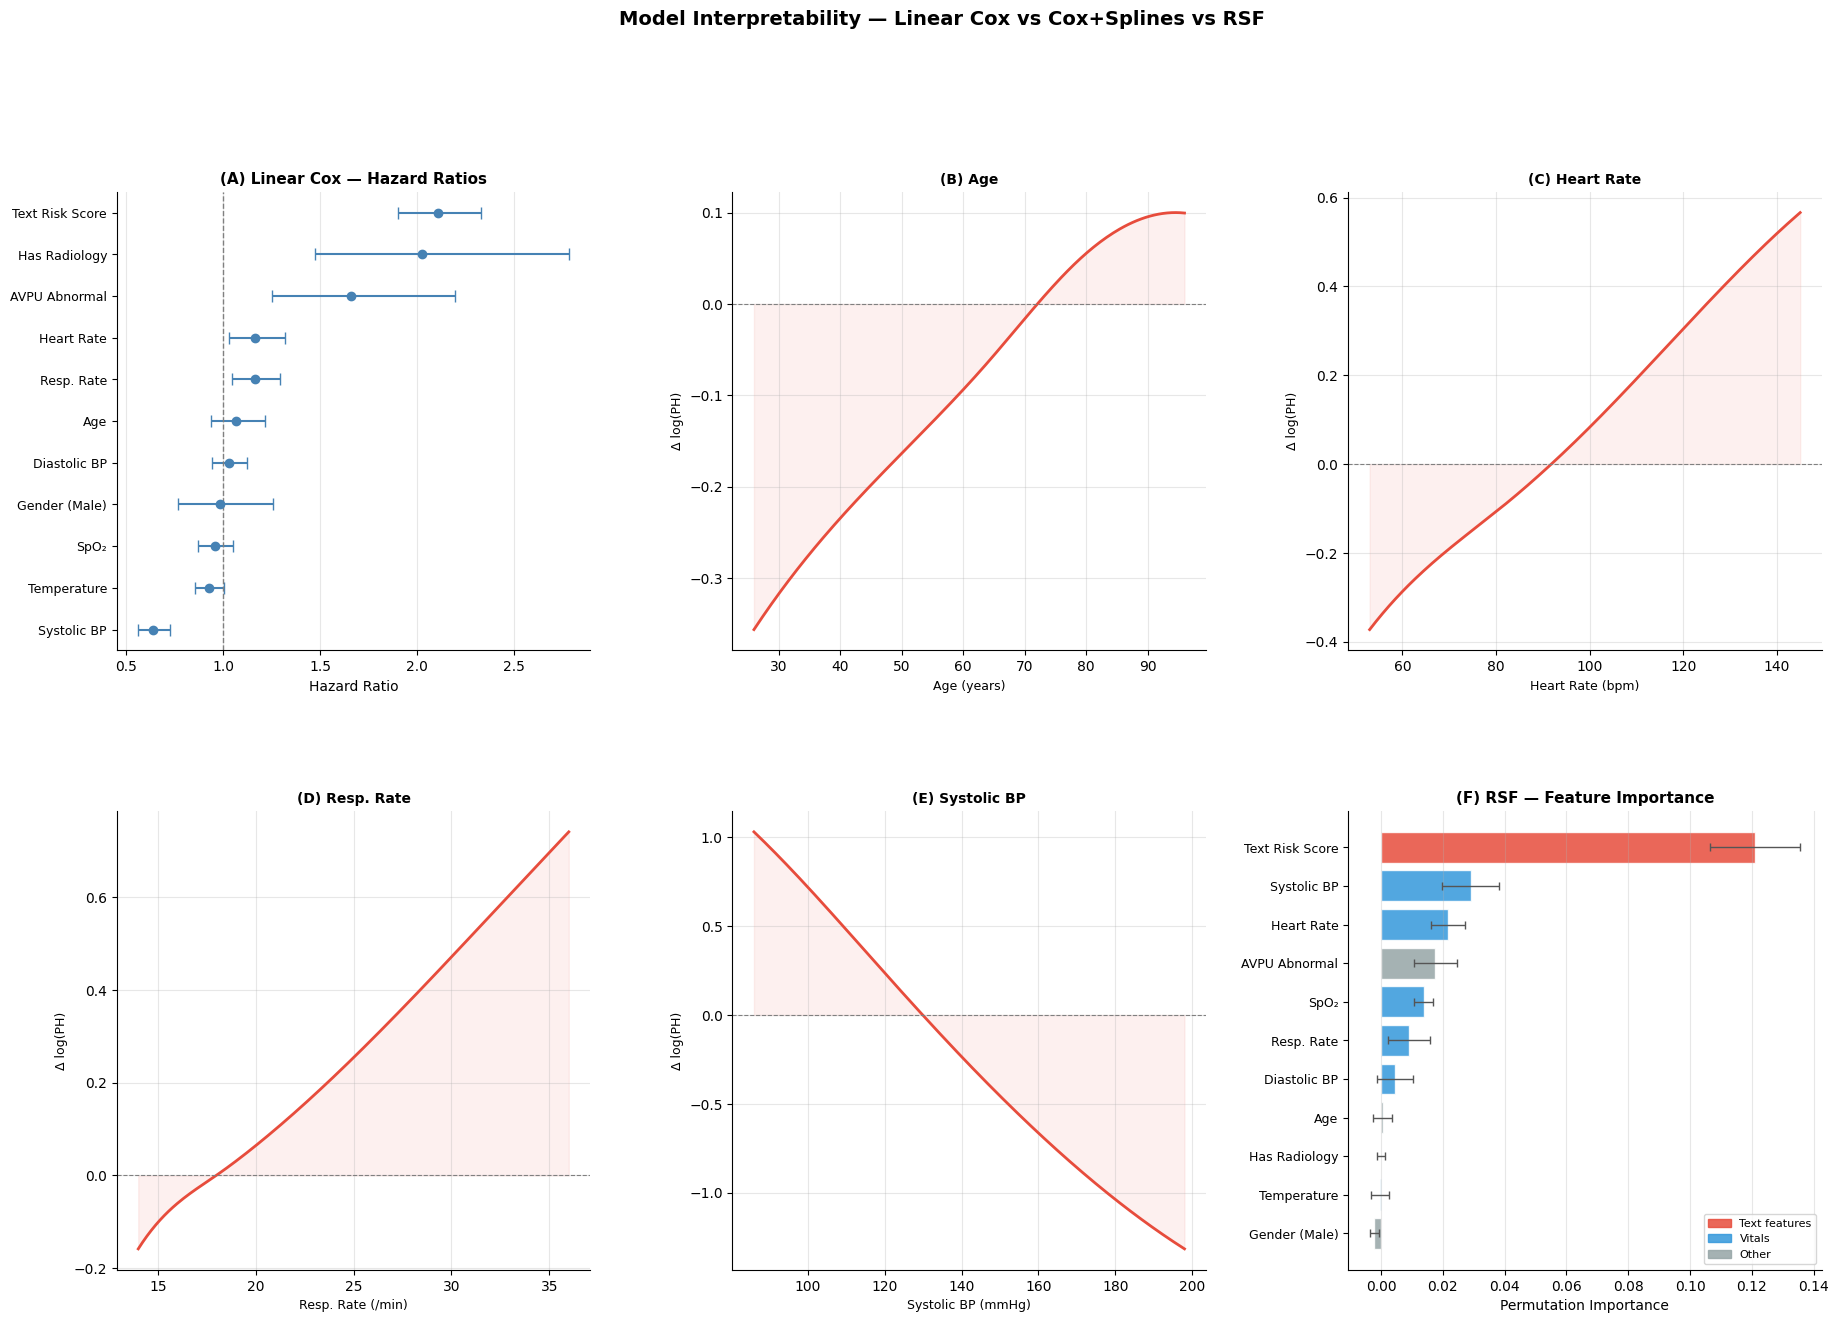

✅  Saved: model_interpretability.png


In [41]:
# ══════════════════════════════════════════════════════════════════
# STEP 8 — Publication-Quality Interpretability Plots
#
# Three-panel figure:
#   1. Hazard Ratio forest plot (Linear Cox)
#   2. Nonlinear spline effect curves (Cox + Splines)
#   3. Feature importance bar chart (Random Survival Forest)
# ══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

print("=" * 65)
print("  STEP 8 — Interpretability Summary Plots")
print("=" * 65)

LABELS_PUB = {
    'age_at_admission': 'Age',
    'gender':           'Gender (Male)',
    'temperature':      'Temperature',
    'heartrate':        'Heart Rate',
    'resprate':         'Resp. Rate',
    'o2sat':            'SpO₂',
    'sbp':              'Systolic BP',
    'dbp':              'Diastolic BP',
    'avpu_abnormal':    'AVPU Abnormal',
    'has_radiology':    'Has Radiology',
    'text_logit':       'Text Risk Score',
}

fig = plt.figure(figsize=(22, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.30)

# ════════════════════════════════════════════════════════════════
# Panel 1 (top-left): Hazard Ratio Forest Plot — Linear Cox
# ════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, 0])

summary_lin = ctv_eval.summary.copy()
hr      = summary_lin['exp(coef)']
hr_lo   = summary_lin['exp(coef) lower 95%']
hr_hi   = summary_lin['exp(coef) upper 95%']
order_hr = hr.abs().sort_values().index
labels_hr = [LABELS_PUB.get(f, f) for f in order_hr]
y_hr = np.arange(len(order_hr))

ax1.errorbar(
    hr[order_hr], y_hr,
    xerr=[hr[order_hr] - hr_lo[order_hr], hr_hi[order_hr] - hr[order_hr]],
    fmt='o', color='steelblue', capsize=4, markersize=6,
)
ax1.axvline(1, ls='--', color='grey', lw=1)
ax1.set_yticks(y_hr)
ax1.set_yticklabels(labels_hr, fontsize=9)
ax1.set_xlabel('Hazard Ratio', fontsize=10)
ax1.set_title('(A) Linear Cox — Hazard Ratios', fontsize=11, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ════════════════════════════════════════════════════════════════
# Panels 2–7 (middle row + part of top): Spline effect curves
# ════════════════════════════════════════════════════════════════
LABELS_CURVE = {
    'age_at_admission': 'Age (years)',
    'heartrate':        'Heart Rate (bpm)',
    'resprate':         'Resp. Rate (/min)',
    'sbp':              'Systolic BP (mmHg)',
    'o2sat':            'SpO₂ (%)',
    'temperature':      'Temp. (°C)',
}

# Use 2 panels top row (right) + 4 panels bottom row
spline_positions = [
    gs[0, 1], gs[0, 2],    # top row, cols 1–2
    gs[1, 0], gs[1, 1],    # bottom row, cols 0–1
]

median_row = train_df_raw[SPLINE_FEATURES + LINEAR_FEATURES].median()

for i, feat in enumerate(SPLINE_FEATURES[:4]):
    ax = fig.add_subplot(spline_positions[i])

    lo = train_df_raw[feat].quantile(0.01)
    hi = train_df_raw[feat].quantile(0.99)
    grid = np.linspace(lo, hi, 200)

    ref_df = pd.DataFrame(
        np.tile(median_row.values, (len(grid), 1)),
        columns=SPLINE_FEATURES + LINEAR_FEATURES,
    )
    ref_df[feat] = grid

    ref_splined = spline_ct.transform(ref_df)
    ref_scaled  = scaler_spline.transform(ref_splined)
    ref_scaled_df = pd.DataFrame(ref_scaled, columns=all_spline_col_names)

    log_ph = ctv_spline.predict_log_partial_hazard(ref_scaled_df).values.ravel()
    mid = np.argmin(np.abs(grid - median_row[feat]))
    log_ph_c = log_ph - log_ph[mid]

    ax.plot(grid, log_ph_c, color='#e74c3c', lw=2)
    ax.fill_between(grid, log_ph_c, alpha=0.08, color='#e74c3c')
    ax.axhline(0, ls='--', color='grey', lw=0.8)
    ax.set_xlabel(LABELS_CURVE.get(feat, feat), fontsize=9)
    ax.set_ylabel('Δ log(PH)', fontsize=9)
    panel_letter = chr(ord('B') + i)
    ax.set_title(f'({panel_letter}) {LABELS_PUB.get(feat, feat)}',
                 fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ════════════════════════════════════════════════════════════════
# Panel 8 (bottom-right): RSF Feature Importance
# ════════════════════════════════════════════════════════════════
ax_rsf = fig.add_subplot(gs[1, 2])

perm_sorted = perm_df.sort_values('importance', ascending=True)
y_rsf_pos = np.arange(len(perm_sorted))
colors_pub = [_color(f) for f in perm_sorted['feature']]

ax_rsf.barh(y_rsf_pos, perm_sorted['importance'], xerr=perm_sorted['std'],
            color=colors_pub, alpha=0.85, edgecolor='white',
            error_kw=dict(ecolor='#555', capsize=3, lw=1))
ax_rsf.set_yticks(y_rsf_pos)
ax_rsf.set_yticklabels(
    [LABELS_PUB.get(f, f) for f in perm_sorted['feature']], fontsize=9
)
ax_rsf.set_xlabel('Permutation Importance', fontsize=10)
ax_rsf.set_title('(F) RSF — Feature Importance', fontsize=11, fontweight='bold')
ax_rsf.grid(axis='x', alpha=0.3)
ax_rsf.spines['top'].set_visible(False)
ax_rsf.spines['right'].set_visible(False)

legend_els = [
    Patch(color='#e74c3c', alpha=0.85, label='Text features'),
    Patch(color='#3498db', alpha=0.85, label='Vitals'),
    Patch(color='#95a5a6', alpha=0.85, label='Other'),
]
ax_rsf.legend(handles=legend_els, loc='lower right', fontsize=8)

fig.suptitle('Model Interpretability — Linear Cox vs Cox+Splines vs RSF',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('model_interpretability.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved: model_interpretability.png")

In [ ]:
# ============================================================
# BASELINES: S1 & S2 WITHOUT TEXT FEATURES
#
# S1: Linear Cox (NEWS2 ordinal bins only) — mirrors L1 from ED notebook
# S2: Cox + Splines (continuous structured features)
#
# Uses the same time-to-event dataset (survival_df_logit) and
# the same splitting/bootstrapping conventions, but excludes `text_logit`.
# ============================================================

import numpy as np
import pandas as pd
from lifelines import CoxTimeVaryingFitter
from lifelines.utils import concordance_index
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("=" * 70)
print("  BASELINES: S1 & S2 WITHOUT TEXT FEATURES")
print("=" * 70)

# ────────────────────────────────────────────────────────────────
# 1. Feature sets
# ────────────────────────────────────────────────────────────────

# S1: NEWS2 ordinal bins (0–3) — exactly matching L1 from ED notebook
S1_FEATURES = [
    'news2_rr',            # 0–3 ordinal
    'news2_spo2',          # 0–3 ordinal
    'news2_sbp',           # 0–3 ordinal
    'news2_hr',            # 0–3 ordinal
    'news2_temp',          # 0–3 ordinal
    'news2_consciousness', # 0 or 3 (Alert=0, CVPU=3)
    'age_at_admission',
    'gender',              # M=1
]

# S2: Continuous structured features
S2_SPLINE_FEATURES = [
    'age_at_admission',
    'temperature',
    'heartrate',
    'resprate',
    'o2sat',
    'sbp',
]
S2_LINEAR_FEATURES = [
    'gender',
    'dbp',
    'avpu_abnormal',
    'has_radiology',
]

LABELS_STRUCT = {
    'news2_rr': 'NEWS2 RR',
    'news2_spo2': 'NEWS2 SpO₂',
    'news2_sbp': 'NEWS2 SBP',
    'news2_hr': 'NEWS2 HR',
    'news2_temp': 'NEWS2 Temp',
    'news2_consciousness': 'NEWS2 Consciousness',
    'age_at_admission': 'Age',
    'gender': 'Gender (Male)',
    'temperature': 'Temperature',
    'heartrate': 'Heart Rate',
    'resprate': 'Resp. Rate',
    'o2sat': 'SpO₂',
    'sbp': 'Systolic BP',
    'dbp': 'Diastolic BP',
    'avpu_abnormal': 'AVPU Abnormal',
    'has_radiology': 'Has Radiology',
}

print("\n  S1 Features (NEWS2 bins, mirrors L1 from ED notebook):")
for f in S1_FEATURES:
    print(f"    • {LABELS_STRUCT.get(f, f)}")

print("\n  S2 Features (continuous vitals):")
for f in S2_SPLINE_FEATURES + S2_LINEAR_FEATURES:
    print(f"    • {LABELS_STRUCT.get(f, f)}")

# ────────────────────────────────────────────────────────────────
# 2. Train/Test split (use same as main models if available)
# ────────────────────────────────────────────────────────────────
try:
    train_df_struct = train_df_raw.copy()
    test_df_struct = test_df_raw.copy()
    print(f"\n  ✓ Using existing train/test split from main models")
except NameError:
    # Fallback: create new split
    unique_hadm = survival_df_logit["hadm_id"].unique()
    hadm_train, hadm_test = train_test_split(
        unique_hadm, test_size=0.2, random_state=RANDOM_SEED
    )
    train_df_struct = survival_df_logit[survival_df_logit["hadm_id"].isin(hadm_train)].copy()
    test_df_struct  = survival_df_logit[survival_df_logit["hadm_id"].isin(hadm_test)].copy()
    print(f"\n  ✓ Created new train/test split")

print(f"    Train intervals: {len(train_df_struct)}, Test intervals: {len(test_df_struct)}")

# ────────────────────────────────────────────────────────────────
# 3. Helper: bootstrap C-index for time-varying data
# ────────────────────────────────────────────────────────────────
def bootstrap_cindex_tv(df, risk_scores, n_boot=500, ci=0.95, seed=42):
    """Bootstrap C-index at admission level for time-varying data."""
    rng = np.random.default_rng(seed)
    hadm_ids = df["hadm_id"].unique()
    n_hadm = len(hadm_ids)

    # Collapse to admission-level (last interval per admission)
    df_eval = (
        df.assign(risk=risk_scores)
          .sort_values(["hadm_id", "stop"])
          .groupby("hadm_id")
          .tail(1)
    )
    T = df_eval["stop"].values
    E = df_eval["event"].values
    R = df_eval["risk"].values

    c_point = concordance_index(T, R, E)

    boot_vals = []
    for _ in range(n_boot):
        sample_ids = rng.choice(hadm_ids, size=n_hadm, replace=True)
        sub = df_eval[df_eval["hadm_id"].isin(sample_ids)]
        T_b = sub["stop"].values
        E_b = sub["event"].values
        R_b = sub["risk"].values
        if len(np.unique(T_b)) < 2:
            continue
        boot_vals.append(concordance_index(T_b, R_b, E_b))

    boot_vals = np.array(boot_vals)
    lo = np.percentile(boot_vals, (1 - ci) / 2 * 100)
    hi = np.percentile(boot_vals, (1 + ci) / 2 * 100)
    return c_point, lo, hi

# ────────────────────────────────────────────────────────────────
# S1: LINEAR COX (NEWS2 ORDINAL BINS ONLY)
# ────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  S1 — LINEAR COX (NEWS2 ORDINAL BINS ONLY)")
print("=" * 70)

def prepare_features_s1(df):
    """Prepare feature matrix for S1 (NEWS2 bins, matching L1)."""
    X = df[S1_FEATURES].copy()
    
    # Encode gender: M=1, F=0
    X['gender'] = (X['gender'] == 'M').astype(int)
    
    # NEWS2 bins are already integer 0–3; fill any NaN with 0 (normal/Alert)
    for col in ['news2_rr', 'news2_spo2', 'news2_sbp', 'news2_hr', 'news2_temp', 'news2_consciousness']:
        if col in X.columns:
            X[col] = X[col].fillna(0).astype(int)
    
    return X

# Prepare and scale
X_train_s1_prep = prepare_features_s1(train_df_struct)
X_test_s1_prep  = prepare_features_s1(test_df_struct)

scaler_s1 = StandardScaler()
X_train_s1_scaled = scaler_s1.fit_transform(X_train_s1_prep)
X_test_s1_scaled  = scaler_s1.transform(X_test_s1_prep)

# Create time-varying DataFrames
train_s1 = pd.DataFrame(X_train_s1_scaled, columns=S1_FEATURES)
train_s1['start'] = train_df_struct['start'].values
train_s1['stop']  = train_df_struct['stop'].values
train_s1['event'] = train_df_struct['event'].values
train_s1['hadm_id'] = train_df_struct['hadm_id'].values

test_s1 = pd.DataFrame(X_test_s1_scaled, columns=S1_FEATURES)
test_s1['start'] = test_df_struct['start'].values
test_s1['stop']  = test_df_struct['stop'].values
test_s1['event'] = test_df_struct['event'].values
test_s1['hadm_id'] = test_df_struct['hadm_id'].values

print(f"\n  Features: {len(S1_FEATURES)} NEWS2 bins")
print(f"  Train intervals: {len(train_s1)}, Test intervals: {len(test_s1)}")

# Fit Cox model
ctv_s1 = CoxTimeVaryingFitter()
ctv_s1.fit(
    train_s1,
    id_col='hadm_id',
    start_col='start',
    stop_col='stop',
    event_col='event',
    show_progress=False,
)

print(f"\n  Model summary:")
display(ctv_s1.summary[['coef', 'exp(coef)', 'se(coef)', 'p', 'exp(coef) lower 95%', 'exp(coef) upper 95%']])

# Get risk scores and bootstrap C-index
risk_train_s1 = ctv_s1.predict_partial_hazard(train_s1).values
risk_test_s1  = ctv_s1.predict_partial_hazard(test_s1).values

c_train_s1, _, _ = bootstrap_cindex_tv(train_df_struct, risk_train_s1, n_boot=300)
c_test_s1, lo_test_s1, hi_test_s1 = bootstrap_cindex_tv(test_df_struct, risk_test_s1, n_boot=1000)

print(f"\n  S1 C-index (train): {c_train_s1:.3f}")
print(f"  S1 C-index (test) : {c_test_s1:.3f}  (95% CI: {lo_test_s1:.3f}–{hi_test_s1:.3f})")

results_s1_baseline = {
    "model": "S1: Linear Cox (NEWS2 bins)",
    "train_cindex": c_train_s1,
    "test_cindex": c_test_s1,
    "test_ci_lo": lo_test_s1,
    "test_ci_hi": hi_test_s1,
}

# ────────────────────────────────────────────────────────────────
# S2: COX + SPLINES (CONTINUOUS STRUCTURED FEATURES)
# ────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  S2 — COX + SPLINES (CONTINUOUS STRUCTURED FEATURES)")
print("=" * 70)

def prepare_features_s2(df):
    """Prepare feature matrix for S2 (continuous vitals + demographics)."""
    X = df[S2_SPLINE_FEATURES + S2_LINEAR_FEATURES].copy()
    
    # Encode gender: M=1, F=0
    X['gender'] = (X['gender'] == 'M').astype(int)
    
    # Fill NaN vitals with median (from training set)
    for col in S2_SPLINE_FEATURES:
        if col in X.columns and X[col].isnull().any():
            X[col] = X[col].fillna(X[col].median())
    
    return X

# Prepare and scale
X_train_s2_prep = prepare_features_s2(train_df_struct)
X_test_s2_prep  = prepare_features_s2(test_df_struct)

scaler_s2 = StandardScaler()
X_train_s2_scaled = scaler_s2.fit_transform(X_train_s2_prep)
X_test_s2_scaled  = scaler_s2.transform(X_test_s2_prep)

# Create time-varying DataFrames
train_s2 = pd.DataFrame(X_train_s2_scaled, columns=S2_SPLINE_FEATURES + S2_LINEAR_FEATURES)
train_s2['start'] = train_df_struct['start'].values
train_s2['stop']  = train_df_struct['stop'].values
train_s2['event'] = train_df_struct['event'].values
train_s2['hadm_id'] = train_df_struct['hadm_id'].values

test_s2 = pd.DataFrame(X_test_s2_scaled, columns=S2_SPLINE_FEATURES + S2_LINEAR_FEATURES)
test_s2['start'] = test_df_struct['start'].values
test_s2['stop']  = test_df_struct['stop'].values
test_s2['event'] = test_df_struct['event'].values
test_s2['hadm_id'] = test_df_struct['hadm_id'].values

print(f"\n  Features: {len(S2_SPLINE_FEATURES + S2_LINEAR_FEATURES)} continuous + binary")
print(f"  Train intervals: {len(train_s2)}, Test intervals: {len(test_s2)}")

# Fit Cox model
ctv_s2 = CoxTimeVaryingFitter()
ctv_s2.fit(
    train_s2,
    id_col='hadm_id',
    start_col='start',
    stop_col='stop',
    event_col='event',
    show_progress=False,
)

print(f"\n  Model summary:")
display(ctv_s2.summary[['coef', 'exp(coef)', 'se(coef)', 'p', 'exp(coef) lower 95%', 'exp(coef) upper 95%']])

# Get risk scores and bootstrap C-index
risk_train_s2 = ctv_s2.predict_partial_hazard(train_s2).values
risk_test_s2  = ctv_s2.predict_partial_hazard(test_s2).values

c_train_s2, _, _ = bootstrap_cindex_tv(train_df_struct, risk_train_s2, n_boot=300)
c_test_s2, lo_test_s2, hi_test_s2 = bootstrap_cindex_tv(test_df_struct, risk_test_s2, n_boot=1000)

print(f"\n  S2 C-index (train): {c_train_s2:.3f}")
print(f"  S2 C-index (test) : {c_test_s2:.3f}  (95% CI: {lo_test_s2:.3f}–{hi_test_s2:.3f})")

results_s2_baseline = {
    "model": "S2: Linear Cox (Continuous features)",
    "train_cindex": c_train_s2,
    "test_cindex": c_test_s2,
    "test_ci_lo": lo_test_s2,
    "test_ci_hi": hi_test_s2,
}

# ────────────────────────────────────────────────────────────────
# Summary comparison
# ────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  BASELINE MODEL COMPARISON")
print("=" * 70)

results_all_baselines = [
    results_s1_baseline,
    results_s2_baseline,
]

df_results = pd.DataFrame(results_all_baselines).set_index("model")
print("\n" + df_results.to_string())
print("\n✓ Baseline models fitted successfully!")

In [ ]:
# ============================================================
# BASELINES: S1 & S2 WITHOUT TEXT FEATURES
#
# S1: Linear Cox (NEWS2 ordinal bins only) — mirrors L1 from ED notebook
# S2: Cox + Splines (continuous structured features)
#
# KEY FIX: NEWS2 bins must be computed from raw vitals FIRST
# using the NEWS2 scoring functions, then merged into survival_df_logit
# ============================================================

import numpy as np
import pandas as pd
from lifelines import CoxTimeVaryingFitter
from lifelines.utils import concordance_index
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("=" * 70)
print("  BASELINES: S1 & S2 WITHOUT TEXT FEATURES")
print("=" * 70)

# ────────────────────────────────────────────────────────────────
# STEP 0: Compute NEWS2 bins from raw vitals
# ────────────────────────────────────────────────────────────────
print("\n  Computing NEWS2 ordinal bins from raw vitals...")

def news2_rr(rr):
    """Respiratory rate score."""
    if pd.isna(rr): return np.nan
    if rr <= 8:   return 3
    if rr <= 11:  return 1
    if rr <= 20:  return 0
    if rr <= 24:  return 2
    return 3

def news2_spo2(spo2):
    """SpO₂ score (Scale 1 — no hypercapnic respiratory failure)."""
    if pd.isna(spo2): return np.nan
    if spo2 <= 91: return 3
    if spo2 <= 93: return 2
    if spo2 <= 95: return 1
    return 0

def news2_sbp(sbp):
    """Systolic BP score."""
    if pd.isna(sbp): return np.nan
    if sbp <= 90:  return 3
    if sbp <= 100: return 2
    if sbp <= 110: return 1
    if sbp <= 219: return 0
    return 3

def news2_hr(hr):
    """Heart rate score."""
    if pd.isna(hr): return np.nan
    if hr <= 40:  return 3
    if hr <= 50:  return 1
    if hr <= 90:  return 0
    if hr <= 110: return 1
    if hr <= 130: return 2
    return 3

def news2_temp(temp_c):
    """Temperature score (°C)."""
    if pd.isna(temp_c): return np.nan
    if temp_c <= 35.0:  return 3
    if temp_c <= 36.0:  return 1
    if temp_c <= 38.0:  return 0
    if temp_c <= 39.0:  return 1
    return 2

# Create a copy to add NEWS2 bins
survival_df_news2 = survival_df_logit.copy()

# Apply NEWS2 scoring functions to raw vitals
survival_df_news2['news2_rr'] = survival_df_news2['resprate'].apply(news2_rr)
survival_df_news2['news2_spo2'] = survival_df_news2['o2sat'].apply(news2_spo2)
survival_df_news2['news2_sbp'] = survival_df_news2['sbp'].apply(news2_sbp)
survival_df_news2['news2_hr'] = survival_df_news2['heartrate'].apply(news2_hr)

# Temperature conversion: °F → °C, then apply NEWS2 score
survival_df_news2['temp_c'] = (survival_df_news2['temperature'] - 32) / 1.8
survival_df_news2['news2_temp'] = survival_df_news2['temp_c'].apply(news2_temp)

# Consciousness: assumed Alert (0) — not in data
survival_df_news2['news2_consciousness'] = 0

print(f"    ✓ NEWS2 bins computed")
print(f"      news2_rr: {survival_df_news2['news2_rr'].notna().sum()} / {len(survival_df_news2)} ({survival_df_news2['news2_rr'].notna().sum()/len(survival_df_news2)*100:.1f}%)")
print(f"      news2_spo2: {survival_df_news2['news2_spo2'].notna().sum()} / {len(survival_df_news2)} ({survival_df_news2['news2_spo2'].notna().sum()/len(survival_df_news2)*100:.1f}%)")

# ────────────────────────────────────────────────────────────────
# 1. Feature sets
# ────────────────────────────────────────────────────────────────

# S1: NEWS2 ordinal bins (0–3) — exactly matching L1 from ED notebook
S1_FEATURES = [
    'news2_rr',            # 0–3 ordinal
    'news2_spo2',          # 0–3 ordinal
    'news2_sbp',           # 0–3 ordinal
    'news2_hr',            # 0–3 ordinal
    'news2_temp',          # 0–3 ordinal
    'news2_consciousness', # 0 or 3 (Alert=0, CVPU=3)
    'age_at_admission',
    'gender',              # M=1
]



LABELS_STRUCT = {
    'news2_rr': 'NEWS2 RR',
    'news2_spo2': 'NEWS2 SpO₂',
    'news2_sbp': 'NEWS2 SBP',
    'news2_hr': 'NEWS2 HR',
    'news2_temp': 'NEWS2 Temp',
    'news2_consciousness': 'NEWS2 Consciousness',
    'age_at_admission': 'Age',
    'gender': 'Gender (Male)',
    'temperature': 'Temperature',
    'heartrate': 'Heart Rate',
    'resprate': 'Resp. Rate',
    'o2sat': 'SpO₂',
    'sbp': 'Systolic BP',
    'dbp': 'Diastolic BP',
    'avpu_abnormal': 'AVPU Abnormal',
    'has_radiology': 'Has Radiology',
}

print("\n  S1 Features (NEWS2 bins, mirrors L1 from ED notebook):")
for f in S1_FEATURES:
    print(f"    • {LABELS_STRUCT.get(f, f)}")

print("\n  S2 Features (continuous vitals):")
for f in S2_SPLINE_FEATURES + S2_LINEAR_FEATURES:
    print(f"    • {LABELS_STRUCT.get(f, f)}")

# ────────────────────────────────────────────────────────────────
# 2. Train/Test split (use same as main models if available)
# ────────────────────────────────────────────────────────────────
try:
    train_df_struct = train_df_raw.copy()
    test_df_struct = test_df_raw.copy()
    print(f"\n  ✓ Using existing train/test split from main models")
except NameError:
    # Fallback: create new split
    unique_hadm = survival_df_news2["hadm_id"].unique()
    hadm_train, hadm_test = train_test_split(
        unique_hadm, test_size=0.2, random_state=RANDOM_SEED
    )
    train_df_struct = survival_df_news2[survival_df_news2["hadm_id"].isin(hadm_train)].copy()
    test_df_struct  = survival_df_news2[survival_df_news2["hadm_id"].isin(hadm_test)].copy()
    print(f"\n  ✓ Created new train/test split")

print(f"    Train intervals: {len(train_df_struct)}, Test intervals: {len(test_df_struct)}")

# ────────────────────────────────────────────────────────────────
# 3. Helper: bootstrap C-index for time-varying data
# ────────────────────────────────────────────────────────────────
def bootstrap_cindex_tv(df, risk_scores, n_boot=500, ci=0.95, seed=42):
    """Bootstrap C-index at admission level for time-varying data."""
    rng = np.random.default_rng(seed)
    hadm_ids = df["hadm_id"].unique()
    n_hadm = len(hadm_ids)

    # Collapse to admission-level (last interval per admission)
    df_eval = (
        df.assign(risk=risk_scores)
          .sort_values(["hadm_id", "stop"])
          .groupby("hadm_id")
          .tail(1)
    )
    T = df_eval["stop"].values
    E = df_eval["event"].values
    R = df_eval["risk"].values

    c_point = concordance_index(T, R, E)

    boot_vals = []
    for _ in range(n_boot):
        sample_ids = rng.choice(hadm_ids, size=n_hadm, replace=True)
        sub = df_eval[df_eval["hadm_id"].isin(sample_ids)]
        T_b = sub["stop"].values
        E_b = sub["event"].values
        R_b = sub["risk"].values
        if len(np.unique(T_b)) < 2:
            continue
        boot_vals.append(concordance_index(T_b, R_b, E_b))

    boot_vals = np.array(boot_vals)
    lo = np.percentile(boot_vals, (1 - ci) / 2 * 100)
    hi = np.percentile(boot_vals, (1 + ci) / 2 * 100)
    return c_point, lo, hi

# ────────────────────────────────────────────────────────────────
# S1: LINEAR COX (NEWS2 ORDINAL BINS ONLY)
# ────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  S1 — LINEAR COX (NEWS2 ORDINAL BINS ONLY)")
print("=" * 70)

def prepare_features_s1(df):
    """Prepare feature matrix for S1 (NEWS2 bins, matching L1)."""
    X = df[S1_FEATURES].copy()
    
    # Encode gender: M=1, F=0
    X['gender'] = (X['gender'] == 'M').astype(int)
    
    # NEWS2 bins are already integer 0–3; fill any NaN with 0 (normal/Alert)
    for col in ['news2_rr', 'news2_spo2', 'news2_sbp', 'news2_hr', 'news2_temp', 'news2_consciousness']:
        if col in X.columns:
            X[col] = X[col].fillna(0).astype(int)
    
    return X

# Prepare and scale
X_train_s1_prep = prepare_features_s1(train_df_struct)
X_test_s1_prep  = prepare_features_s1(test_df_struct)

scaler_s1 = StandardScaler()
X_train_s1_scaled = scaler_s1.fit_transform(X_train_s1_prep)
X_test_s1_scaled  = scaler_s1.transform(X_test_s1_prep)

# Create time-varying DataFrames
train_s1 = pd.DataFrame(X_train_s1_scaled, columns=S1_FEATURES)
train_s1['start'] = train_df_struct['start'].values
train_s1['stop']  = train_df_struct['stop'].values
train_s1['event'] = train_df_struct['event'].values
train_s1['hadm_id'] = train_df_struct['hadm_id'].values

test_s1 = pd.DataFrame(X_test_s1_scaled, columns=S1_FEATURES)
test_s1['start'] = test_df_struct['start'].values
test_s1['stop']  = test_df_struct['stop'].values
test_s1['event'] = test_df_struct['event'].values
test_s1['hadm_id'] = test_df_struct['hadm_id'].values

print(f"\n  Features: {len(S1_FEATURES)} NEWS2 bins")
print(f"  Train intervals: {len(train_s1)}, Test intervals: {len(test_s1)}")

# Fit Cox model
ctv_s1 = CoxTimeVaryingFitter()
ctv_s1.fit(
    train_s1,
    id_col='hadm_id',
    start_col='start',
    stop_col='stop',
    event_col='event',
    show_progress=False,
)

print(f"\n  Model summary:")
display(ctv_s1.summary[['coef', 'exp(coef)', 'se(coef)', 'p', 'exp(coef) lower 95%', 'exp(coef) upper 95%']])

# Get risk scores and bootstrap C-index
risk_train_s1 = ctv_s1.predict_partial_hazard(train_s1).values
risk_test_s1  = ctv_s1.predict_partial_hazard(test_s1).values

c_train_s1, _, _ = bootstrap_cindex_tv(train_df_struct, risk_train_s1, n_boot=300)
c_test_s1, lo_test_s1, hi_test_s1 = bootstrap_cindex_tv(test_df_struct, risk_test_s1, n_boot=1000)

print(f"\n  S1 C-index (train): {c_train_s1:.3f}")
print(f"  S1 C-index (test) : {c_test_s1:.3f}  (95% CI: {lo_test_s1:.3f}–{hi_test_s1:.3f})")

results_s1_baseline = {
    "model": "S1: Linear Cox (NEWS2 bins)",
    "train_cindex": c_train_s1,
    "test_cindex": c_test_s1,
    "test_ci_lo": lo_test_s1,
    "test_ci_hi": hi_test_s1,
}

# ────────────────────────────────────────────────────────────────
# S2: COX + SPLINES (CONTINUOUS STRUCTURED FEATURES)
# ────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  S2 — COX + SPLINES (CONTINUOUS STRUCTURED FEATURES)")
print("=" * 70)

def prepare_features_s2(df):
    """Prepare feature matrix for S2 (continuous vitals + demographics)."""
    X = df[S2_SPLINE_FEATURES + S2_LINEAR_FEATURES].copy()
    
    # Encode gender: M=1, F=0
    X['gender'] = (X['gender'] == 'M').astype(int)
    
    # Fill NaN vitals with median (from training set)
    for col in S2_SPLINE_FEATURES:
        if col in X.columns and X[col].isnull().any():
            X[col] = X[col].fillna(X[col].median())
    
    return X

# Prepare and scale
X_train_s2_prep = prepare_features_s2(train_df_struct)
X_test_s2_prep  = prepare_features_s2(test_df_struct)

scaler_s2 = StandardScaler()
X_train_s2_scaled = scaler_s2.fit_transform(X_train_s2_prep)
X_test_s2_scaled  = scaler_s2.transform(X_test_s2_prep)

# Create time-varying DataFrames
train_s2 = pd.DataFrame(X_train_s2_scaled, columns=S2_SPLINE_FEATURES + S2_LINEAR_FEATURES)
train_s2['start'] = train_df_struct['start'].values
train_s2['stop']  = train_df_struct['stop'].values
train_s2['event'] = train_df_struct['event'].values
train_s2['hadm_id'] = train_df_struct['hadm_id'].values

test_s2 = pd.DataFrame(X_test_s2_scaled, columns=S2_SPLINE_FEATURES + S2_LINEAR_FEATURES)
test_s2['start'] = test_df_struct['start'].values
test_s2['stop']  = test_df_struct['stop'].values
test_s2['event'] = test_df_struct['event'].values
test_s2['hadm_id'] = test_df_struct['hadm_id'].values

print(f"\n  Features: {len(S2_SPLINE_FEATURES + S2_LINEAR_FEATURES)} continuous + binary")
print(f"  Train intervals: {len(train_s2)}, Test intervals: {len(test_s2)}")

# Fit Cox model
ctv_s2 = CoxTimeVaryingFitter()
ctv_s2.fit(
    train_s2,
    id_col='hadm_id',
    start_col='start',
    stop_col='stop',
    event_col='event',
    show_progress=False,
)

print(f"\n  Model summary:")
display(ctv_s2.summary[['coef', 'exp(coef)', 'se(coef)', 'p', 'exp(coef) lower 95%', 'exp(coef) upper 95%']])

# Get risk scores and bootstrap C-index
risk_train_s2 = ctv_s2.predict_partial_hazard(train_s2).values
risk_test_s2  = ctv_s2.predict_partial_hazard(test_s2).values

c_train_s2, _, _ = bootstrap_cindex_tv(train_df_struct, risk_train_s2, n_boot=300)
c_test_s2, lo_test_s2, hi_test_s2 = bootstrap_cindex_tv(test_df_struct, risk_test_s2, n_boot=1000)

print(f"\n  S2 C-index (train): {c_train_s2:.3f}")
print(f"  S2 C-index (test) : {c_test_s2:.3f}  (95% CI: {lo_test_s2:.3f}–{hi_test_s2:.3f})")

results_s2_baseline = {
    "model": "S2: Linear Cox (Continuous features)",
    "train_cindex": c_train_s2,
    "test_cindex": c_test_s2,
    "test_ci_lo": lo_test_s2,
    "test_ci_hi": hi_test_s2,
}

# ────────────────────────────────────────────────────────────────
# Summary comparison
# ────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  BASELINE MODEL COMPARISON")
print("=" * 70)

results_all_baselines = [
    results_s1_baseline,
    results_s2_baseline,
]

df_results = pd.DataFrame(results_all_baselines).set_index("model")
print("\n" + df_results.to_string())
print("\n✓ Baseline models fitted successfully!")

In [ ]:

# S2: Continuous structured features
S2_SPLINE_FEATURES = [
    'age_at_admission',
    'temperature',
    'heartrate',
    'resprate',
    'o2sat',
    'sbp',
]
S2_LINEAR_FEATURES = [
    # 'gender',
    'dbp',
    'avpu_abnormal',
    'has_radiology',
]

# ────────────────────────────────────────────────────────────────
# S2: COX + SPLINES (CONTINUOUS STRUCTURED FEATURES)
# ────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  S2 — COX + SPLINES (CONTINUOUS STRUCTURED FEATURES)")
print("=" * 70)

def prepare_features_s2(df):
    """Prepare feature matrix for S2 (continuous vitals + demographics)."""
    X = df[S2_SPLINE_FEATURES + S2_LINEAR_FEATURES].copy()
    
    # Encode gender: M=1, F=0
    # X['gender'] = (X['gender'] == 'M').astype(int)
    
    # Fill NaN vitals with median (from training set)
    for col in S2_SPLINE_FEATURES:
        if col in X.columns and X[col].isnull().any():
            X[col] = X[col].fillna(X[col].median())
    
    return X

# Prepare and scale
X_train_s2_prep = prepare_features_s2(train_df_struct)
X_test_s2_prep  = prepare_features_s2(test_df_struct)

scaler_s2 = StandardScaler()
X_train_s2_scaled = scaler_s2.fit_transform(X_train_s2_prep)
X_test_s2_scaled  = scaler_s2.transform(X_test_s2_prep)

# Create time-varying DataFrames
train_s2 = pd.DataFrame(X_train_s2_scaled, columns=S2_SPLINE_FEATURES + S2_LINEAR_FEATURES)
train_s2['start'] = train_df_struct['start'].values
train_s2['stop']  = train_df_struct['stop'].values
train_s2['event'] = train_df_struct['event'].values
train_s2['hadm_id'] = train_df_struct['hadm_id'].values

test_s2 = pd.DataFrame(X_test_s2_scaled, columns=S2_SPLINE_FEATURES + S2_LINEAR_FEATURES)
test_s2['start'] = test_df_struct['start'].values
test_s2['stop']  = test_df_struct['stop'].values
test_s2['event'] = test_df_struct['event'].values
test_s2['hadm_id'] = test_df_struct['hadm_id'].values

print(f"\n  Features: {len(S2_SPLINE_FEATURES + S2_LINEAR_FEATURES)} continuous + binary")
print(f"  Train intervals: {len(train_s2)}, Test intervals: {len(test_s2)}")

# Fit Cox model
ctv_s2 = CoxTimeVaryingFitter()
ctv_s2.fit(
    train_s2,
    id_col='hadm_id',
    start_col='start',
    stop_col='stop',
    event_col='event',
    show_progress=False,
)

print(f"\n  Model summary:")
display(ctv_s2.summary[['coef', 'exp(coef)', 'se(coef)', 'p', 'exp(coef) lower 95%', 'exp(coef) upper 95%']])

# Get risk scores and bootstrap C-index
risk_train_s2 = ctv_s2.predict_partial_hazard(train_s2).values
risk_test_s2  = ctv_s2.predict_partial_hazard(test_s2).values

c_train_s2, _, _ = bootstrap_cindex_tv(train_df_struct, risk_train_s2, n_boot=300)
c_test_s2, lo_test_s2, hi_test_s2 = bootstrap_cindex_tv(test_df_struct, risk_test_s2, n_boot=1000)

print(f"\n  S2 C-index (train): {c_train_s2:.3f}")
print(f"  S2 C-index (test) : {c_test_s2:.3f}  (95% CI: {lo_test_s2:.3f}–{hi_test_s2:.3f})")

results_s2_baseline = {
    "model": "S2: Linear Cox (Continuous features)",
    "train_cindex": c_train_s2,
    "test_cindex": c_test_s2,
    "test_ci_lo": lo_test_s2,
    "test_ci_hi": hi_test_s2,
}

# ────────────────────────────────────────────────────────────────
# Summary comparison
# ────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  BASELINE MODEL COMPARISON")
print("=" * 70)

results_all_baselines = [
    # results_s1_baseline,
    results_s2_baseline,
]

df_results = pd.DataFrame(results_all_baselines).set_index("model")
print("\n" + df_results.to_string())
print("\n✓ Baseline models fitted successfully!")